In [1]:

import os
import gc
import time
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

matplotlib.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:

from google.colab import drive

# Safe for a fresh or already-mounted Colab runtime.
drive.mount("/content/drive", force_remount=False)


Mounted at /content/drive


In [7]:
import os
import pandas as pd
import numpy as np
import gc

DATASET_PATH = "/content/drive/MyDrive/cybersecurity-2024"

csv_files = sorted([f for f in os.listdir(DATASET_PATH) if f.endswith(".csv")])

print("Total CSV:", len(csv_files))
csv_files

Total CSV: 15


['Benign Traffic.csv',
 'DDoS ICMP Flood.csv',
 'DDoS UDP Flood.csv',
 'DoS ICMP Flood.csv',
 'DoS TCP Flood.csv',
 'DoS UDP Flood.csv',
 'MITM ARP Spoofing.csv',
 'MQTT DDoS Publish Flood.csv',
 'MQTT DoS Connect Flood.csv',
 'MQTT DoS Publish Flood.csv',
 'MQTT Malformed.csv',
 'Recon OS Scan.csv',
 'Recon Ping Sweep.csv',
 'Recon Port Scan.csv',
 'Recon Vulnerability Scan.csv']

In [ ]:
for file in csv_files:
    file_path = os.path.join(DATASET_PATH, file)
    df = pd.read_csv(file_path, nrows=1000)

    print("\n==============================")
    print("File:", file)
    print(df.dtypes.value_counts())
    print(df.dtypes)


File: Benign Traffic.csv
float64    45
int64      35
object      5
Name: count, dtype: int64
Flow ID         object
Src IP          object
Src Port         int64
Dst IP          object
Dst Port         int64
                ...   
Idle Std       float64
Idle Max       float64
Idle Min       float64
Attack Name     object
Label            int64
Length: 85, dtype: object

File: DDoS ICMP Flood.csv
float64    45
int64      35
object      5
Name: count, dtype: int64
Flow ID         object
Src IP          object
Src Port         int64
Dst IP          object
Dst Port         int64
                ...   
Idle Std       float64
Idle Max       float64
Idle Min       float64
Attack Name     object
Label            int64
Length: 85, dtype: object

File: DDoS UDP Flood.csv
float64    45
int64      35
object      5
Name: count, dtype: int64
Flow ID         object
Src IP          object
Src Port         int64
Dst IP          object
Dst Port         int64
                ...   
Idle Std       float6

In [3]:

import os
import pandas as pd
import gc

DATASET_PATH = "/content/drive/MyDrive/cybersecurity-2024"
OUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"
os.makedirs(OUT_PATH, exist_ok=True)

MERGED_FILE = os.path.join(OUT_PATH, "merged_iomt_dataset.csv")
csv_files = sorted(
    file_name
    for file_name in os.listdir(DATASET_PATH)
    if file_name.lower().endswith(".csv")
)

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files were found in: {DATASET_PATH}"
    )

print("Source CSV files:", len(csv_files))
print("Merged dataset path:", MERGED_FILE)


Source CSV files: 15
Merged dataset path: /content/drive/MyDrive/IoMT_Thesis_2024/merged_iomt_dataset.csv


In [ ]:

# Keep False for fast reruns in Free Colab.
# Set True only when the original CSV files changed.
FORCE_REMERGE = False

if os.path.exists(MERGED_FILE) and not FORCE_REMERGE:
    print("Existing merged dataset will be reused.")
else:
    print("Merged dataset will be created from the source CSV files.")


Existing merged dataset will be reused.


In [ ]:

CHUNK_SIZE = 50_000

if os.path.exists(MERGED_FILE) and not FORCE_REMERGE:
    print("Merge skipped:", MERGED_FILE)
else:
    if os.path.exists(MERGED_FILE):
        os.remove(MERGED_FILE)

    first_chunk = True

    for file_name in csv_files:
        file_path = os.path.join(DATASET_PATH, file_name)
        print("Merging:", file_name)

        for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):
            chunk.to_csv(
                MERGED_FILE,
                mode="w" if first_chunk else "a",
                header=first_chunk,
                index=False
            )
            first_chunk = False
            del chunk
            gc.collect()

    print("Merge completed:", MERGED_FILE)


Merge skipped: /content/drive/MyDrive/IoMT_Thesis_2024/merged_iomt_dataset.csv


In [4]:
label_counts = {}
attack_counts = {}

for chunk in pd.read_csv(MERGED_FILE, chunksize=100000, usecols=["Label", "Attack Name"]):

    for k, v in chunk["Label"].value_counts().items():
        label_counts[k] = label_counts.get(k, 0) + v

    for k, v in chunk["Attack Name"].value_counts().items():
        attack_counts[k] = attack_counts.get(k, 0) + v

    del chunk
    gc.collect()

print("Label Distribution:")
print(label_counts)

print("\nAttack Name Distribution:")
for attack, count in attack_counts.items():
    print(attack, ":", count)

Label Distribution:
{1: 3352693, 0: 32620}

Attack Name Distribution:
DoS TCP Flood : 2106916
Benign Traffic : 32620
DDoS UDP Flood : 2576
DDoS ICMP Flood : 2552
DoS ICMP Flood : 2107
MQTT DDoS Publish Flood : 413913
DoS UDP Flood : 3115
MITM ARP Spoofing : 1053
MQTT DoS Connect Flood : 238031
Recon OS Scan : 85317
Recon Port Scan : 485522
MQTT Malformed : 2246
MQTT DoS Publish Flood : 953
Recon Ping Sweep : 71
Recon Vulnerability Scan : 8321


In [5]:

import os, gc
import pandas as pd
import numpy as np

OUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"

MERGED_FILE = f"{OUT_PATH}/merged_iomt_dataset.csv"

print("Merged exists:", os.path.exists(MERGED_FILE), MERGED_FILE)


Merged exists: True /content/drive/MyDrive/IoMT_Thesis_2024/merged_iomt_dataset.csv


In [8]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

MERGED_FILE = f"{OUT_PATH}/merged_iomt_dataset.csv"

binary_counter = Counter()
attack_counter = Counter()


drop_cols = ["Flow ID", "Src IP", "Dst IP", "Timestamp"]

for chunk in pd.read_csv(MERGED_FILE, chunksize=100000):

    # Inf values remove
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Non-predictive columns remove
    existing_drop_cols = [
        col for col in drop_cols if col in chunk.columns
    ]
    chunk.drop(columns=existing_drop_cols, inplace=True)

    # Missing rows remove
    chunk.dropna(inplace=True)

    # Duplicate rows remove within the current chunk
    chunk.drop_duplicates(inplace=True)

    # Class counts
    binary_counter.update(chunk["Label"].tolist())
    attack_counter.update(chunk["Attack Name"].tolist())

print("Binary counts:", binary_counter)
print("Multiclass counts:", attack_counter)

Binary counts: Counter({1: 3234126, 0: 32593})
Multiclass counts: Counter({'DoS TCP Flood': 2106902, 'Recon Port Scan': 485522, 'MQTT DDoS Publish Flood': 295477, 'MQTT DoS Connect Flood': 238001, 'Recon OS Scan': 85317, 'Benign Traffic': 32593, 'Recon Vulnerability Scan': 8321, 'DoS UDP Flood': 3084, 'DDoS UDP Flood': 2544, 'DDoS ICMP Flood': 2528, 'MQTT Malformed': 2246, 'DoS ICMP Flood': 2107, 'MITM ARP Spoofing': 1053, 'MQTT DoS Publish Flood': 953, 'Recon Ping Sweep': 71})


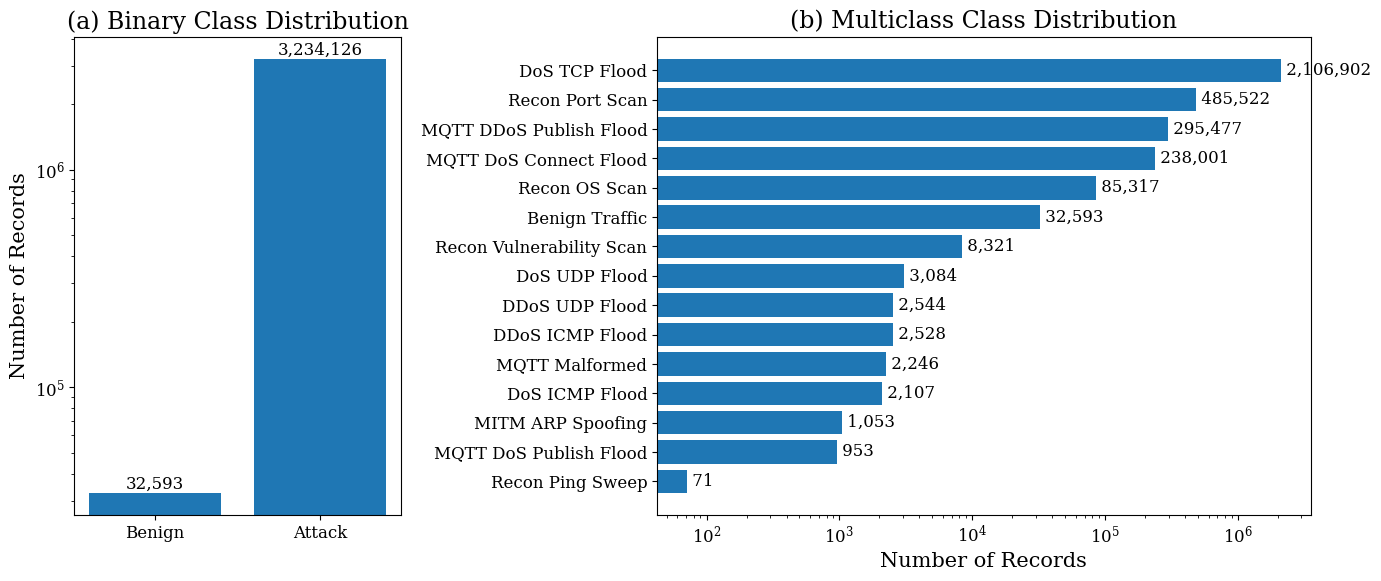

In [9]:
binary_counts = pd.Series({
    "Benign": binary_counter.get(0, 0),
    "Attack": binary_counter.get(1, 0)
})

multiclass_counts = (
    pd.Series(attack_counter)
    .sort_values(ascending=True)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)

# -------------------------------------------------
# Common font style settings (same style as ROC figure)
# -------------------------------------------------
title_fontsize = 17
label_fontsize = 15
tick_fontsize = 12
text_fontsize = 12
font_family = "serif"

# -------------------------------------------------
# (a) Binary Class Distribution
# -------------------------------------------------
axes[0].bar(binary_counts.index, binary_counts.values)

axes[0].set_title(
    "(a) Binary Class Distribution",
    fontsize=title_fontsize,
    fontfamily=font_family
)

axes[0].set_ylabel(
    "Number of Records",
    fontsize=label_fontsize,
    fontfamily=font_family
)

axes[0].set_yscale("log")

axes[0].tick_params(
    axis="both",
    labelsize=tick_fontsize
)

for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontfamily(font_family)

for i, value in enumerate(binary_counts.values):
    axes[0].text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=text_fontsize,
        fontfamily=font_family
    )

# -------------------------------------------------
# (b) Multiclass Class Distribution
# -------------------------------------------------
axes[1].barh(multiclass_counts.index, multiclass_counts.values)

axes[1].set_title(
    "(b) Multiclass Class Distribution",
    fontsize=title_fontsize,
    fontfamily=font_family
)

axes[1].set_xlabel(
    "Number of Records",
    fontsize=label_fontsize,
    fontfamily=font_family
)

axes[1].set_xscale("log")

axes[1].tick_params(
    axis="both",
    labelsize=tick_fontsize
)

for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(font_family)

for i, value in enumerate(multiclass_counts.values):
    axes[1].text(
        value,
        i,
        f" {value:,}",
        va="center",
        fontsize=text_fontsize,
        fontfamily=font_family
    )

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/IoMT_Thesis_2024/Fig_2_Class_Distributions.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [10]:

import os
import gc
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

OUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"
MERGED_FILE = os.path.join(OUT_PATH, "merged_iomt_dataset.csv")

if not os.path.exists(MERGED_FILE):
    raise FileNotFoundError(
        f"Merged dataset was not found: {MERGED_FILE}"
    )

# Label is removed because Attack Name is the multiclass target.
DROP_COLS = ["Flow ID", "Src IP", "Dst IP", "Timestamp", "Label"]

all_columns = pd.read_csv(MERGED_FILE, nrows=1).columns.tolist()
required_columns = {"Attack Name"}
missing_required = required_columns.difference(all_columns)

if missing_required:
    raise ValueError(
        f"Required target column is missing: {sorted(missing_required)}"
    )

use_columns = [
    column
    for column in all_columns
    if column not in DROP_COLS
]

print("Loading multiclass data...")
df = pd.read_csv(
    MERGED_FILE,
    usecols=use_columns,
    low_memory=False
)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(
    df["Attack Name"].astype(str)
).astype(np.int32)

X_all = (
    df.drop(columns=["Attack Name"])
      .astype(np.float32)
)

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

# Preserve the variable name used throughout the original notebook.
le = label_encoder
FEATURE_NAMES = X_train_full.columns.tolist()
CLASS_NAMES = le.classes_.tolist()
NUMBER_OF_CLASSES = len(CLASS_NAMES)

print("Full train:", X_train_full.shape)
print("Full test :", X_test_full.shape)
print("Classes   :", NUMBER_OF_CLASSES)
print(CLASS_NAMES)

del df, X_all, y_all
gc.collect()


Loading multiclass data...
Full train: (2597892, 79)
Full test : (649474, 79)
Classes   : 15
['Benign Traffic', 'DDoS ICMP Flood', 'DDoS UDP Flood', 'DoS ICMP Flood', 'DoS TCP Flood', 'DoS UDP Flood', 'MITM ARP Spoofing', 'MQTT DDoS Publish Flood', 'MQTT DoS Connect Flood', 'MQTT DoS Publish Flood', 'MQTT Malformed', 'Recon OS Scan', 'Recon Ping Sweep', 'Recon Port Scan', 'Recon Vulnerability Scan']


0

In [11]:

import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ML_MULTI_OUTPUT_DIR = os.path.join(
    OUT_PATH,
    "ML_Multiclass_Results"
)
ML_MULTI_MODEL_DIR = os.path.join(
    ML_MULTI_OUTPUT_DIR,
    "Models"
)
ML_MULTI_PLOT_DIR = os.path.join(
    ML_MULTI_OUTPUT_DIR,
    "Plots"
)
ML_MULTI_REPORT_DIR = os.path.join(
    ML_MULTI_OUTPUT_DIR,
    "Classification_Reports"
)
ML_MULTI_PREDICTION_DIR = os.path.join(
    ML_MULTI_OUTPUT_DIR,
    "Predictions"
)
XAI_PATH = os.path.join(
    ML_MULTI_PLOT_DIR,
    "LIME_SHAP"
)

for folder in [
    ML_MULTI_OUTPUT_DIR,
    ML_MULTI_MODEL_DIR,
    ML_MULTI_PLOT_DIR,
    ML_MULTI_REPORT_DIR,
    ML_MULTI_PREDICTION_DIR,
    XAI_PATH
]:
    os.makedirs(folder, exist_ok=True)

MULTI_RESULT_FILE = os.path.join(
    ML_MULTI_OUTPUT_DIR,
    "multiclass_ml_results.csv"
)

print("Results folder:", ML_MULTI_OUTPUT_DIR)
print("Figure folder :", ML_MULTI_PLOT_DIR)
print("XAI folder    :", XAI_PATH)


Results folder: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results
Figure folder : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots
XAI folder    : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/LIME_SHAP


In [12]:

# Colab usually already has SHAP; this installs only missing/required packages.
%pip install -q shap lime

import shap
from lime.lime_tabular import LimeTabularExplainer

print("SHAP version:", shap.__version__)
print("LIME is ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
SHAP version: 0.52.0
LIME is ready.


In [13]:

from matplotlib.colors import PowerNorm
from IPython.display import display, HTML

RESULT_COLUMNS = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC AUC",
    "PR AUC",
    "Train Time"
]


def safe_filename(text):
    text = str(text).strip()
    text = re.sub(r"[^A-Za-z0-9_-]+", "_", text)
    return text.strip("_")


def short_class_labels(class_names):
    known = {
        "Benign": "Benign",
        "DDoS ICMP Flood": "DDoS-ICMP",
        "DDoS UDP Flood": "DDoS-UDP",
        "DoS ICMP Flood": "DoS-ICMP",
        "DoS TCP Flood": "DoS-TCP",
        "DoS UDP Flood": "DoS-UDP",
        "MITM ARP Spoofing": "MITM-ARP",
        "MQTT DDoS Publish Flood": "MQTT-DDoS-Pub",
        "MQTT DoS Connect Flood": "MQTT-DoS-Con",
        "MQTT DoS Publish Flood": "MQTT-DoS-Pub",
        "MQTT Malformed": "MQTT-Malformed",
        "Recon OS Scan": "Recon-OS",
        "Recon Ping Sweep": "Recon-Ping",
        "Recon Port Scan": "Recon-Port",
        "Recon Vulnerability Scan": "Recon-Vuln"
    }
    return [
        known.get(str(name), str(name).replace(" ", "-")[:20])
        for name in class_names
    ]


def _aligned_score_matrix(model, X_data, number_of_classes):
    """
    Return a class-aligned probability or decision-score matrix.
    Columns always correspond to encoded class IDs 0..K-1.
    """
    if hasattr(model, "predict_proba"):
        raw_score = np.asarray(model.predict_proba(X_data))
    elif hasattr(model, "decision_function"):
        raw_score = np.asarray(model.decision_function(X_data))
        if raw_score.ndim == 1:
            raw_score = np.column_stack([-raw_score, raw_score])
    else:
        return None

    if raw_score.ndim != 2:
        raise ValueError(
            f"Expected a 2D score matrix, got shape {raw_score.shape}."
        )

    model_classes = np.asarray(
        getattr(model, "classes_", np.arange(raw_score.shape[1]))
    ).astype(int)

    score_matrix = np.zeros(
        (len(X_data), number_of_classes),
        dtype=np.float32
    )

    valid_positions = (
        (model_classes >= 0)
        & (model_classes < number_of_classes)
    )

    score_matrix[:, model_classes[valid_positions]] = (
        raw_score[:, valid_positions]
    )

    return score_matrix


def _load_or_create_prediction_cache(
    model,
    X_test_data,
    y_test_data,
    number_of_classes,
    cache_path,
    force_recompute=False
):
    y_true = np.asarray(y_test_data).reshape(-1).astype(np.int32)

    if os.path.exists(cache_path) and not force_recompute:
        try:
            cache = np.load(cache_path, allow_pickle=False)
            cached_true = cache["y_true"]
            cached_pred = cache["y_pred"]
            cached_score = cache["y_score"]

            if (
                len(cached_true) == len(y_true)
                and cached_score.shape == (
                    len(y_true),
                    number_of_classes
                )
                and np.array_equal(cached_true, y_true)
            ):
                print("Prediction cache loaded:", cache_path)
                return cached_true, cached_pred, cached_score
        except Exception as cache_error:
            print("Old cache ignored:", cache_error)

    print("Generating predictions once...")
    y_pred = np.asarray(
        model.predict(X_test_data)
    ).reshape(-1).astype(np.int32)

    y_score = _aligned_score_matrix(
        model,
        X_test_data,
        number_of_classes
    )

    if y_score is None:
        y_score = np.empty(
            (len(y_true), 0),
            dtype=np.float32
        )

    np.savez_compressed(
        cache_path,
        y_true=y_true,
        y_pred=y_pred,
        y_score=y_score
    )

    print("Prediction cache saved:", cache_path)
    return y_true, y_pred, y_score


def plot_multiclass_conference_figures(
    model,
    model_name,
    X_test_data,
    y_test_data,
    class_names,
    force_recompute=False
):
    """
    Generate:
    1. Raw-count multiclass confusion matrix
    2. Micro-average ROC curve
    3. Micro-average Precision-Recall curve

    Predictions are cached to reduce repeated execution time.
    """

    class_names = list(class_names)
    number_of_classes = len(class_names)
    class_ids = np.arange(number_of_classes)
    safe_name = safe_filename(model_name)

    os.makedirs(ML_MULTI_PREDICTION_DIR, exist_ok=True)
    os.makedirs(ML_MULTI_REPORT_DIR, exist_ok=True)
    os.makedirs(ML_MULTI_PLOT_DIR, exist_ok=True)

    cache_path = os.path.join(
        ML_MULTI_PREDICTION_DIR,
        f"{safe_name}_conference_cache.npz"
    )

    y_true, y_pred, y_score = _load_or_create_prediction_cache(
        model=model,
        X_test_data=X_test_data,
        y_test_data=y_test_data,
        number_of_classes=number_of_classes,
        cache_path=cache_path,
        force_recompute=force_recompute
    )

    # =========================================================
    # 1. RAW CONFUSION MATRIX
    # =========================================================
    cm_raw = confusion_matrix(
        y_true,
        y_pred,
        labels=class_ids
    ).astype(np.int64)

    confusion_csv = os.path.join(
        ML_MULTI_REPORT_DIR,
        f"{safe_name}_confusion_matrix_raw.csv"
    )

    pd.DataFrame(
        cm_raw,
        index=class_names,
        columns=class_names
    ).to_csv(confusion_csv)

    plot_labels = short_class_labels(class_names)

    maximum_count = max(
        int(cm_raw.max()),
        1
    )

    fig, ax = plt.subplots(
        figsize=(17, 13)
    )

    image = ax.imshow(
        cm_raw,
        cmap="Blues",
        interpolation="nearest",
        aspect="auto",
        norm=PowerNorm(
            gamma=0.45,
            vmin=0,
            vmax=maximum_count
        )
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.035
    )

    colorbar.set_label(
        "Number of samples",
        rotation=270,
        labelpad=22,
        fontsize=14
    )

    colorbar.ax.tick_params(
        labelsize=12
    )

    # ax.set_title(
      #   f"Confusion Matrix — {model_name}",
       #  fontsize=18,
        # pad=14
    # )

    ax.set_xlabel(
        "Predicted Class",
        fontsize=16
    )

    ax.set_ylabel(
        "True Class",
        fontsize=16
    )

    ax.set_xticks(class_ids)
    ax.set_yticks(class_ids)

    ax.set_xticklabels(
        plot_labels,
        rotation=55,
        ha="right",
        rotation_mode="anchor",
        fontsize=10.5
    )

    ax.set_yticklabels(
        plot_labels,
        fontsize=12
    )

    # Grid lines between cells
    ax.set_xticks(
        np.arange(
            -0.5,
            number_of_classes,
            1
        ),
        minor=True
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            number_of_classes,
            1
        ),
        minor=True
    )

    ax.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=0.45
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    # Actual integer values inside cells
    for row in range(number_of_classes):
        for column in range(number_of_classes):

            value = int(
                cm_raw[row, column]
            )

            # Example: 670515 -> 670,515
            annotation = f"{value:,}"

            text_color = (
                "white"
                if image.norm(value) >= 0.55
                else "black"
            )

            ax.text(
                column,
                row,
                annotation,
                ha="center",
                va="center",
                fontsize=10.5,
                fontweight="bold",
                color=text_color
            )

    fig.tight_layout()

    confusion_png = os.path.join(
        ML_MULTI_PLOT_DIR,
        f"{safe_name}_conference_confusion_matrix.png"
    )

    confusion_pdf = os.path.join(
        ML_MULTI_PLOT_DIR,
        f"{safe_name}_conference_confusion_matrix.pdf"
    )

    fig.savefig(
        confusion_png,
        dpi=450,
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        confusion_pdf,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close(fig)

    display(HTML("<div style='height:35px;'></div>"))

    print("Confusion matrix saved:", confusion_png)

    # Default values when scores are unavailable
    roc_auc_value = np.nan
    pr_auc_value = np.nan

    # =========================================================
    # 2. ROC AND PRECISION-RECALL CURVES
    # =========================================================
    if y_score.shape == (
        len(y_true),
        number_of_classes
    ):

        y_binary = label_binarize(
            y_true,
            classes=class_ids
        )

        if y_binary.ndim == 1:
            y_binary = y_binary.reshape(
                -1,
                1
            )

        if y_binary.shape[1] == number_of_classes:

            flattened_true = y_binary.ravel()
            flattened_score = y_score.ravel()

            if np.unique(flattened_true).size == 2:

                # =============================================
                # Micro-average ROC Curve
                # =============================================
                fpr, tpr, _ = roc_curve(
                    flattened_true,
                    flattened_score
                )

                roc_auc_value = auc(
                    fpr,
                    tpr
                )

                fig, ax = plt.subplots(
                    figsize=(7.4, 4.0)
                )

                ax.plot(
                    fpr,
                    tpr,
                    linewidth=2.4,
                    label=(
                        "Micro-average AUC = "
                        f"{roc_auc_value:.4f}"
                    )
                )

                ax.plot(
                    [0, 1],
                    [0, 1],
                    linestyle="--",
                    linewidth=1.5,
                    label="Random classifier"
                )

                #ax.set_title(
                   # f"Multiclass ROC Curve — {model_name}",
                   # fontsize=17,
                   # pad=10
                #)

                ax.set_xlabel(
                    "False Positive Rate",
                    fontsize=15
                )

                ax.set_ylabel(
                    "True Positive Rate",
                    fontsize=15
                )

                ax.tick_params(
                    axis="both",
                    labelsize=13
                )

                ax.legend(
                    loc="lower right",
                    fontsize=12.5
                )

                ax.grid(alpha=0.28)
                fig.tight_layout()

                roc_png = os.path.join(
                    ML_MULTI_PLOT_DIR,
                    f"{safe_name}_conference_roc_curve.png"
                )

                roc_pdf = os.path.join(
                    ML_MULTI_PLOT_DIR,
                    f"{safe_name}_conference_roc_curve.pdf"
                )

                fig.savefig(
                    roc_png,
                    dpi=350,
                    bbox_inches="tight",
                    facecolor="white"
                )

                fig.savefig(
                    roc_pdf,
                    bbox_inches="tight",
                    facecolor="white"
                )

                plt.show()
                plt.close(fig)

                display(HTML("<div style='height:35px;'></div>"))

                print("ROC curve saved:", roc_png)

                # =============================================
                # Micro-average Precision-Recall Curve
                # =============================================
                precision_values, recall_values, _ = (
                    precision_recall_curve(
                        flattened_true,
                        flattened_score
                    )
                )

                pr_auc_value = average_precision_score(
                    flattened_true,
                    flattened_score
                )

                fig, ax = plt.subplots(
                    figsize=(7.4, 4.0)
                )

                ax.plot(
                    recall_values,
                    precision_values,
                    linewidth=2.4,
                    label=(
                        "Micro-average AP = "
                        f"{pr_auc_value:.4f}"
                    )
                )

                #ax.set_title(
                   # (
                       # "Multiclass Precision–Recall Curve — "
                        #f"{model_name}"
                    #),
                    #fontsize=17,
                    #pad=10
                #)

                ax.set_xlabel(
                    "Recall",
                    fontsize=15
                )

                ax.set_ylabel(
                    "Precision",
                    fontsize=15
                )

                ax.tick_params(
                    axis="both",
                    labelsize=13
                )

                ax.legend(
                    loc="lower left",
                    fontsize=12.5
                )

                ax.grid(alpha=0.28)
                fig.tight_layout()

                pr_png = os.path.join(
                    ML_MULTI_PLOT_DIR,
                    (
                        f"{safe_name}_conference_"
                        "precision_recall_curve.png"
                    )
                )

                pr_pdf = os.path.join(
                    ML_MULTI_PLOT_DIR,
                    (
                        f"{safe_name}_conference_"
                        "precision_recall_curve.pdf"
                    )
                )

                fig.savefig(
                    pr_png,
                    dpi=350,
                    bbox_inches="tight",
                    facecolor="white"
                )

                fig.savefig(
                    pr_pdf,
                    bbox_inches="tight",
                    facecolor="white"
                )

                plt.show()
                plt.close(fig)

                print(
                    "Precision-Recall curve saved:",
                    pr_png
                )

            else:
                print(
                    "ROC and PR curves skipped: "
                    "valid positive and negative entries "
                    "were not found."
                )

        else:
            print(
                "ROC and PR curves skipped: "
                "binarized label shape does not match "
                "the score matrix."
            )

    else:
        print(
            "ROC and PR curves skipped because "
            "predict_proba or decision_function "
            "scores are unavailable."
        )

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_score": y_score,
        "confusion_matrix_raw": cm_raw,
        "roc_auc": roc_auc_value,
        "pr_auc": pr_auc_value,
        "cache_path": cache_path
    }


if os.path.exists(MULTI_RESULT_FILE):
    multi_results_df = pd.read_csv(MULTI_RESULT_FILE)

    for column in RESULT_COLUMNS:
        if column not in multi_results_df.columns:
            multi_results_df[column] = np.nan

    multi_results_df = multi_results_df[RESULT_COLUMNS]
    print("Previous multiclass results loaded.")
    display(multi_results_df)
else:
    multi_results_df = pd.DataFrame(columns=RESULT_COLUMNS)
    print("A new result file will be created.")

multi_results = multi_results_df.values.tolist()


def run_multi(
    name,
    model,
    Xtr,
    ytr,
    Xte,
    yte,
    generate_shap=False,
    shap_model_type="auto",
    shap_class_indices=None,
    shap_background_size=100,
    shap_explain_size=200,
    shap_max_display=30,
    save_prediction_csv=False
):
    """
    Train and evaluate one multiclass ML model.

    The old per-class SHAP option is retained in the signature for
    compatibility, but the conference-ready combined LIME–SHAP figure
    is generated later in one fast cell.
    """
    global multi_results_df
    global multi_results

    safe_name = safe_filename(name)

    print("\n" + "=" * 80)
    print("Training:", name)
    print("=" * 80)

    start_time = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - start_time

    artifacts = plot_multiclass_conference_figures(
        model=model,
        model_name=name,
        X_test_data=Xte,
        y_test_data=yte,
        class_names=le.classes_,
        force_recompute=True
    )

    y_true = artifacts["y_true"]
    y_pred = artifacts["y_pred"]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy   : {accuracy:.6f}")
    print(f"Precision  : {precision:.6f}")
    print(f"Recall     : {recall:.6f}")
    print(f"F1 Score   : {f1:.6f}")
    print(f"Train Time : {train_time:.2f} seconds")

    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(le.classes_)),
        target_names=le.classes_,
        zero_division=0,
        digits=6,
        output_dict=True
    )

    report_path = os.path.join(
        ML_MULTI_REPORT_DIR,
        f"{safe_name}_classification_report.csv"
    )
    pd.DataFrame(report).transpose().to_csv(report_path)


    os.makedirs(
    ML_MULTI_MODEL_DIR,
    exist_ok=True)

    model_path = os.path.join(
        ML_MULTI_MODEL_DIR,
        f"{safe_name}.joblib"
    )
    joblib.dump(model, model_path, compress=1)

    if save_prediction_csv:
        prediction_path = os.path.join(
            ML_MULTI_PREDICTION_DIR,
            f"{safe_name}_predictions.csv"
        )
        pd.DataFrame({
            "Actual_Class_ID": y_true,
            "Predicted_Class_ID": y_pred,
            "Actual_Class": le.inverse_transform(y_true),
            "Predicted_Class": le.inverse_transform(y_pred)
        }).to_csv(prediction_path, index=False)

    if generate_shap:
        print(
            "Per-class SHAP plots were skipped intentionally. "
            "Run the combined 15-class LIME–SHAP cell at the end."
        )

    new_row = pd.DataFrame([{
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC AUC": artifacts["roc_auc"],
        "PR AUC": artifacts["pr_auc"],
        "Train Time": train_time
    }])

    multi_results_df = multi_results_df[
        multi_results_df["Model"] != name
    ]

    multi_results_df = pd.concat(
        [multi_results_df, new_row],
        ignore_index=True
    )

    multi_results_df = (
        multi_results_df[RESULT_COLUMNS]
        .sort_values("F1", ascending=False)
        .reset_index(drop=True)
    )

    multi_results_df.to_csv(
        MULTI_RESULT_FILE,
        index=False
    )

    multi_results = multi_results_df.values.tolist()

    print("Model saved :", model_path)
    print("Report saved:", report_path)

    return model


Previous multiclass results loaded.


,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Train Time
0,Decision Tree Full,0.996727,0.996690,0.996727,0.996706,0.998246,0.993682,148.637727
1,Random Forest Full,0.984380,0.983560,0.984380,0.983568,0.999832,0.998933,338.300073
2,Extra Trees Full,0.983383,0.982389,0.983383,0.982390,0.999820,0.998867,164.698123
3,XGBoost Full,0.983214,0.982196,0.983214,0.982078,0.999915,0.999060,1437.864105
4,Voting Ensemble Sample,0.979113,0.977243,0.979113,0.976899,0.999884,0.998572,121.058291



Training: Decision Tree Full
Generating predictions once...
Prediction cache saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/Decision_Tree_Full_conference_cache.npz


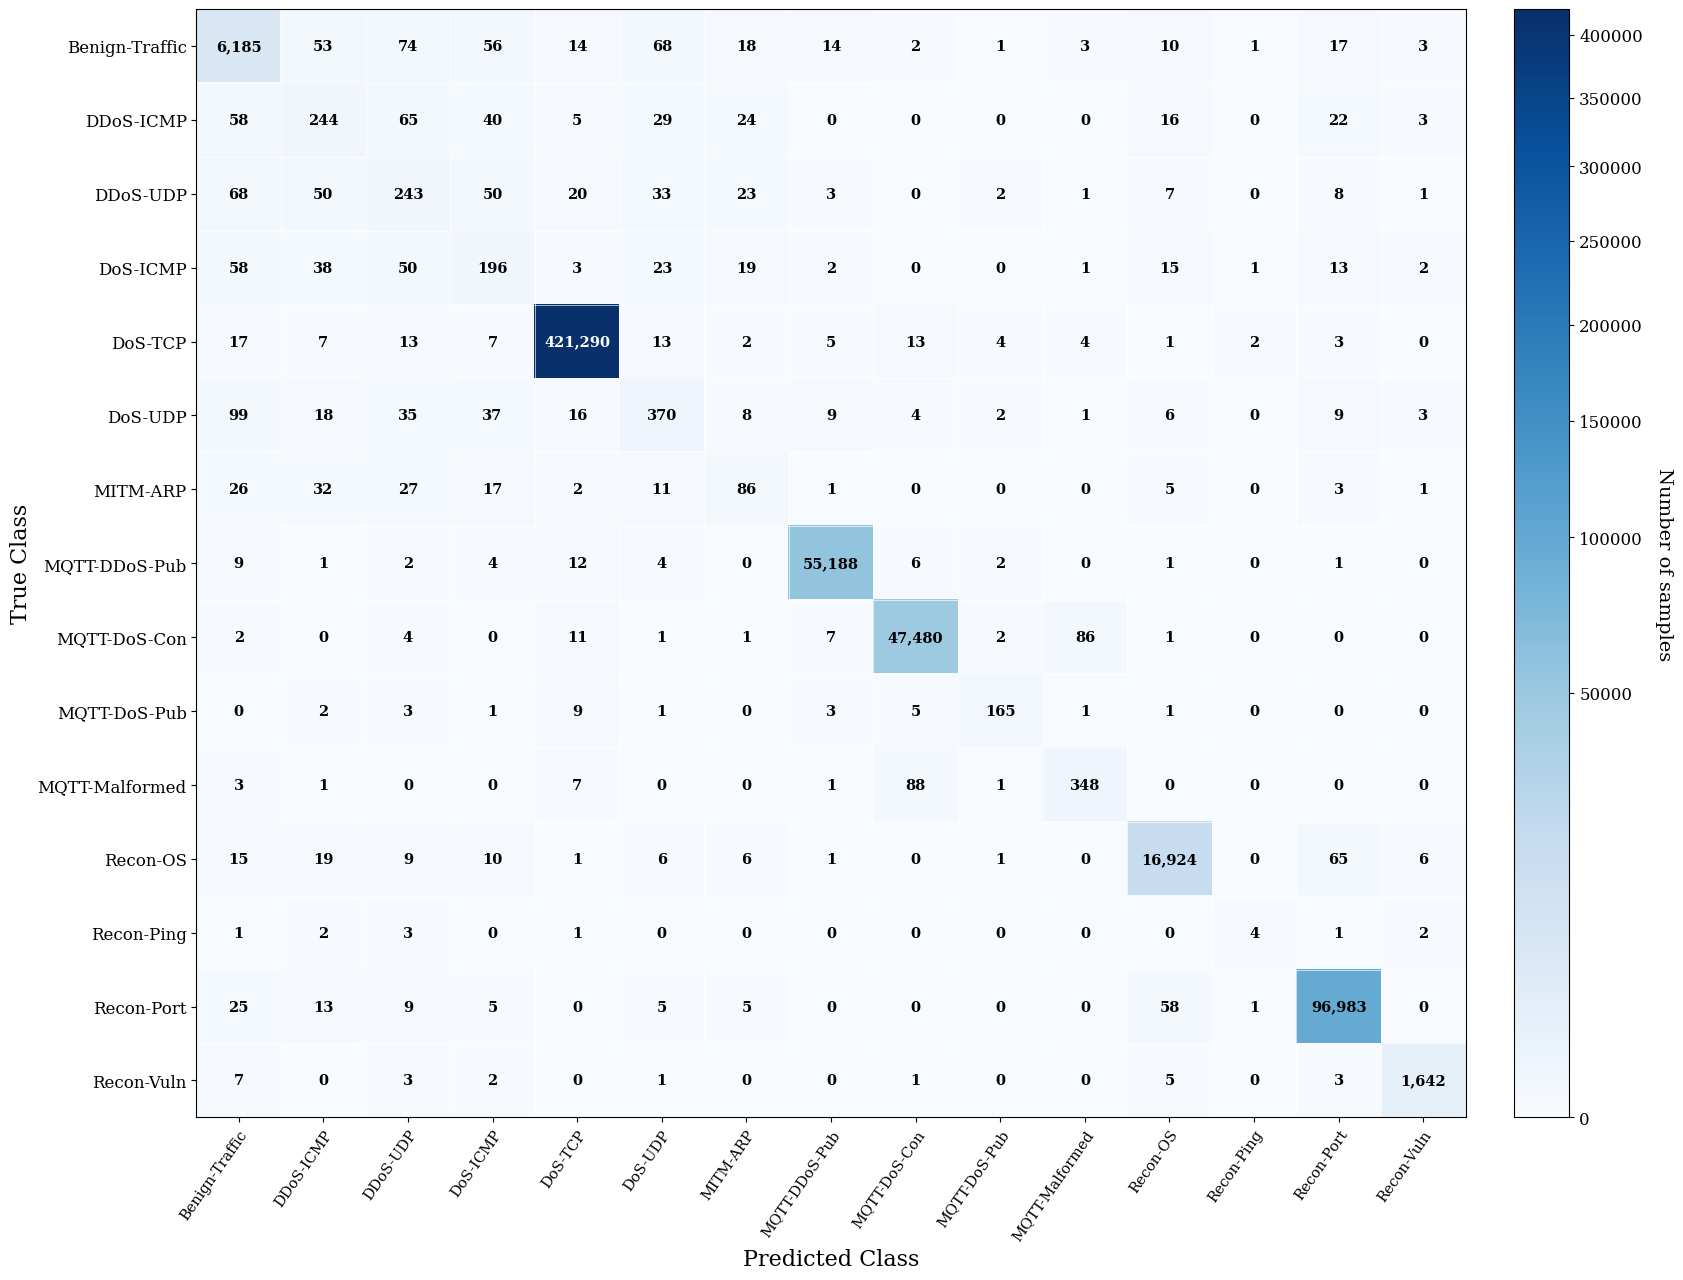

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Decision_Tree_Full_conference_confusion_matrix.png


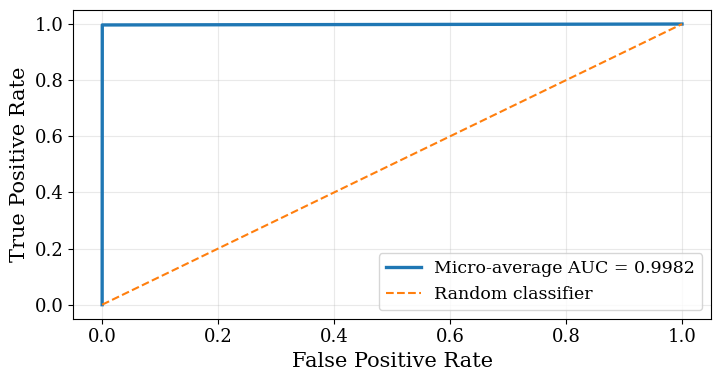

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Decision_Tree_Full_conference_roc_curve.png


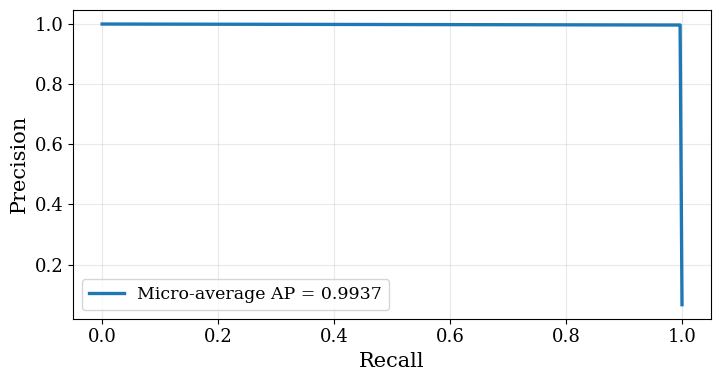

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Decision_Tree_Full_conference_precision_recall_curve.png
Accuracy   : 0.996727
Precision  : 0.996690
Recall     : 0.996727
F1 Score   : 0.996706
Train Time : 112.39 seconds
Model saved : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/Decision_Tree_Full.joblib
Report saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Classification_Reports/Decision_Tree_Full_classification_report.csv
Decision Tree training completed. The combined 15-class LIME–SHAP figure is generated later.


In [14]:

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

dt_model = run_multi(
    "Decision Tree Full",
    dt_model,
    X_train_full,
    y_train_full,
    X_test_full,
    y_test_full,
    generate_shap=False
)

print(
    "Decision Tree training completed. "
    "The combined 15-class LIME–SHAP figure is generated later."
)


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

print("=" * 90)
print("MULTICLASS FINAL AUDIT — DECISION TREE")
print("=" * 90)

# ============================================================
# 1. Dataset dimensions
# ============================================================

train_rows = len(y_train_full)
test_rows = len(y_test_full)
total_rows = train_rows + test_rows
feature_count = X_train_full.shape[1]
class_count = len(le.classes_)

print("\nDATASET SUMMARY")
print("-" * 90)
print("Total cleaned rows :", total_rows)
print("Training rows      :", train_rows)
print("Test rows          :", test_rows)
print("Predictive features:", feature_count)
print("Number of classes  :", class_count)

# ============================================================
# 2. Encoded class mapping
# ============================================================

print("\nCLASS-ID MAPPING")
print("-" * 90)

for class_id, class_name in enumerate(le.classes_):
    print(f"{class_id:2d} -> {class_name}")

# ============================================================
# 3. Full, train and test class distributions
# ============================================================

train_counts = pd.Series(
    y_train_full
).value_counts().sort_index()

test_counts = pd.Series(
    y_test_full
).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Class ID": np.arange(class_count),
    "Class Name": le.classes_,
    "Train Count": [
        int(train_counts.get(i, 0))
        for i in range(class_count)
    ],
    "Test Count": [
        int(test_counts.get(i, 0))
        for i in range(class_count)
    ]
})

class_distribution["Total Count"] = (
    class_distribution["Train Count"]
    + class_distribution["Test Count"]
)

print("\nCLASS DISTRIBUTION")
print("-" * 90)
print(class_distribution.to_string(index=False))

print("\nDistribution checks")
print("Train-count sum:", class_distribution["Train Count"].sum())
print("Test-count sum :", class_distribution["Test Count"].sum())
print("Total-count sum:", class_distribution["Total Count"].sum())

# ============================================================
# 4. Decision Tree predictions
# ============================================================

dt_pred_multi = dt_model.predict(
    X_test_full
)

class_ids = np.arange(class_count)

cm_multi = confusion_matrix(
    y_test_full,
    dt_pred_multi,
    labels=class_ids
)

print("\nRAW CONFUSION MATRIX")
print("-" * 90)
print(cm_multi)

print("\nConfusion-matrix total:", cm_multi.sum())
print("Expected test total   :", test_rows)
print(
    "Total check           :",
    "PASS" if cm_multi.sum() == test_rows else "FAIL"
)

# Named confusion matrix for easier checking
cm_named_df = pd.DataFrame(
    cm_multi,
    index=le.classes_,
    columns=le.classes_
)

print("\nNAMED CONFUSION MATRIX")
print("-" * 90)
print(cm_named_df.to_string())

# ============================================================
# 5. Overall multiclass metrics
# ============================================================

accuracy = accuracy_score(
    y_test_full,
    dt_pred_multi
)

weighted_precision = precision_score(
    y_test_full,
    dt_pred_multi,
    labels=class_ids,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_test_full,
    dt_pred_multi,
    labels=class_ids,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test_full,
    dt_pred_multi,
    labels=class_ids,
    average="weighted",
    zero_division=0
)

macro_precision = precision_score(
    y_test_full,
    dt_pred_multi,
    labels=class_ids,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test_full,
    dt_pred_multi,
    labels=class_ids,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test_full,
    dt_pred_multi,
    labels=class_ids,
    average="macro",
    zero_division=0
)

micro_f1 = f1_score(
    y_test_full,
    dt_pred_multi,
    labels=class_ids,
    average="micro",
    zero_division=0
)

print("\nDECISION TREE METRICS")
print("-" * 90)
print(f"Accuracy            : {accuracy:.12f} ({accuracy * 100:.6f}%)")
print(
    f"Weighted Precision  : {weighted_precision:.12f} "
    f"({weighted_precision * 100:.6f}%)"
)
print(
    f"Weighted Recall     : {weighted_recall:.12f} "
    f"({weighted_recall * 100:.6f}%)"
)
print(
    f"Weighted F1         : {weighted_f1:.12f} "
    f"({weighted_f1 * 100:.6f}%)"
)
print(
    f"Macro Precision     : {macro_precision:.12f} "
    f"({macro_precision * 100:.6f}%)"
)
print(
    f"Macro Recall        : {macro_recall:.12f} "
    f"({macro_recall * 100:.6f}%)"
)
print(
    f"Macro F1            : {macro_f1:.12f} "
    f"({macro_f1 * 100:.6f}%)"
)
print(f"Micro F1            : {micro_f1:.12f} ({micro_f1 * 100:.6f}%)")

# ============================================================
# 6. Class-wise report
# ============================================================

report_dict = classification_report(
    y_test_full,
    dt_pred_multi,
    labels=class_ids,
    target_names=le.classes_,
    output_dict=True,
    digits=8,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

print("\nCLASS-WISE CLASSIFICATION REPORT")
print("-" * 90)
print(report_df.to_string())

# ============================================================
# 7. Probability-based ROC and PR metrics
#    This reproduces the same micro-average method used
#    inside your run_multi() function.
# ============================================================

if hasattr(dt_model, "predict_proba"):

    model_prob = dt_model.predict_proba(
        X_test_full
    )

    probability_matrix = np.zeros(
        (test_rows, class_count),
        dtype=np.float32
    )

    model_classes = np.asarray(
        dt_model.classes_
    ).astype(int)

    probability_matrix[:, model_classes] = model_prob

    y_test_bin = label_binarize(
        y_test_full,
        classes=class_ids
    )

    # Same micro-average ROC calculation as run_multi()
    fpr_micro, tpr_micro, _ = roc_curve(
        y_test_bin.ravel(),
        probability_matrix.ravel()
    )

    micro_roc_auc = auc(
        fpr_micro,
        tpr_micro
    )

    # Same micro-average AP calculation as run_multi()
    precision_micro, recall_micro, _ = precision_recall_curve(
        y_test_bin.ravel(),
        probability_matrix.ravel()
    )

    micro_pr_auc = average_precision_score(
        y_test_bin,
        probability_matrix,
        average="micro"
    )

    macro_pr_auc = average_precision_score(
        y_test_bin,
        probability_matrix,
        average="macro"
    )

    print("\nPROBABILITY-BASED METRICS")
    print("-" * 90)
    print(
        f"Micro ROC-AUC : {micro_roc_auc:.12f} "
        f"({micro_roc_auc:.6f})"
    )
    print(
        f"Micro PR-AUC  : {micro_pr_auc:.12f} "
        f"({micro_pr_auc:.6f})"
    )
    print(
        f"Macro PR-AUC  : {macro_pr_auc:.12f} "
        f"({macro_pr_auc:.6f})"
    )

else:
    print("\nDecision Tree does not provide predict_proba().")

# ============================================================
# 8. Lowest and highest class F1 scores
# ============================================================

class_only_report = report_df.loc[
    list(le.classes_),
    ["precision", "recall", "f1-score", "support"]
].sort_values(
    "f1-score",
    ascending=True
)

print("\nCLASSES SORTED FROM LOWEST TO HIGHEST F1")
print("-" * 90)
print(class_only_report.to_string())

print("\nFive weakest classes:")
print(class_only_report.head(5).to_string())

print("\nFive strongest classes:")
print(
    class_only_report.sort_values(
        "f1-score",
        ascending=False
    ).head(5).to_string()
)

print("\n" + "=" * 90)
print("MULTICLASS AUDIT COMPLETED")
print("=" * 90)

MULTICLASS FINAL AUDIT — DECISION TREE

DATASET SUMMARY
------------------------------------------------------------------------------------------
Total cleaned rows : 3247366
Training rows      : 2597892
Test rows          : 649474
Predictive features: 79
Number of classes  : 15

CLASS-ID MAPPING
------------------------------------------------------------------------------------------
 0 -> Benign Traffic
 1 -> DDoS ICMP Flood
 2 -> DDoS UDP Flood
 3 -> DoS ICMP Flood
 4 -> DoS TCP Flood
 5 -> DoS UDP Flood
 6 -> MITM ARP Spoofing
 7 -> MQTT DDoS Publish Flood
 8 -> MQTT DoS Connect Flood
 9 -> MQTT DoS Publish Flood
10 -> MQTT Malformed
11 -> Recon OS Scan
12 -> Recon Ping Sweep
13 -> Recon Port Scan
14 -> Recon Vulnerability Scan

CLASS DISTRIBUTION
------------------------------------------------------------------------------------------
 Class ID               Class Name  Train Count  Test Count  Total Count
        0           Benign Traffic        26074        6519        32593


Training: Random Forest Full
Generating predictions once...
Prediction cache saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/Random_Forest_Full_conference_cache.npz


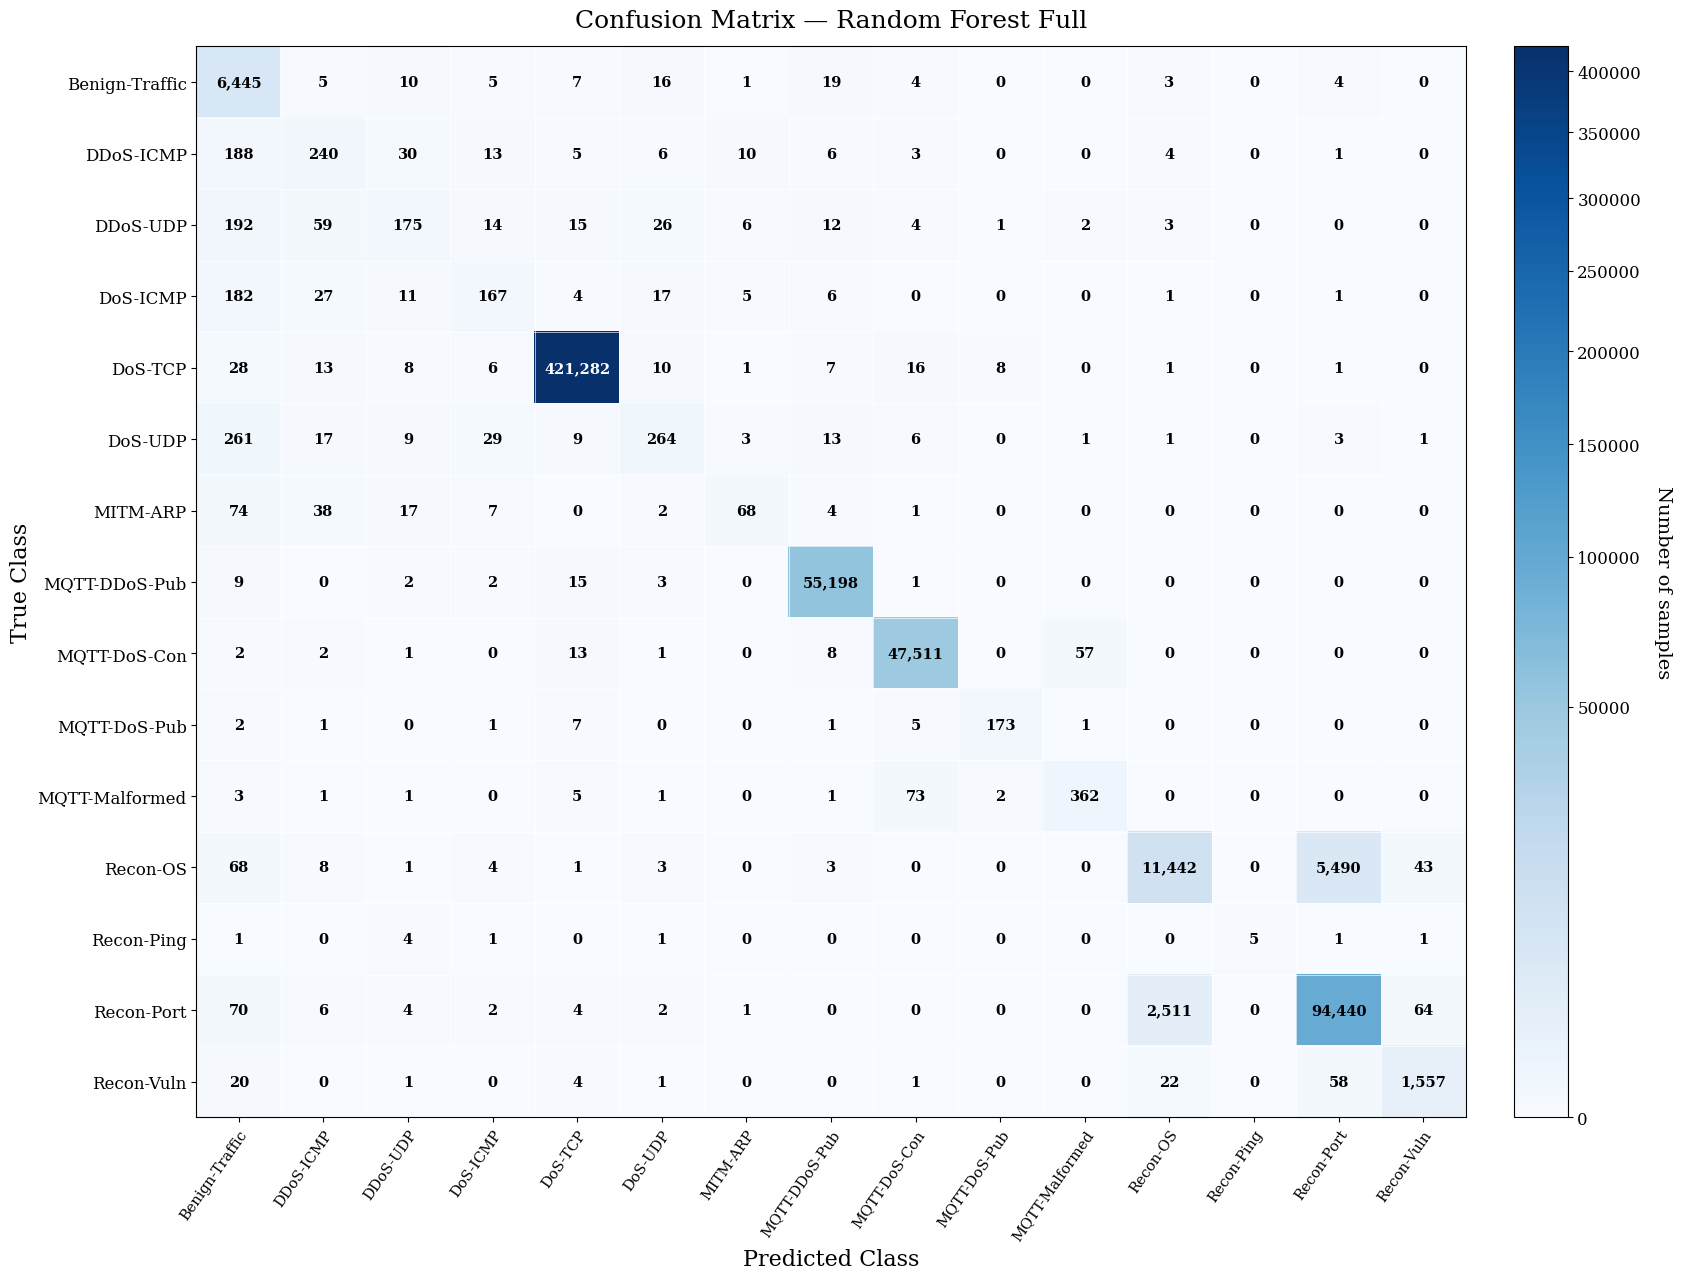

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Random_Forest_Full_conference_confusion_matrix.png


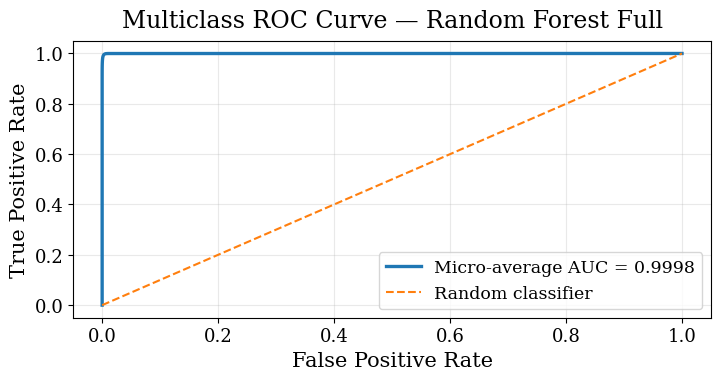

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Random_Forest_Full_conference_roc_curve.png


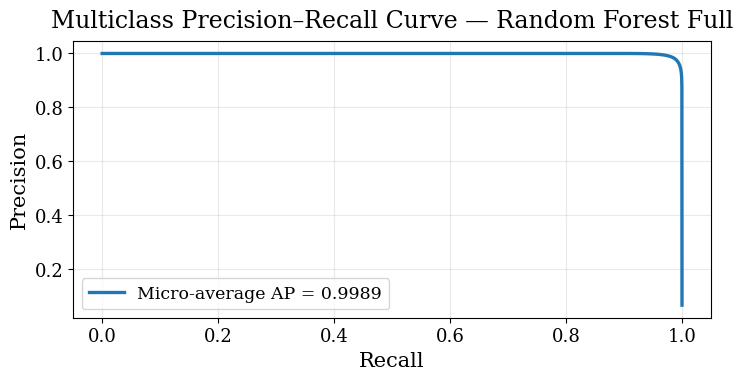

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Random_Forest_Full_conference_precision_recall_curve.png
Accuracy   : 0.984380
Precision  : 0.983560
Recall     : 0.984380
F1 Score   : 0.983568
Train Time : 338.30 seconds
Model saved : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/Random_Forest_Full.joblib
Report saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Classification_Reports/Random_Forest_Full_classification_report.csv


RandomForestClassifier(class_weight='balanced', max_samples=0.5,
                       n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    max_samples=0.5
)

run_multi(
    "Random Forest Full",
    rf_model,
    X_train_full,
    y_train_full,
    X_test_full,
    y_test_full
)


Training: Extra Trees Full
Generating predictions once...
Prediction cache saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/Extra_Trees_Full_conference_cache.npz


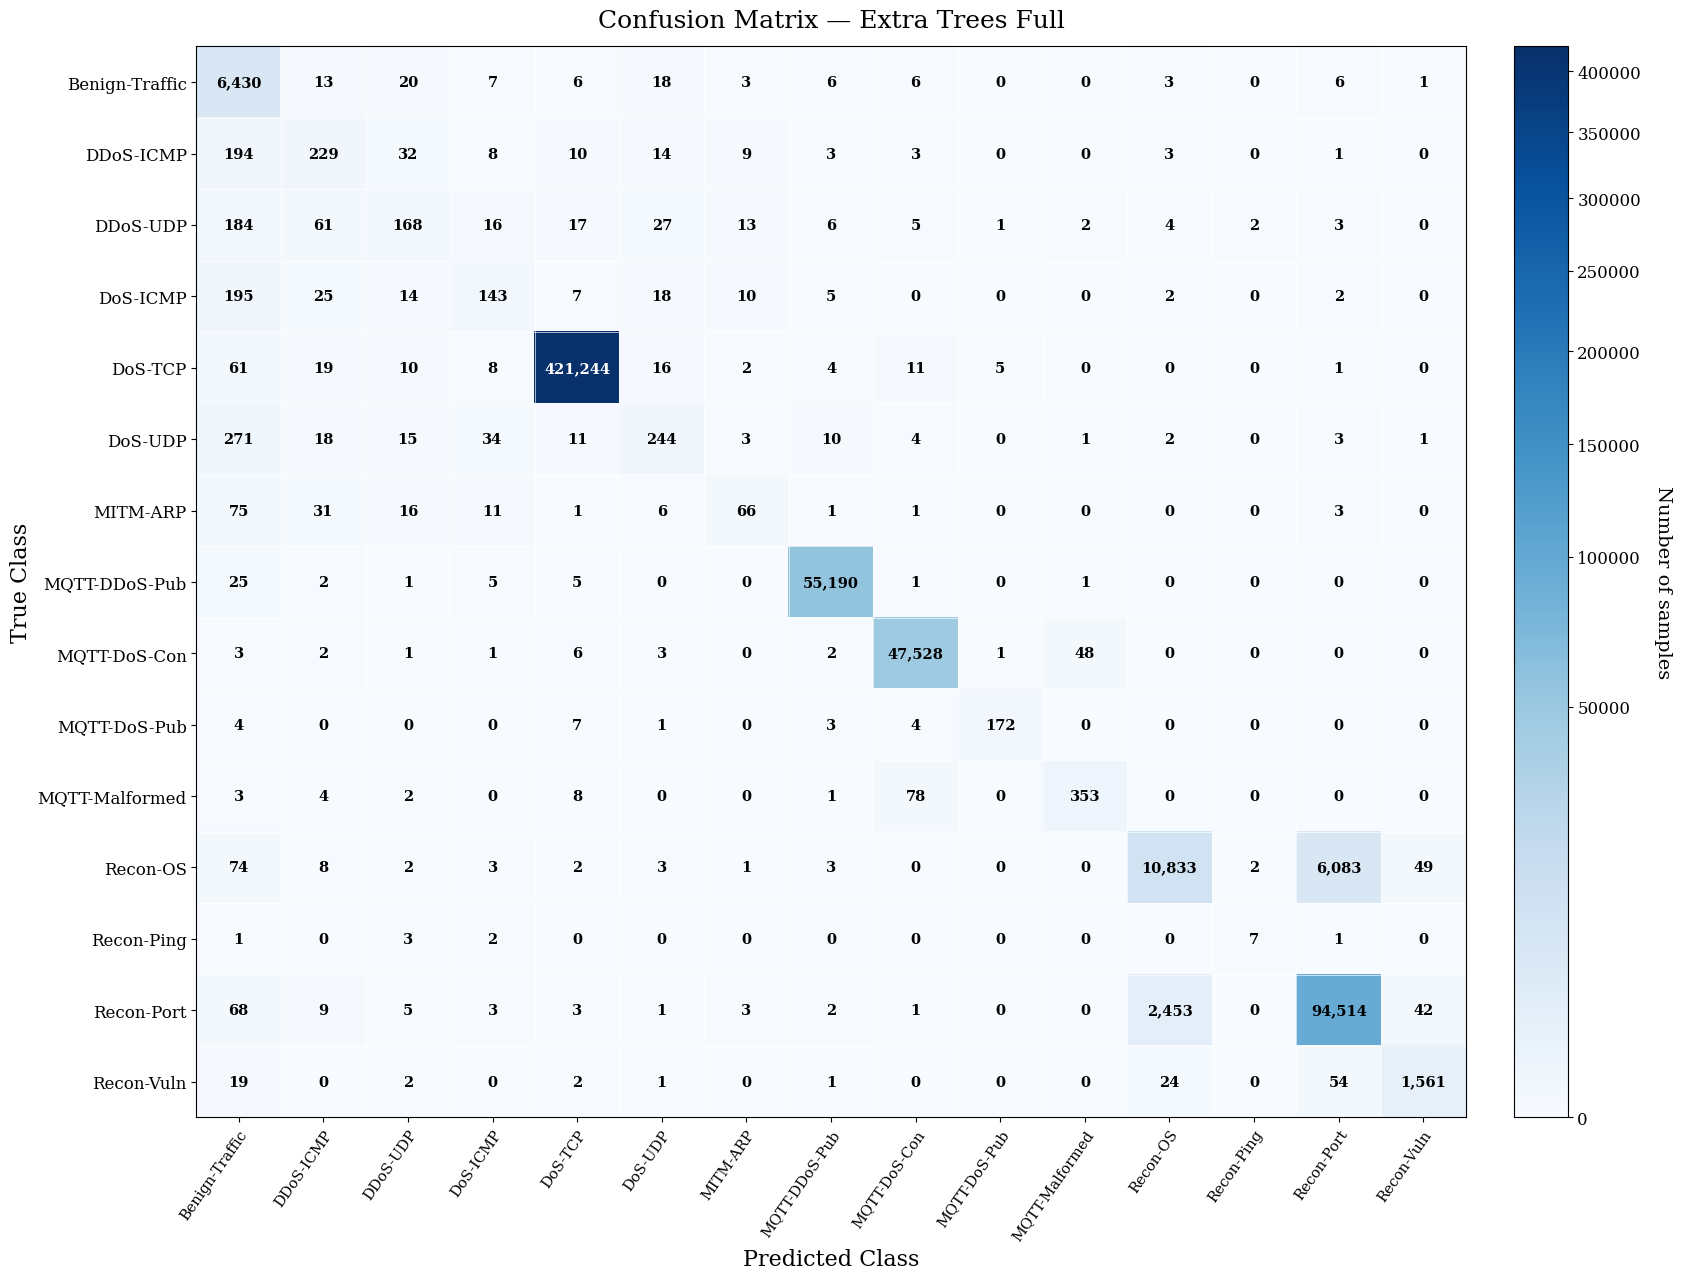

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Extra_Trees_Full_conference_confusion_matrix.png


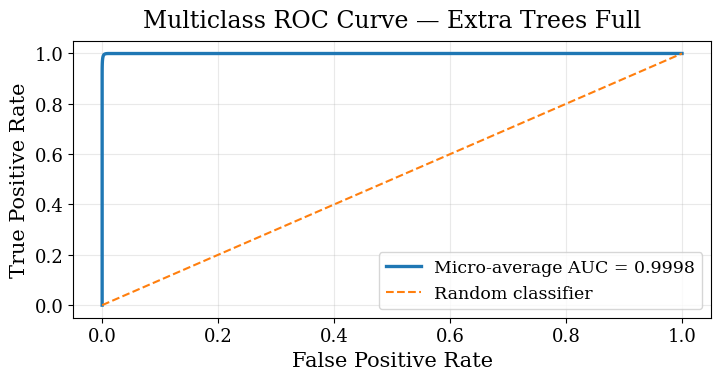

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Extra_Trees_Full_conference_roc_curve.png


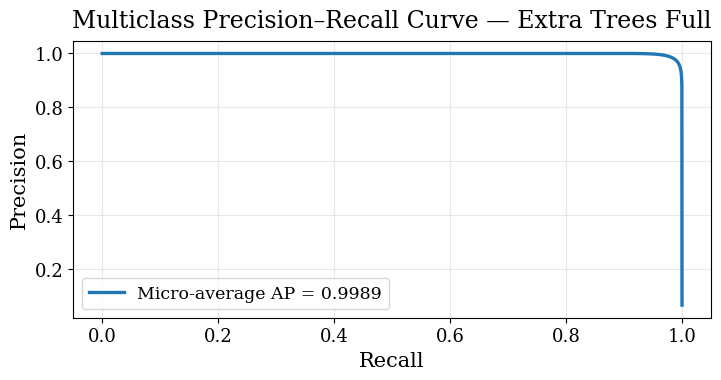

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Extra_Trees_Full_conference_precision_recall_curve.png
Accuracy   : 0.983383
Precision  : 0.982389
Recall     : 0.983383
F1 Score   : 0.982390
Train Time : 164.70 seconds
Model saved : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/Extra_Trees_Full.joblib
Report saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Classification_Reports/Extra_Trees_Full_classification_report.csv


ExtraTreesClassifier(bootstrap=True, class_weight='balanced', max_samples=0.5,
                     n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=50,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    bootstrap=True,
    max_samples=0.5
)

run_multi(
    "Extra Trees Full",
    et_model,
    X_train_full,
    y_train_full,
    X_test_full,
    y_test_full
)


Training: XGBoost Full
Generating predictions once...
Prediction cache saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/XGBoost_Full_conference_cache.npz


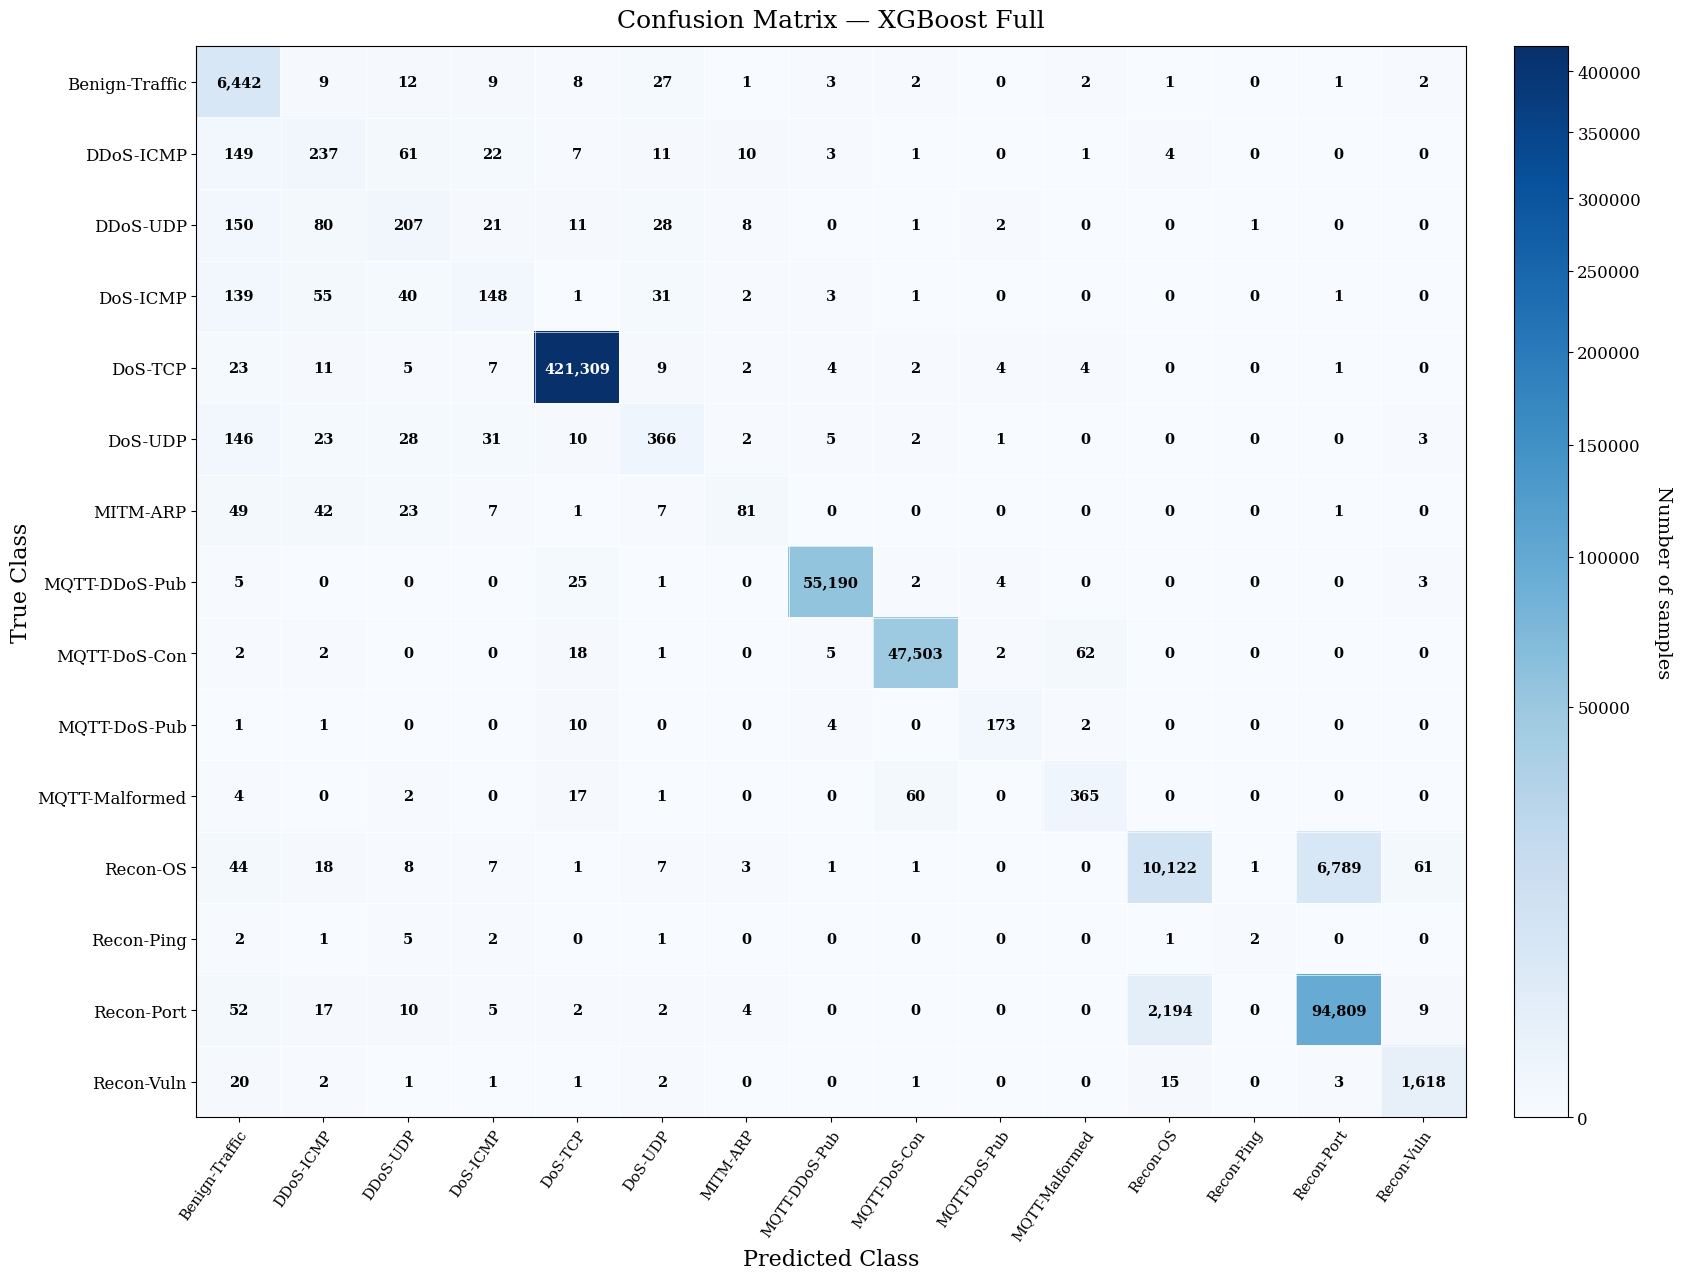

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/XGBoost_Full_conference_confusion_matrix.png


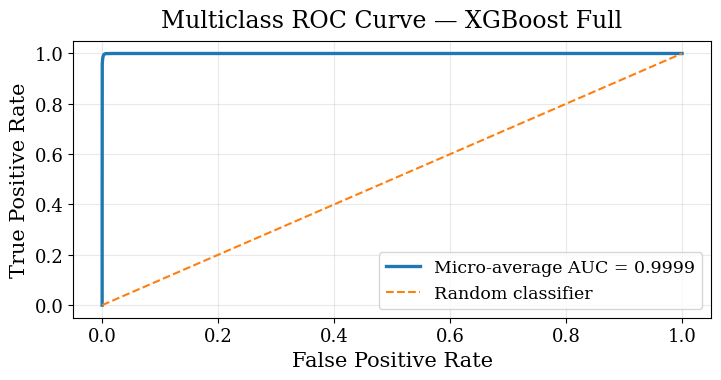

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/XGBoost_Full_conference_roc_curve.png


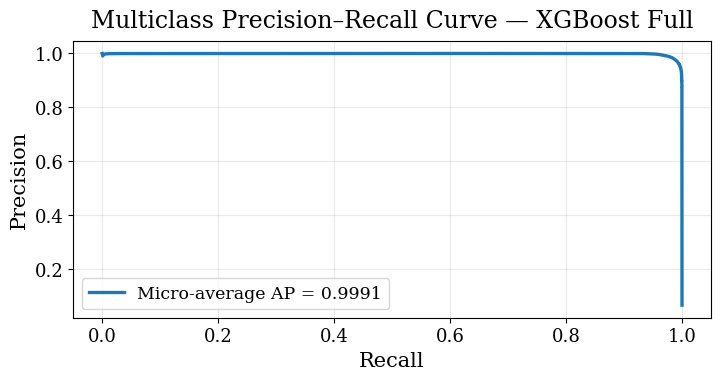

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/XGBoost_Full_conference_precision_recall_curve.png
Accuracy   : 0.983214
Precision  : 0.982196
Recall     : 0.983214
F1 Score   : 0.982078
Train Time : 1437.86 seconds
Model saved : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/XGBoost_Full.joblib
Report saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Classification_Reports/XGBoost_Full_classification_report.csv


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1, num_class=15, ...)

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

run_multi(
    "XGBoost Full",
    xgb_model,
    X_train_full,
    y_train_full,
    X_test_full,
    y_test_full
)

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=min(300000, len(X_train_full)),
    random_state=42,
    stratify=y_train_full
)

X_test_sample, _, y_test_sample, _ = train_test_split(
    X_test_full, y_test_full,
    train_size=min(80000, len(X_test_full)),
    random_state=42,
    stratify=y_test_full
)

scaler = StandardScaler()
X_train_sample_scaled = scaler.fit_transform(X_train_sample).astype("float32")
X_test_sample_scaled = scaler.transform(X_test_sample).astype("float32")

print(X_train_sample.shape, X_test_sample.shape)

(300000, 79) (80000, 79)



Training: Logistic Regression Sample
Generating predictions once...
Prediction cache saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/Logistic_Regression_Sample_conference_cache.npz


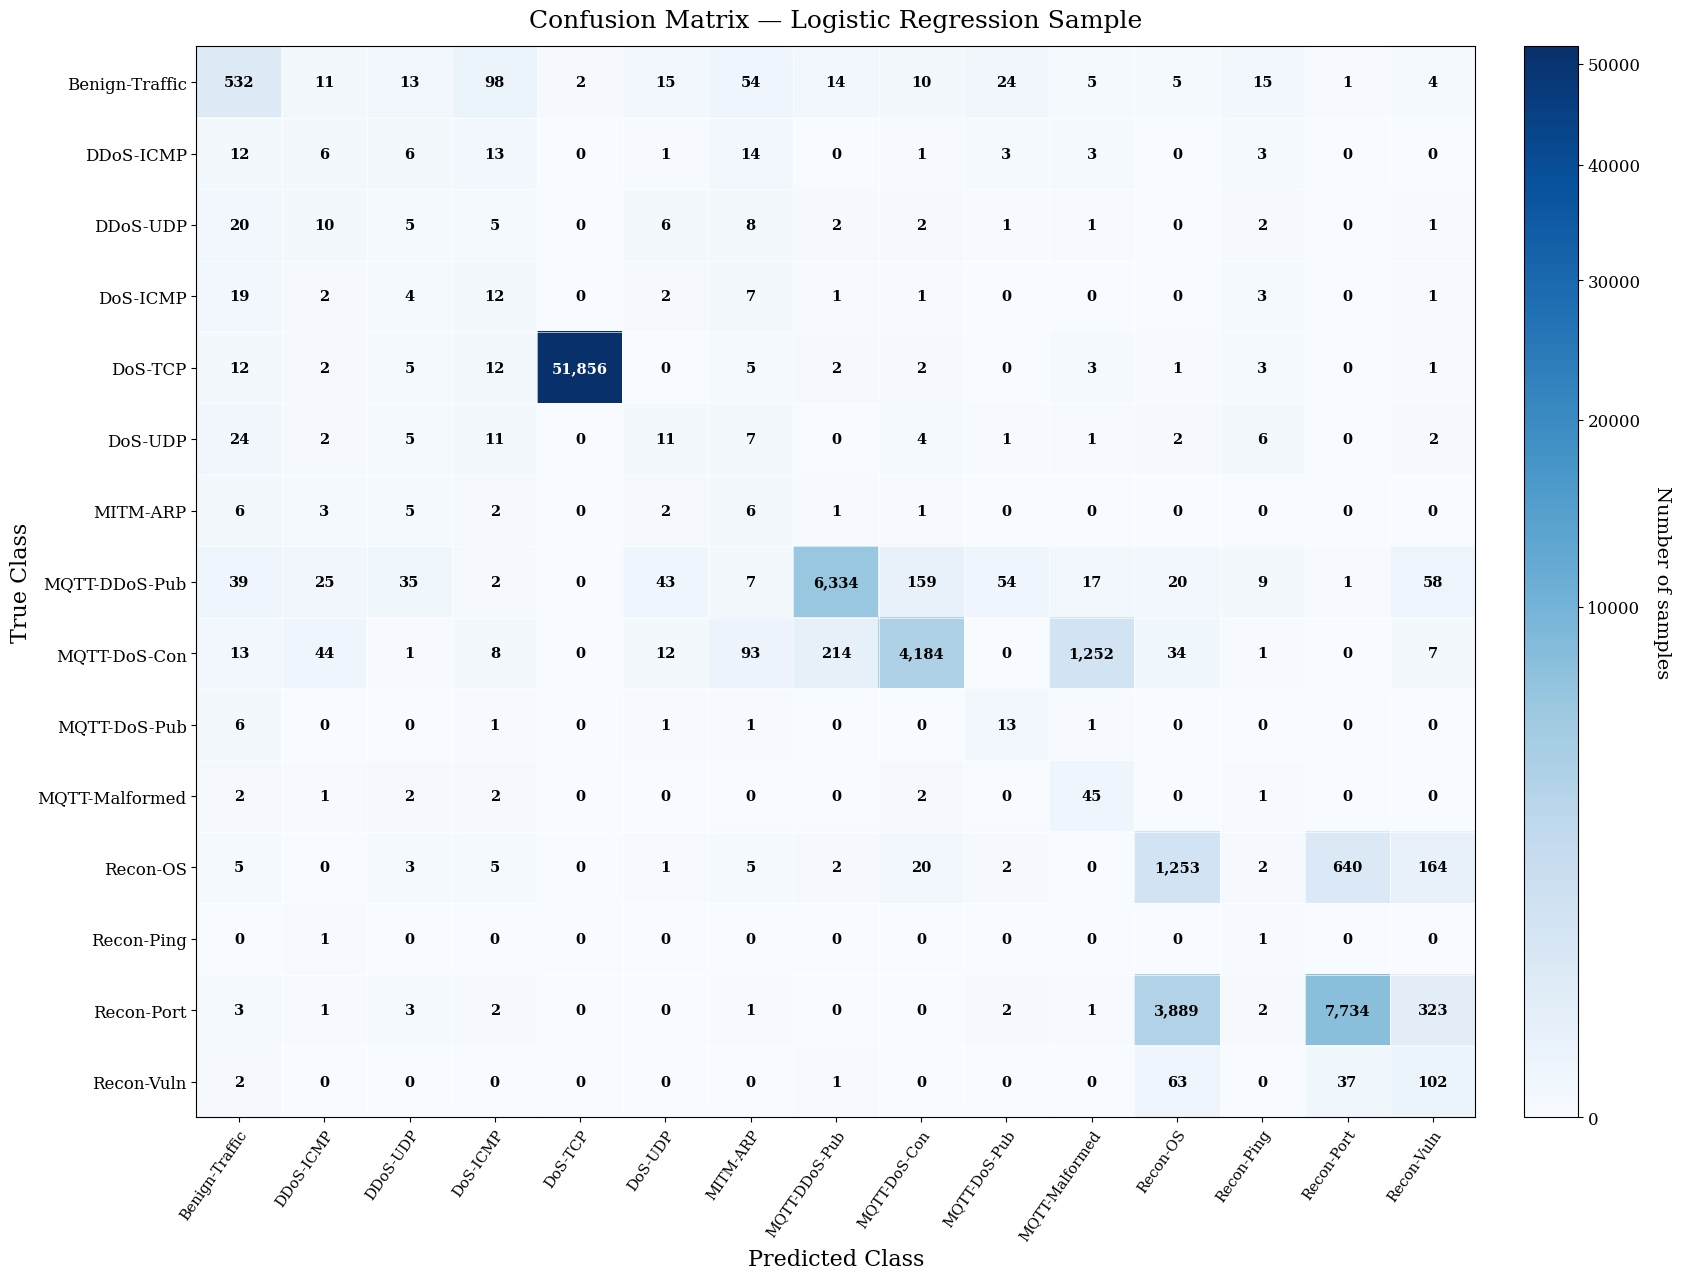

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Logistic_Regression_Sample_conference_confusion_matrix.png


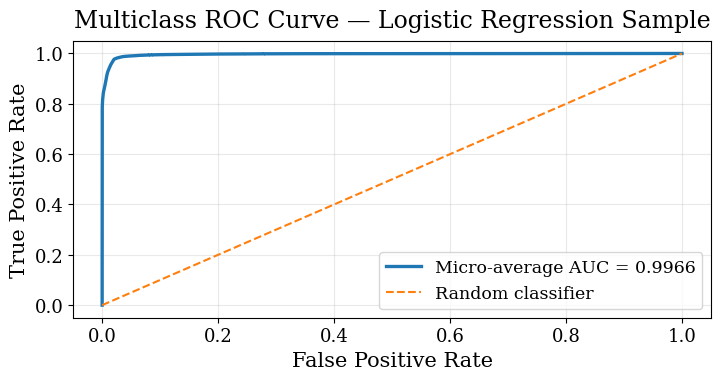

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Logistic_Regression_Sample_conference_roc_curve.png


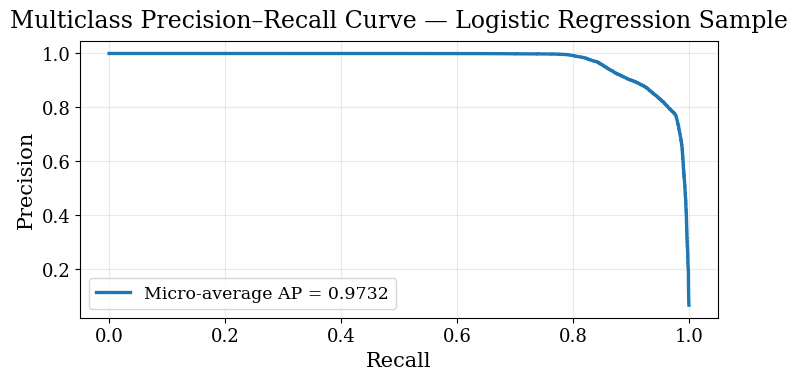

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Logistic_Regression_Sample_conference_precision_recall_curve.png
Accuracy   : 0.901175
Precision  : 0.952747
Recall     : 0.901175
F1 Score   : 0.919473
Train Time : 163.15 seconds
Model saved : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/Logistic_Regression_Sample.joblib
Report saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Classification_Reports/Logistic_Regression_Sample_classification_report.csv


LogisticRegression(class_weight='balanced', max_iter=500, n_jobs=-1,
                   random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

run_multi(
    "Logistic Regression Sample",
    lr_model,
    X_train_sample_scaled,
    y_train_sample,
    X_test_sample_scaled,
    y_test_sample
)


Training: Gradient Boosting Sample
Generating predictions once...
Prediction cache saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/Gradient_Boosting_Sample_conference_cache.npz


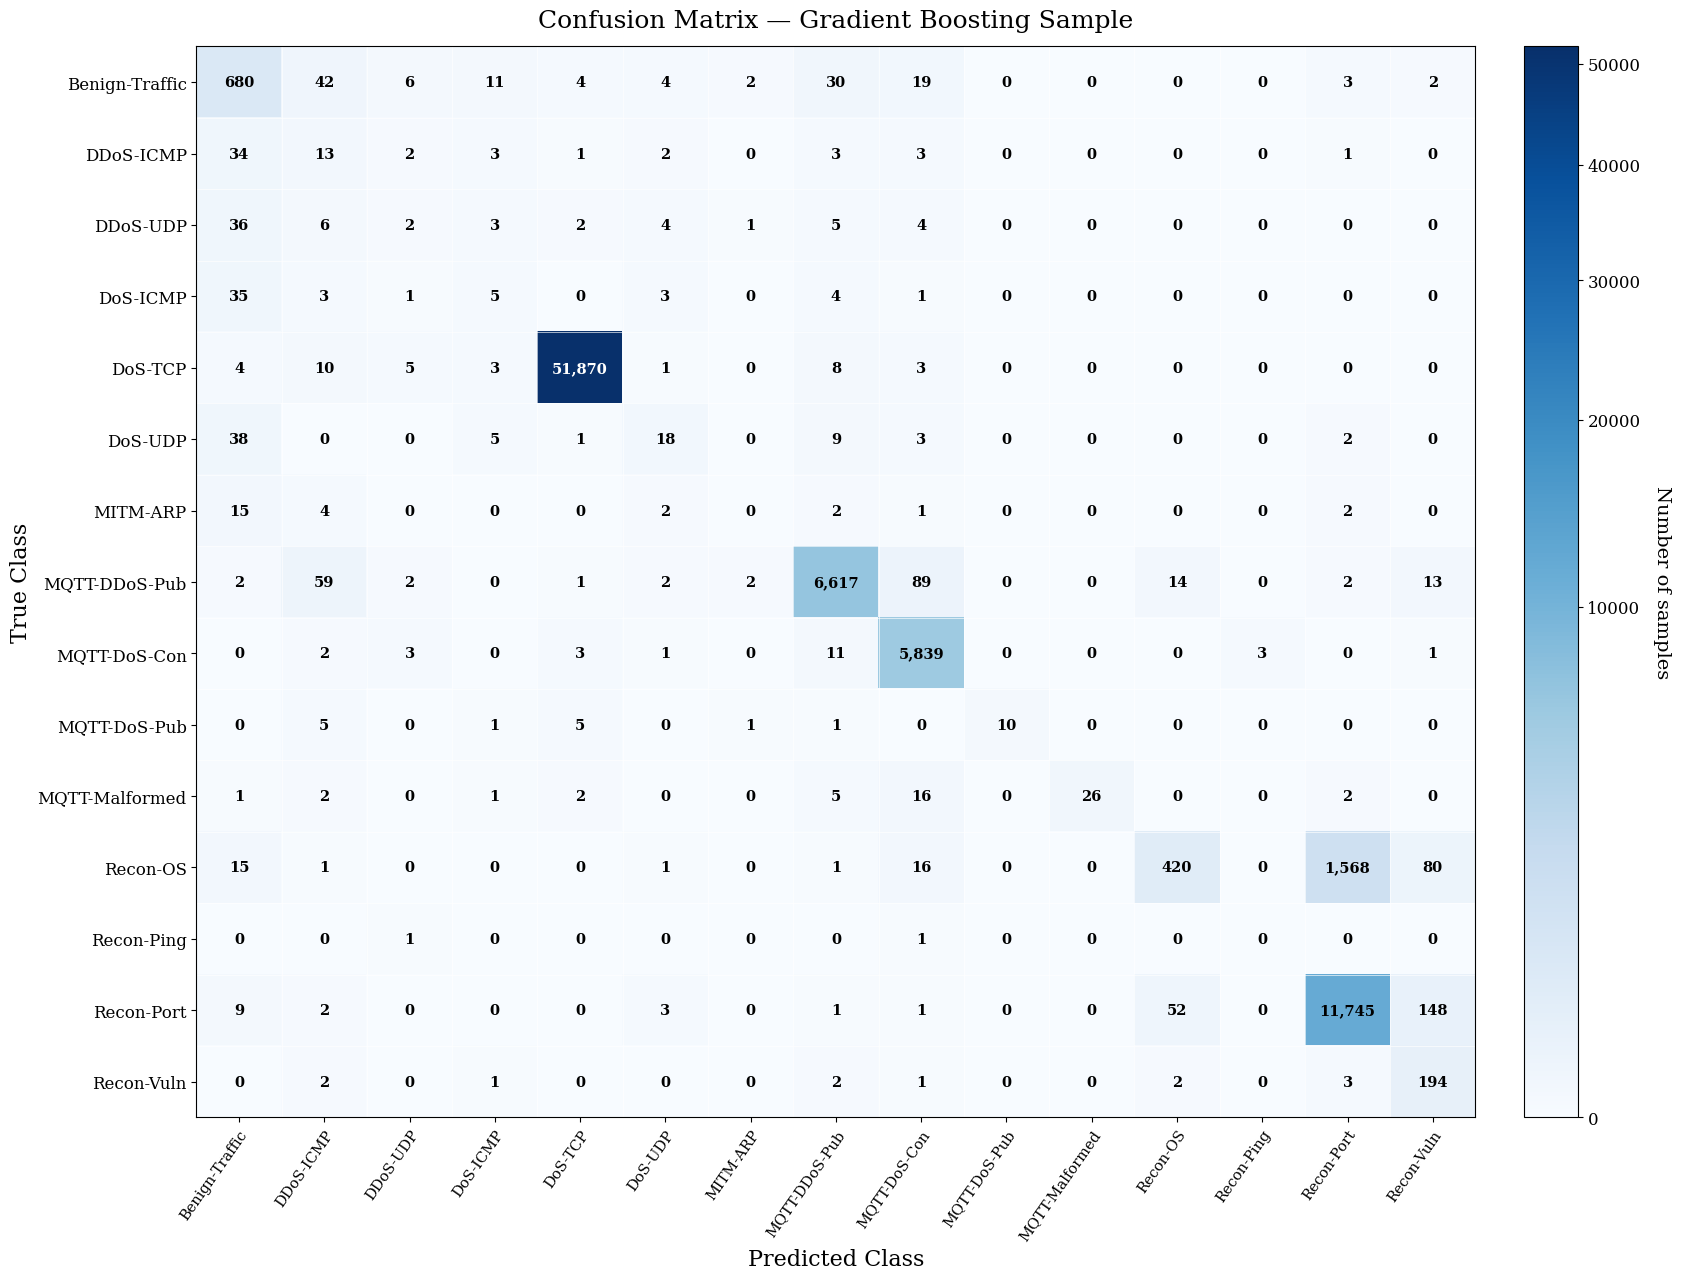

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Gradient_Boosting_Sample_conference_confusion_matrix.png


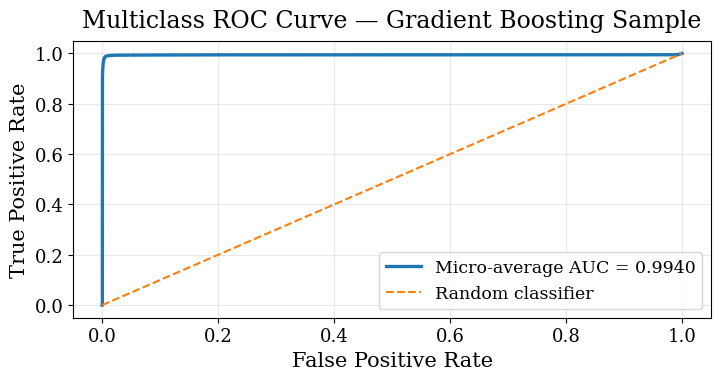

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Gradient_Boosting_Sample_conference_roc_curve.png


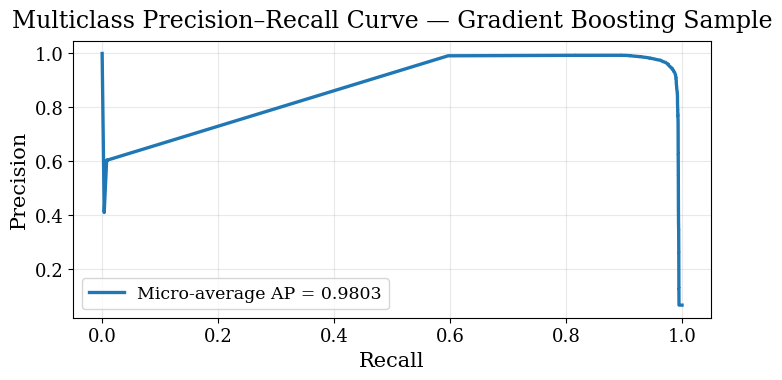

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Gradient_Boosting_Sample_conference_precision_recall_curve.png
Accuracy   : 0.967988
Precision  : 0.968902
Recall     : 0.967988
F1 Score   : 0.962206
Train Time : 2184.30 seconds
Model saved : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/Gradient_Boosting_Sample.joblib
Report saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Classification_Reports/Gradient_Boosting_Sample_classification_report.csv


GradientBoostingClassifier(max_depth=2, n_estimators=50, random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

run_multi(
    "Gradient Boosting Sample",
    gb_model,
    X_train_sample,
    y_train_sample,
    X_test_sample,
    y_test_sample
)


Training: Linear SVM Sample


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Generating predictions once...
Prediction cache saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/Linear_SVM_Sample_conference_cache.npz


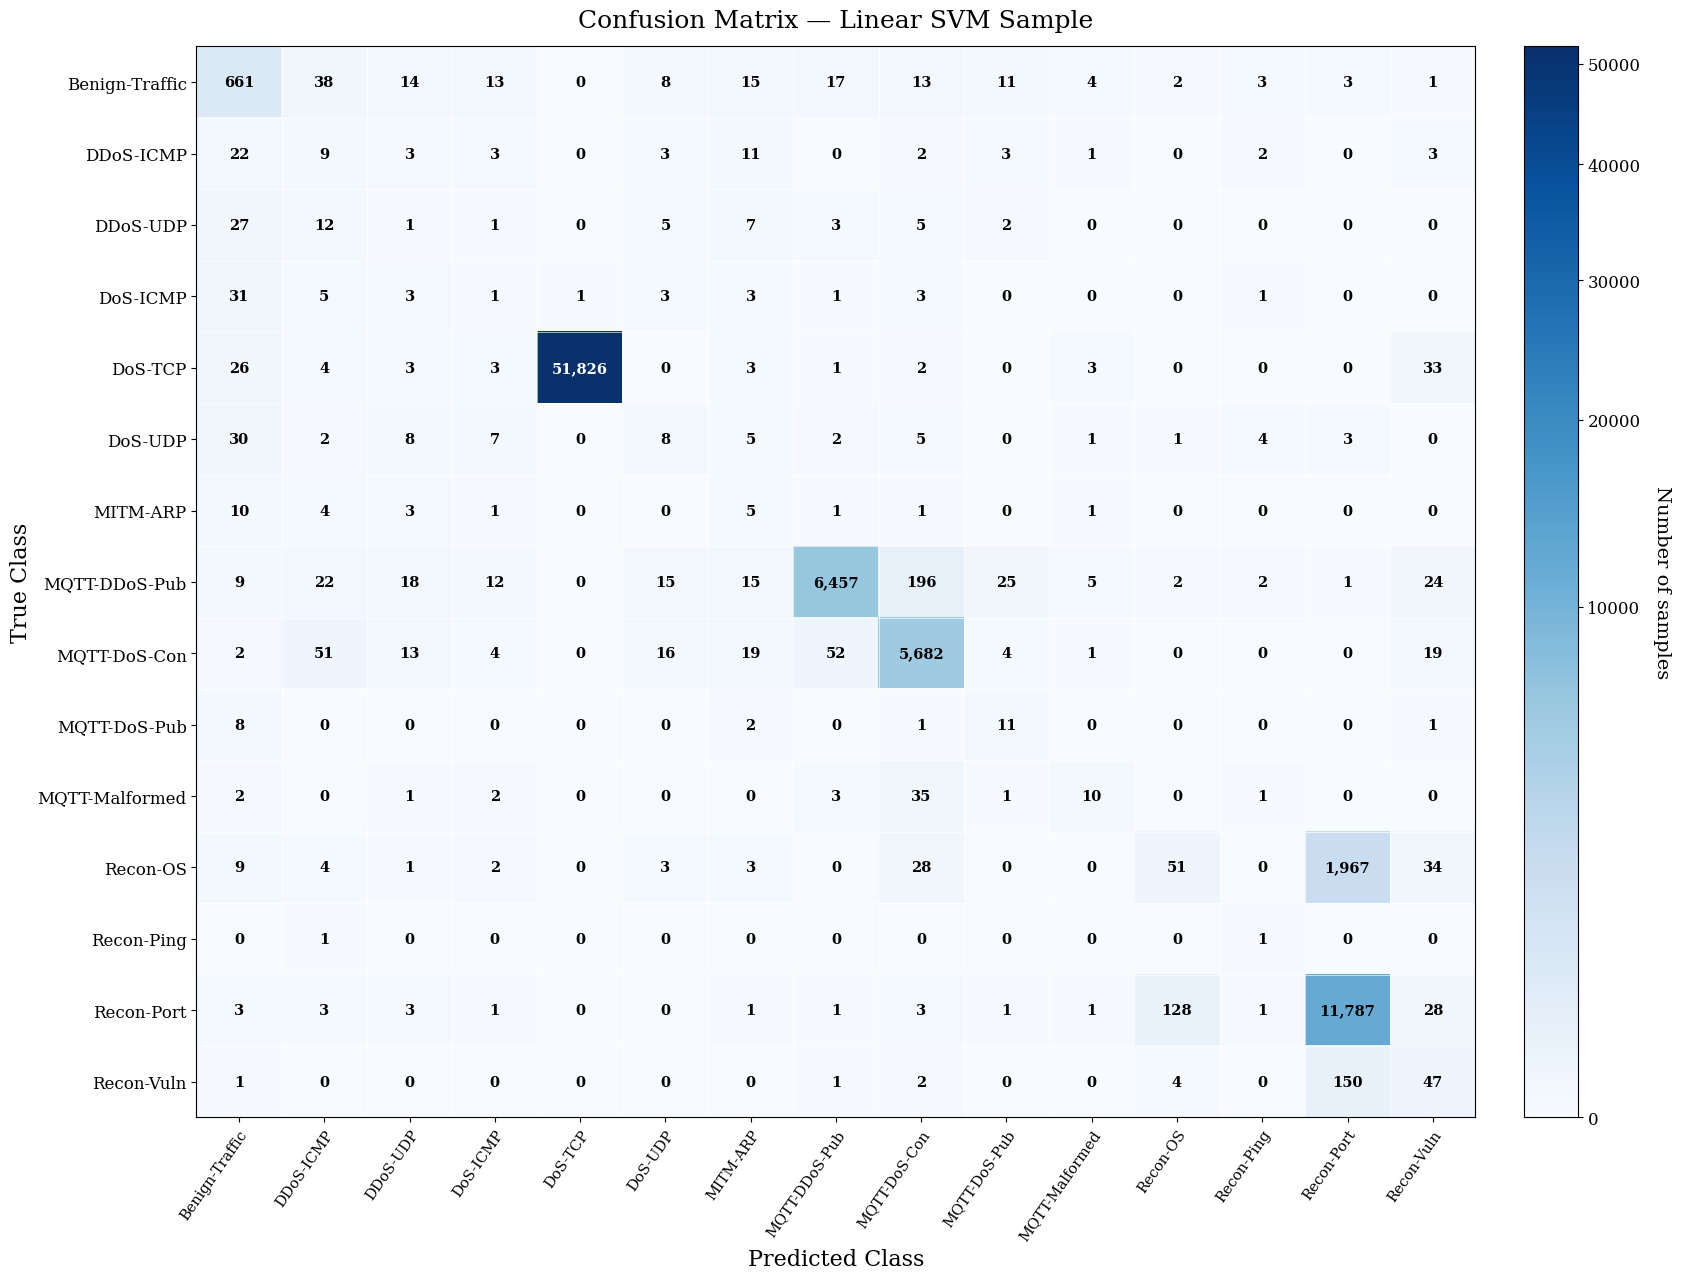

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Linear_SVM_Sample_conference_confusion_matrix.png


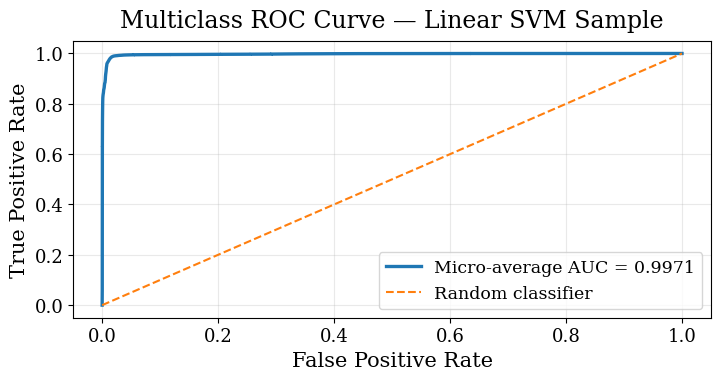

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Linear_SVM_Sample_conference_roc_curve.png


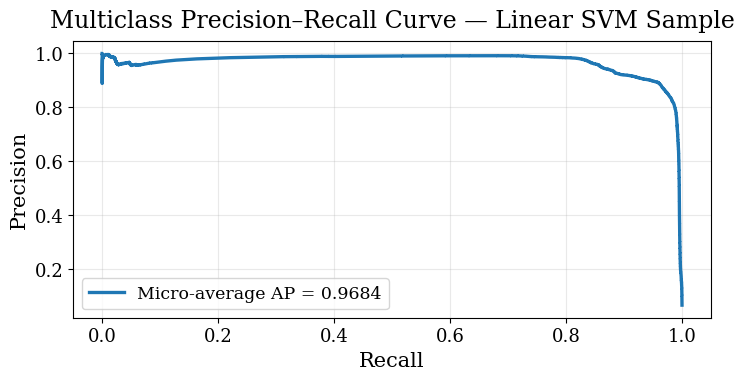

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Linear_SVM_Sample_conference_precision_recall_curve.png
Accuracy   : 0.956963
Precision  : 0.945275
Recall     : 0.956963
F1 Score   : 0.947512
Train Time : 19789.47 seconds
Model saved : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/Linear_SVM_Sample.joblib
Report saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Classification_Reports/Linear_SVM_Sample_classification_report.csv


LinearSVC(class_weight='balanced', max_iter=3000, random_state=42)

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)

run_multi(
    "Linear SVM Sample",
    svm_model,
    X_train_sample_scaled,
    y_train_sample,
    X_test_sample_scaled,
    y_test_sample
)


Training: KNN Sample
Generating predictions once...
Prediction cache saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/KNN_Sample_conference_cache.npz


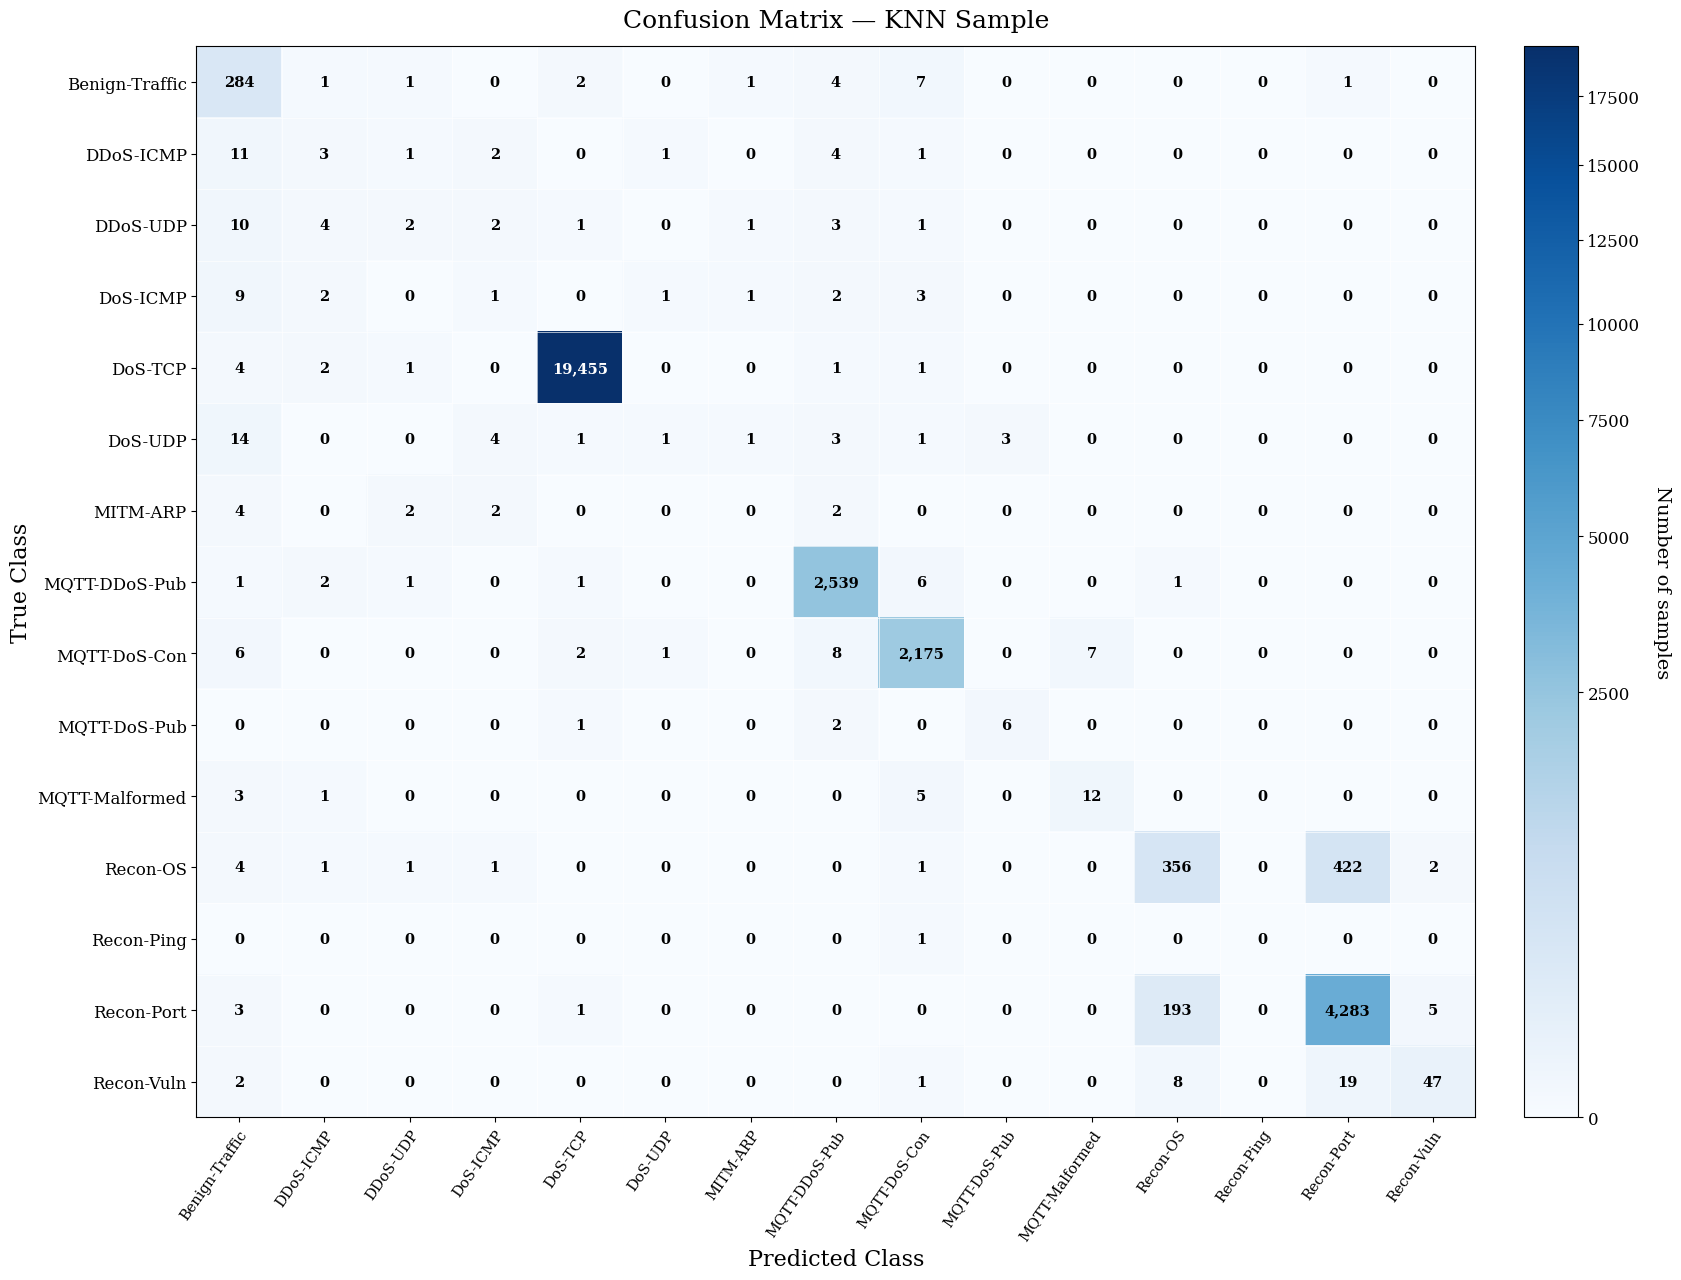

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/KNN_Sample_conference_confusion_matrix.png


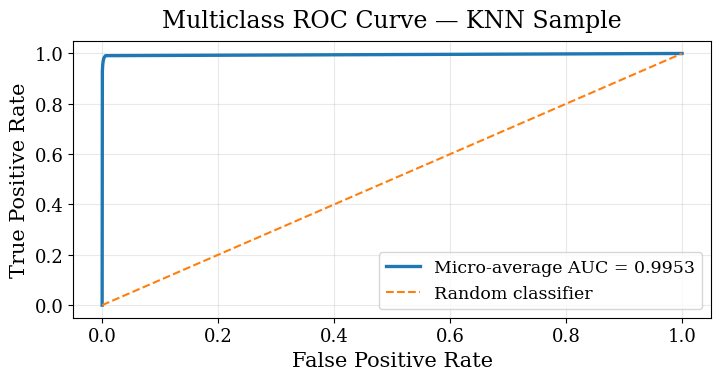

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/KNN_Sample_conference_roc_curve.png


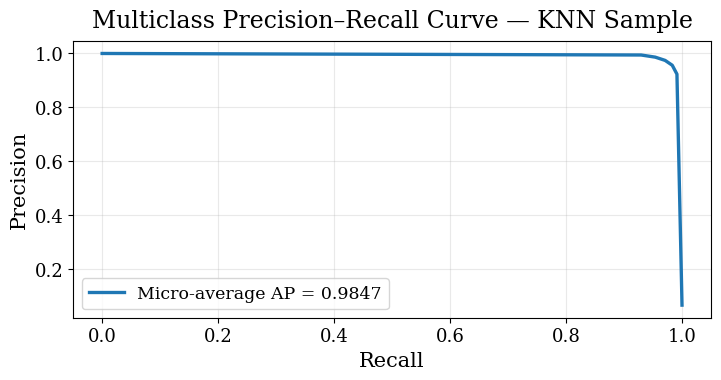

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/KNN_Sample_conference_precision_recall_curve.png
Accuracy   : 0.972133
Precision  : 0.968725
Recall     : 0.972133
F1 Score   : 0.969690
Train Time : 0.02 seconds
Model saved : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/KNN_Sample.joblib
Report saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Classification_Reports/KNN_Sample_classification_report.csv


KNeighborsClassifier(n_jobs=-1)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_knn, _, y_knn, _ = train_test_split(
    X_train_sample_scaled, y_train_sample,
    train_size=min(80000, len(X_train_sample_scaled)),
    random_state=42,
    stratify=y_train_sample
)

X_knn_test, _, y_knn_test, _ = train_test_split(
    X_test_sample_scaled, y_test_sample,
    train_size=min(30000, len(X_test_sample_scaled)),
    random_state=42,
    stratify=y_test_sample
)

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

run_multi(
    "KNN Sample",
    knn_model,
    X_knn,
    y_knn,
    X_knn_test,
    y_knn_test
)


Training: Voting Ensemble Sample
Generating predictions once...
Prediction cache saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/Voting_Ensemble_Sample_conference_cache.npz


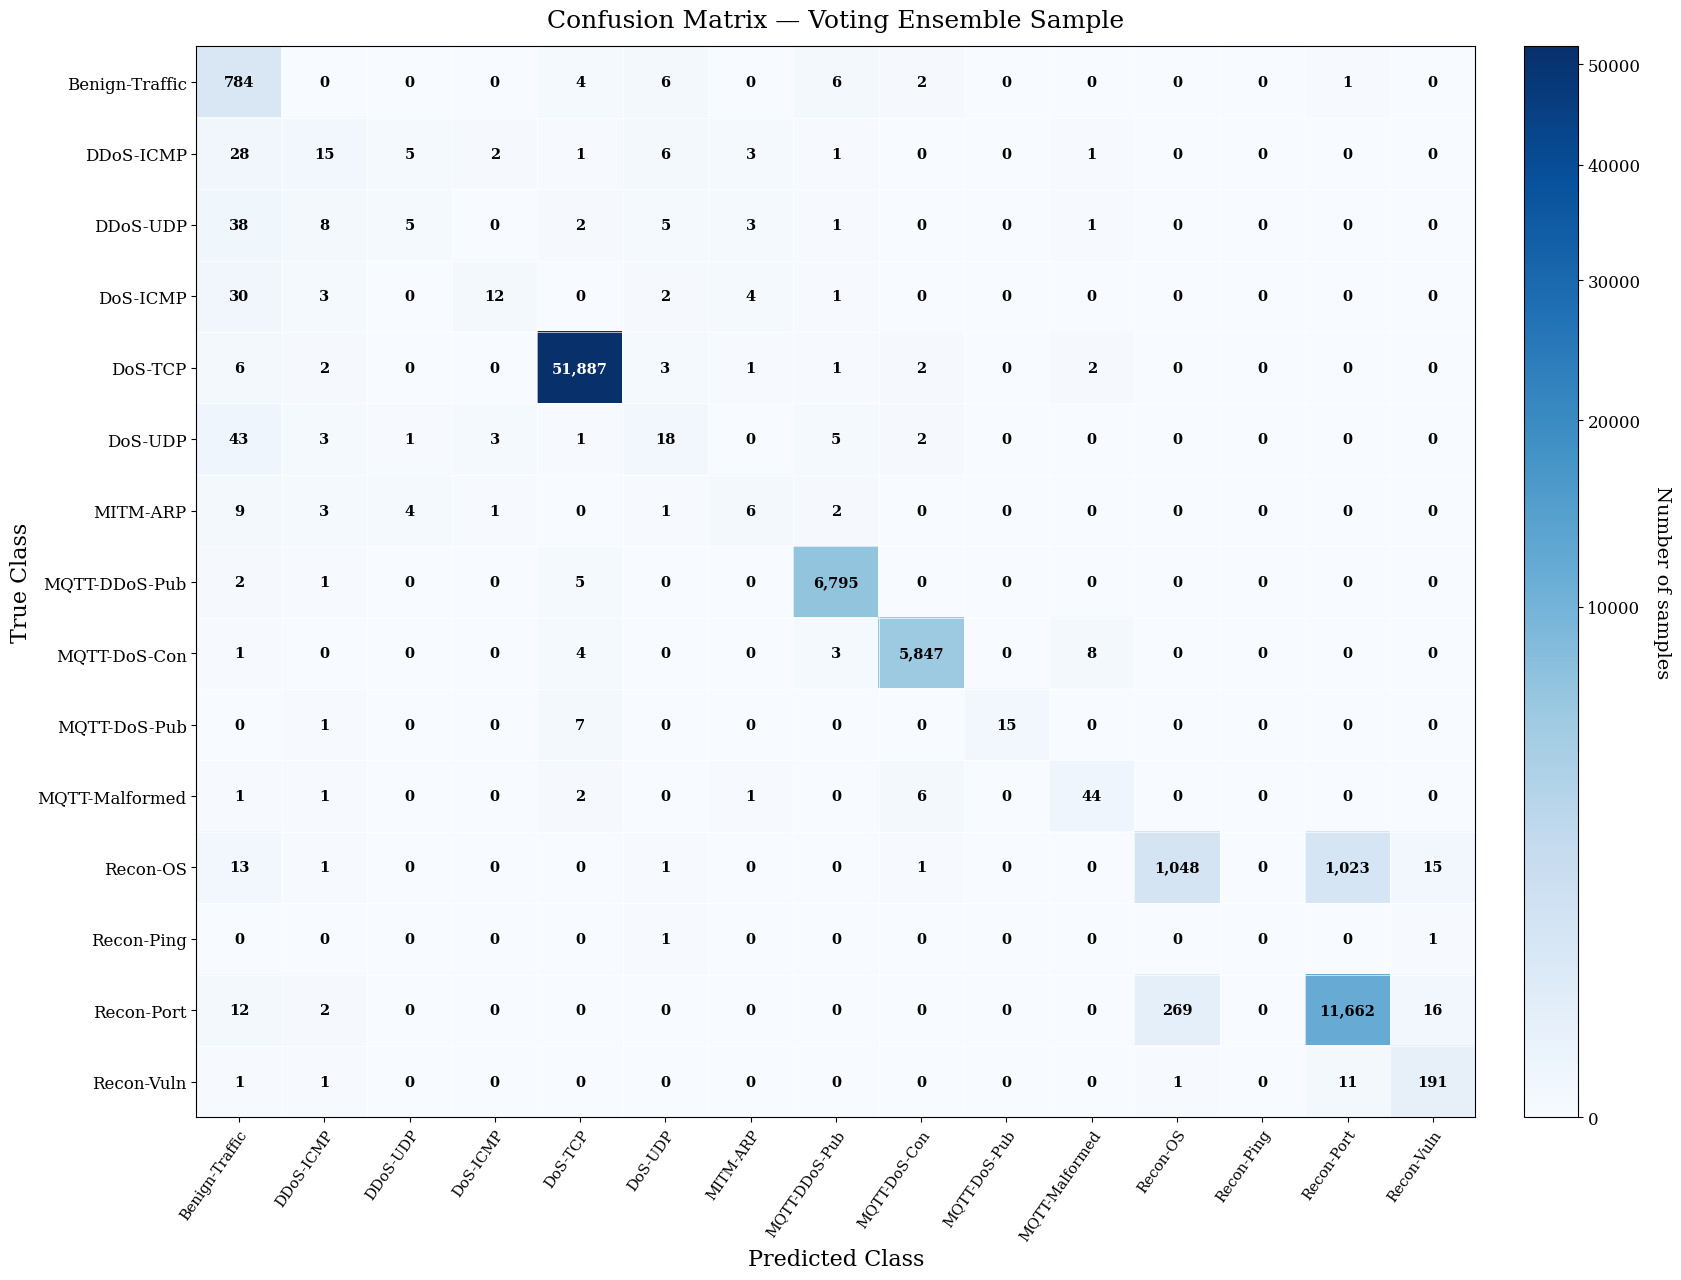

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Voting_Ensemble_Sample_conference_confusion_matrix.png


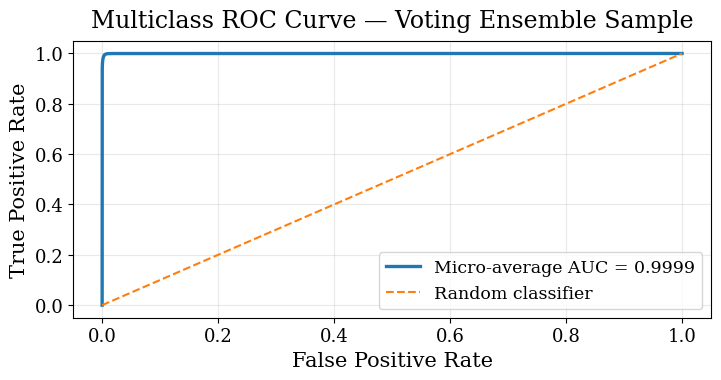

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Voting_Ensemble_Sample_conference_roc_curve.png


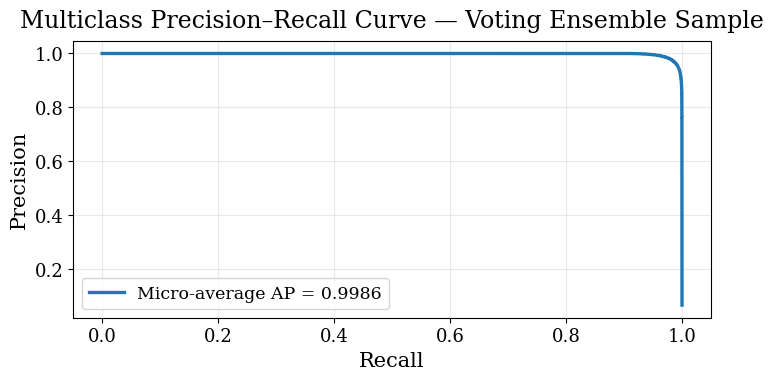

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Voting_Ensemble_Sample_conference_precision_recall_curve.png
Accuracy   : 0.979113
Precision  : 0.977243
Recall     : 0.979113
F1 Score   : 0.976899
Train Time : 121.06 seconds
Model saved : /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/Voting_Ensemble_Sample.joblib
Report saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Classification_Reports/Voting_Ensemble_Sample_classification_report.csv


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=30, n_jobs=-1,
                                                     random_state=42)),
                             ('et',
                              ExtraTreesClassifier(class_weight='balanced',
                                                   n_estimators=30, n_jobs=-1,
                                                   random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0....
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=50, n_jobs=-1,
                                            num_class=15, ...))],
                 n_jobs=-1, voting='soft')

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier

rf_vote = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

et_vote = ExtraTreesClassifier(
    n_estimators=30,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

xgb_vote = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    n_estimators=50,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

voting_model = VotingClassifier(
    estimators=[
        ("rf", rf_vote),
        ("et", et_vote),
        ("xgb", xgb_vote)
    ],
    voting="soft",
    n_jobs=-1
)

run_multi(
    "Voting Ensemble Sample",
    voting_model,
    X_train_sample,
    y_train_sample,
    X_test_sample,
    y_test_sample
)

In [ ]:

if os.path.exists(MULTI_RESULT_FILE):
    multi_results_df = (
        pd.read_csv(MULTI_RESULT_FILE)
        .sort_values("F1", ascending=False)
        .reset_index(drop=True)
    )
else:
    multi_results_df = pd.DataFrame(
        multi_results,
        columns=RESULT_COLUMNS
    ).sort_values(
        "F1",
        ascending=False
    ).reset_index(drop=True)

display(multi_results_df.round(6))


,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Train Time
0,Decision Tree Full,0.996727,0.996690,0.996727,0.996706,0.998246,0.993682,140.019361
1,Random Forest Full,0.984380,0.983560,0.984380,0.983568,0.999832,0.998933,330.837391
2,Extra Trees Full,0.983383,0.982389,0.983383,0.982390,0.999820,0.998867,171.353144
3,XGBoost Full,0.983214,0.982196,0.983214,0.982078,0.999915,0.999060,1397.257856
4,Voting Ensemble Sample,0.979112,0.977243,0.979112,0.976899,0.999884,0.998572,110.516406
5,KNN Sample,0.972133,0.968725,0.972133,0.969690,0.995324,0.984652,0.017999
6,Gradient Boosting Sample,0.967988,0.968902,0.967988,0.962206,0.994006,0.980302,2184.295868
7,Linear SVM Sample,0.956962,0.945275,0.956962,0.947512,0.997084,0.968449,19789.467364
8,Logistic Regression Sample,0.901175,0.952747,0.901175,0.919473,0.996641,0.973250,163.151920


Loaded: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Models/Decision_Tree_Full.joblib
Prediction cache loaded: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Predictions/Decision_Tree_Full_conference_cache.npz


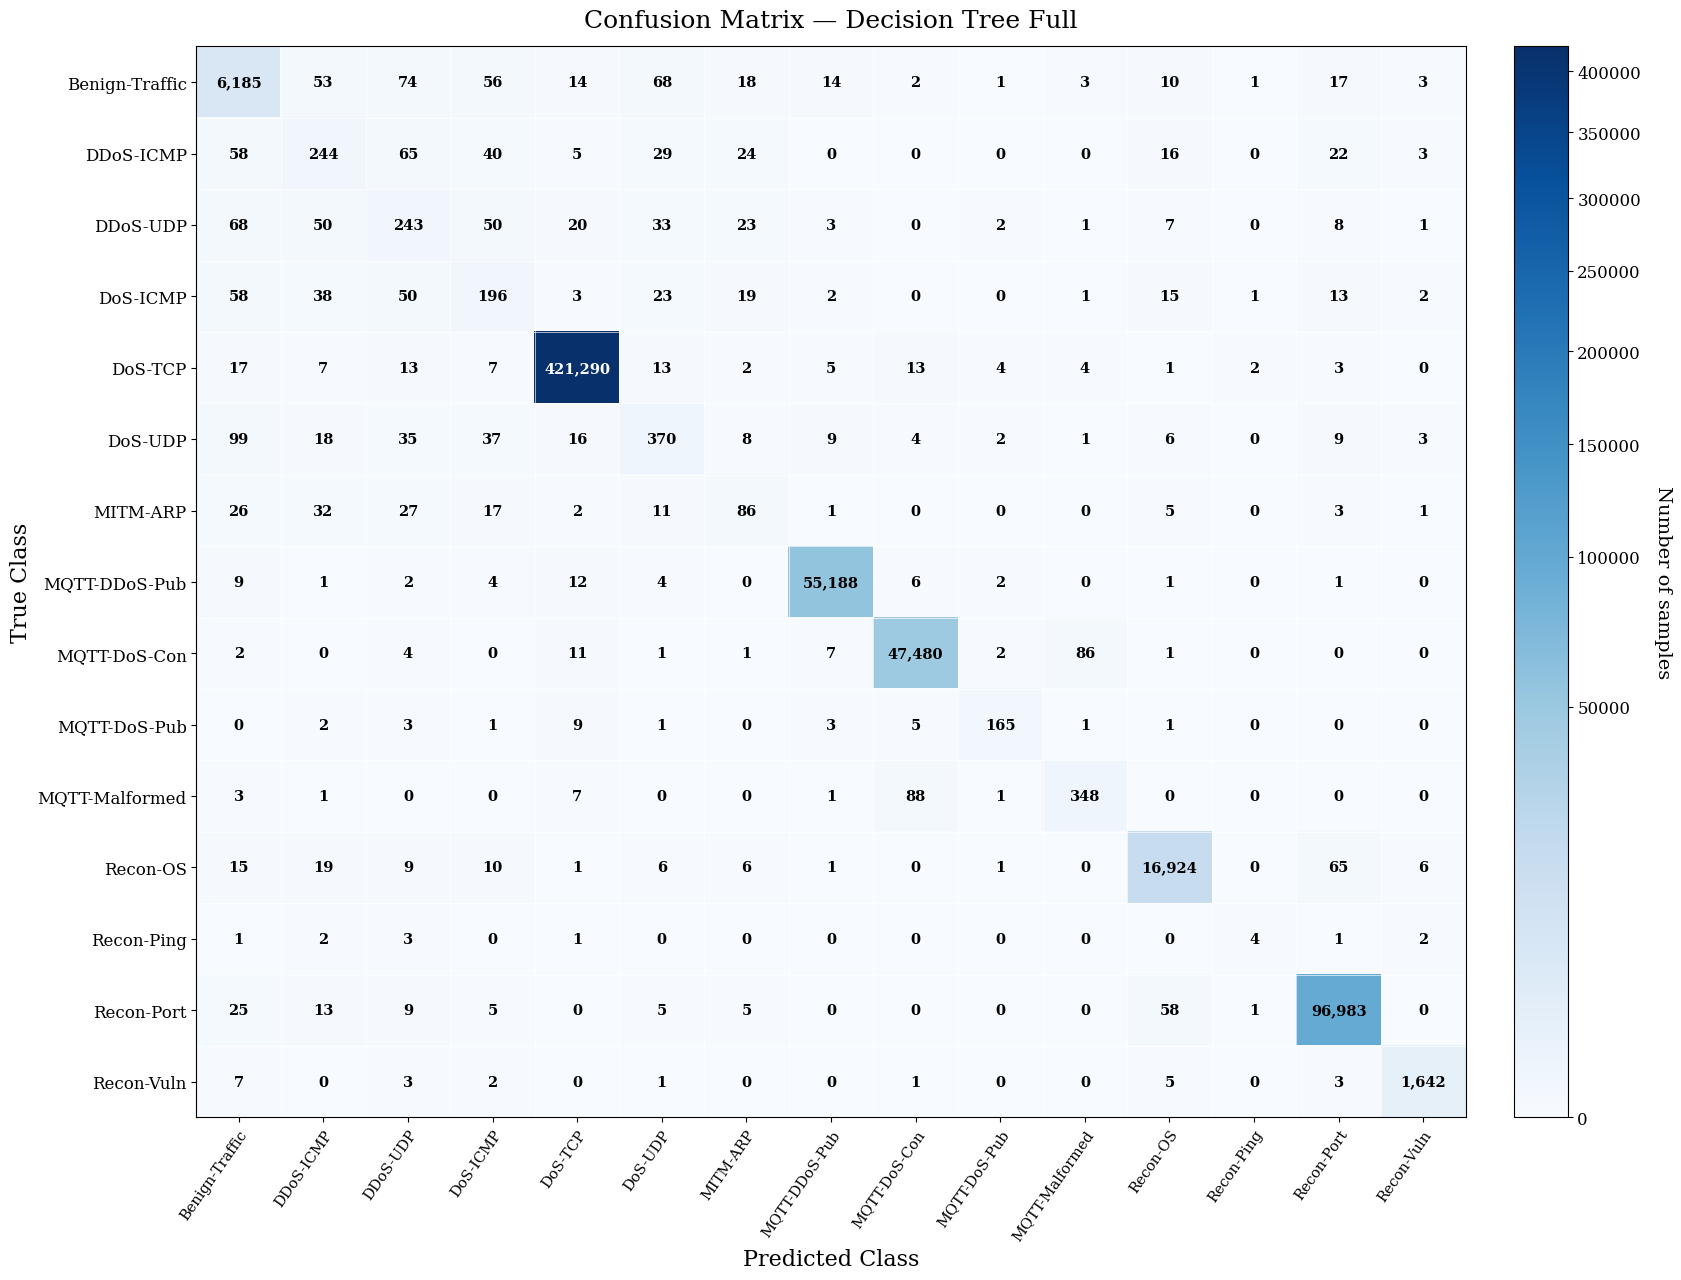

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Decision_Tree_Full_conference_confusion_matrix.png


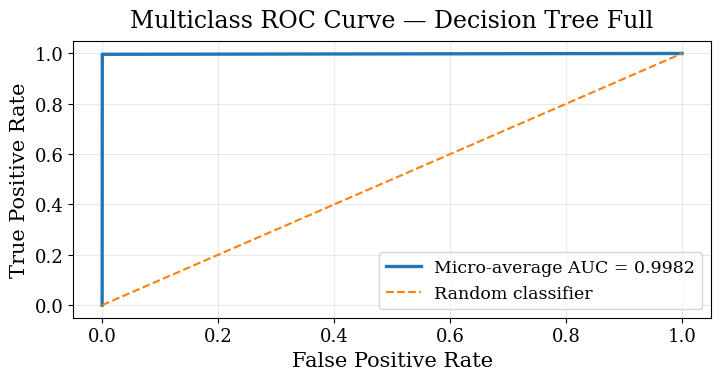

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Decision_Tree_Full_conference_roc_curve.png


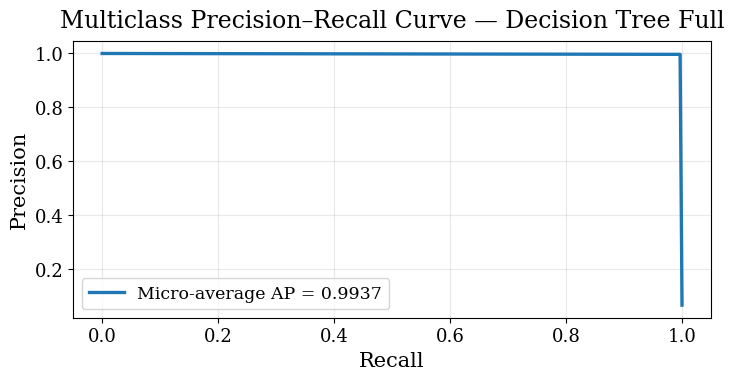

Precision-Recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/Decision_Tree_Full_conference_precision_recall_curve.png
ROC AUC: 0.9982463831170632
PR AUC : 0.993682106782392


In [ ]:

PREFERRED_MODEL_NAME = "Decision Tree Full"
preferred_model_path = os.path.join(
    ML_MULTI_MODEL_DIR,
    f"{safe_filename(PREFERRED_MODEL_NAME)}.joblib"
)

if "dt_model" in globals() and hasattr(dt_model, "predict"):
    conference_model = dt_model
    conference_model_name = PREFERRED_MODEL_NAME
    print("Using Decision Tree already available in memory.")

elif os.path.exists(preferred_model_path):
    conference_model = joblib.load(preferred_model_path)
    conference_model_name = PREFERRED_MODEL_NAME
    print("Loaded:", preferred_model_path)

else:
    if not os.path.exists(MULTI_RESULT_FILE):
        raise FileNotFoundError(
            "No trained model or multiclass result file was found. "
            "Run the Decision Tree training cell once."
        )

    ranked_results = (
        pd.read_csv(MULTI_RESULT_FILE)
        .sort_values("F1", ascending=False)
    )

    conference_model = None
    conference_model_name = None

    for model_name in ranked_results["Model"].astype(str):
        candidate_path = os.path.join(
            ML_MULTI_MODEL_DIR,
            f"{safe_filename(model_name)}.joblib"
        )
        if os.path.exists(candidate_path):
            candidate_model = joblib.load(candidate_path)

            if hasattr(candidate_model, "predict_proba"):
                conference_model = candidate_model
                conference_model_name = model_name
                print("Fallback model loaded:", candidate_path)
                break

    if conference_model is None:
        raise FileNotFoundError(
            "No saved probability-producing model was found."
        )

conference_artifacts = plot_multiclass_conference_figures(
    model=conference_model,
    model_name=conference_model_name,
    X_test_data=X_test_full,
    y_test_data=y_test_full,
    class_names=le.classes_,
    force_recompute=False
)

conference_y_pred = conference_artifacts["y_pred"]

print("ROC AUC:", conference_artifacts["roc_auc"])
print("PR AUC :", conference_artifacts["pr_auc"])


statistical test

In [ ]:
# ================================================================
# MULTICLASS McNEMAR TEST
# DECISION TREE VS RF, ET, XGBOOST AND VOTING ENSEMBLE
# ================================================================

import os
import gc
import joblib
import numpy as np
import pandas as pd

from IPython.display import display
from statsmodels.stats.contingency_tables import mcnemar


# ----------------------------------------------------------------
# 1. Paths
# ----------------------------------------------------------------

OUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"

ML_MULTI_OUTPUT_DIR = os.path.join(
    OUT_PATH,
    "ML_Multiclass_Results"
)

ML_MULTI_MODEL_DIR = os.path.join(
    ML_MULTI_OUTPUT_DIR,
    "Models"
)

STATISTICAL_OUTPUT_PATH = os.path.join(
    ML_MULTI_OUTPUT_DIR,
    "Decision_Tree_Multiclass_McNemar_Results.csv"
)


# ----------------------------------------------------------------
# 2. Required-variable check
# ----------------------------------------------------------------

required_variables = [
    "X_test_full",
    "y_test_full",
    "X_test_sample",
    "y_test_sample"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the multiclass data-preparation and sample-preparation "
        f"cells first. Missing variables: {missing_variables}"
    )


# ----------------------------------------------------------------
# 3. Saved model paths
# ----------------------------------------------------------------

model_paths = {
    "Decision Tree": os.path.join(
        ML_MULTI_MODEL_DIR,
        "Decision_Tree_Full.joblib"
    ),
    "Random Forest": os.path.join(
        ML_MULTI_MODEL_DIR,
        "Random_Forest_Full.joblib"
    ),
    "Extra Trees": os.path.join(
        ML_MULTI_MODEL_DIR,
        "Extra_Trees_Full.joblib"
    ),
    "XGBoost": os.path.join(
        ML_MULTI_MODEL_DIR,
        "XGBoost_Full.joblib"
    ),
    "Voting Ensemble": os.path.join(
        ML_MULTI_MODEL_DIR,
        "Voting_Ensemble_Sample.joblib"
    )
}

missing_model_files = [
    path
    for path in model_paths.values()
    if not os.path.exists(path)
]

if missing_model_files:
    raise FileNotFoundError(
        "The following saved model files were not found:\n"
        + "\n".join(missing_model_files)
    )


# ----------------------------------------------------------------
# 4. Load Decision Tree and generate paired predictions
# ----------------------------------------------------------------

decision_tree_model = joblib.load(
    model_paths["Decision Tree"]
)

dt_pred_full = np.asarray(
    decision_tree_model.predict(
        X_test_full
    )
).reshape(-1)

dt_pred_sample = np.asarray(
    decision_tree_model.predict(
        X_test_sample
    )
).reshape(-1)


# ----------------------------------------------------------------
# 5. McNemar comparison function
# ----------------------------------------------------------------

def mcnemar_compare_multiclass(
    reference_model_name,
    reference_predictions,
    comparison_model_name,
    comparison_predictions,
    true_labels
):

    reference_predictions = np.asarray(
        reference_predictions
    ).reshape(-1)

    comparison_predictions = np.asarray(
        comparison_predictions
    ).reshape(-1)

    true_labels = np.asarray(
        true_labels
    ).reshape(-1)

    if not (
        len(reference_predictions)
        == len(comparison_predictions)
        == len(true_labels)
    ):
        raise ValueError(
            "Predictions and true labels must contain "
            "the same number of observations."
        )

    reference_correct = (
        reference_predictions == true_labels
    )

    comparison_correct = (
        comparison_predictions == true_labels
    )

    reference_correct_comparison_wrong = int(
        np.sum(
            reference_correct
            & ~comparison_correct
        )
    )

    reference_wrong_comparison_correct = int(
        np.sum(
            ~reference_correct
            & comparison_correct
        )
    )

    both_correct = int(
        np.sum(
            reference_correct
            & comparison_correct
        )
    )

    both_wrong = int(
        np.sum(
            ~reference_correct
            & ~comparison_correct
        )
    )

    discordant_predictions = (
        reference_correct_comparison_wrong
        + reference_wrong_comparison_correct
    )

    contingency_table = [
        [
            both_correct,
            reference_correct_comparison_wrong
        ],
        [
            reference_wrong_comparison_correct,
            both_wrong
        ]
    ]

    if discordant_predictions == 0:

        statistic = 0.0
        p_value = 1.0
        test_method = "No discordant predictions"

    elif discordant_predictions < 25:

        test_result = mcnemar(
            contingency_table,
            exact=True
        )

        statistic = float(
            test_result.statistic
        )

        p_value = float(
            test_result.pvalue
        )

        test_method = "Exact McNemar test"

    else:

        test_result = mcnemar(
            contingency_table,
            exact=False,
            correction=True
        )

        statistic = float(
            test_result.statistic
        )

        p_value = float(
            test_result.pvalue
        )

        test_method = (
            "McNemar chi-square with correction"
        )

    if p_value < 0.05:

        significance = (
            "Statistically significant"
        )

        if (
            reference_correct_comparison_wrong
            >
            reference_wrong_comparison_correct
        ):
            conclusion = (
                f"{reference_model_name} made significantly more "
                f"correct predictions than {comparison_model_name}."
            )

        elif (
            reference_correct_comparison_wrong
            <
            reference_wrong_comparison_correct
        ):
            conclusion = (
                f"{comparison_model_name} made significantly more "
                f"correct predictions than {reference_model_name}."
            )

        else:
            conclusion = (
                "The models differed significantly, but neither "
                "showed a directional advantage."
            )

    else:

        significance = (
            "Not statistically significant"
        )

        conclusion = (
            f"No statistically significant difference was found "
            f"between {reference_model_name} and "
            f"{comparison_model_name}."
        )

    return {
        "Reference Model": reference_model_name,
        "Comparison Model": comparison_model_name,
        "Reference Correct / Comparison Wrong":
            reference_correct_comparison_wrong,
        "Reference Wrong / Comparison Correct":
            reference_wrong_comparison_correct,
        "Discordant Predictions":
            discordant_predictions,
        "Test Method": test_method,
        "Statistic": statistic,
        "P-value": p_value,
        "Significance (α=0.05)": significance,
        "Conclusion": conclusion
    }


# ----------------------------------------------------------------
# 6. Decision Tree vs Random Forest, Extra Trees and XGBoost
#    All use the same full test set
# ----------------------------------------------------------------

mcnemar_results = []

full_comparison_models = [
    "Random Forest",
    "Extra Trees",
    "XGBoost"
]

for comparison_model_name in full_comparison_models:

    comparison_model = joblib.load(
        model_paths[comparison_model_name]
    )

    comparison_predictions = np.asarray(
        comparison_model.predict(
            X_test_full
        )
    ).reshape(-1)

    mcnemar_results.append(
        mcnemar_compare_multiclass(
            reference_model_name="Decision Tree",
            reference_predictions=dt_pred_full,
            comparison_model_name=comparison_model_name,
            comparison_predictions=comparison_predictions,
            true_labels=y_test_full
        )
    )

    del comparison_model
    del comparison_predictions
    gc.collect()


# ----------------------------------------------------------------
# 7. Decision Tree vs Voting Ensemble
#    Both models use the same sample test observations
# ----------------------------------------------------------------

voting_model = joblib.load(
    model_paths["Voting Ensemble"]
)

voting_predictions = np.asarray(
    voting_model.predict(
        X_test_sample
    )
).reshape(-1)

mcnemar_results.append(
    mcnemar_compare_multiclass(
        reference_model_name="Decision Tree",
        reference_predictions=dt_pred_sample,
        comparison_model_name="Voting Ensemble",
        comparison_predictions=voting_predictions,
        true_labels=y_test_sample
    )
)


# ----------------------------------------------------------------
# 8. Final table
# ----------------------------------------------------------------

mcnemar_results_df = pd.DataFrame(
    mcnemar_results
)

mcnemar_results_df.to_csv(
    STATISTICAL_OUTPUT_PATH,
    index=False
)

display(
    mcnemar_results_df.style.format(
        {
            "Statistic": "{:.6f}",
            "P-value": "{:.6e}"
        }
    )
)

print("\nStatistical test results saved:")
print(STATISTICAL_OUTPUT_PATH)

,Reference Model,Comparison Model,Reference Correct / Comparison Wrong,Reference Wrong / Comparison Correct,Discordant Predictions,Test Method,Statistic,P-value,Significance (α=0.05),Conclusion
0,Decision Tree,Random Forest,8748,729,9477,McNemar chi-square with correction,6783.615490,0.000000e+00,Statistically significant,Decision Tree made significantly more correct predictions than Random Forest.
1,Decision Tree,Extra Trees,9370,704,10074,McNemar chi-square with correction,7453.069784,0.000000e+00,Statistically significant,Decision Tree made significantly more correct predictions than Extra Trees.
2,Decision Tree,XGBoost,9626,850,10476,McNemar chi-square with correction,7350.193299,0.000000e+00,Statistically significant,Decision Tree made significantly more correct predictions than XGBoost.
3,Decision Tree,Voting Ensemble,1476,65,1541,McNemar chi-square with correction,1290.136275,1.573090e-282,Statistically significant,Decision Tree made significantly more correct predictions than Voting Ensemble.



Statistical test results saved:
/content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Decision_Tree_Multiclass_McNemar_Results.csv


In [15]:
# ================================================================
# LOAD SAVED MULTICLASS DECISION TREE FOR SHAP
# Run this cell immediately before the SHAP beeswarm cell
# ================================================================

import os
import re
import joblib


# Create safe filename exactly as used during model saving
def safe_filename(text):
    text = str(text).strip()
    text = re.sub(r"[^A-Za-z0-9_-]+", "_", text)
    return text.strip("_")


# Create model directory path if the earlier path cell
# has not been executed in the current runtime
if "ML_MULTI_MODEL_DIR" not in globals():

    if "OUT_PATH" not in globals():
        OUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"

    ML_MULTI_OUTPUT_DIR = os.path.join(
        OUT_PATH,
        "ML_Multiclass_Results"
    )

    ML_MULTI_MODEL_DIR = os.path.join(
        ML_MULTI_OUTPUT_DIR,
        "Models"
    )


PREFERRED_MODEL_NAME = "Decision Tree Full"

preferred_model_path = os.path.join(
    ML_MULTI_MODEL_DIR,
    f"{safe_filename(PREFERRED_MODEL_NAME)}.joblib"
)


# Use model already present in memory when available
if (
    "dt_model" in globals()
    and hasattr(dt_model, "predict")
):
    conference_model = dt_model
    conference_model_name = PREFERRED_MODEL_NAME

    print(
        "Using Decision Tree model already available in memory."
    )

# Otherwise load the trained model from Google Drive
elif os.path.exists(preferred_model_path):

    conference_model = joblib.load(
        preferred_model_path
    )

    conference_model_name = PREFERRED_MODEL_NAME

    print(
        "Saved Decision Tree model loaded successfully."
    )
    print(
        "Model path:",
        preferred_model_path
    )

else:
    print(
        "Expected model path:",
        preferred_model_path
    )

    if os.path.isdir(ML_MULTI_MODEL_DIR):
        saved_models = [
            filename
            for filename in os.listdir(ML_MULTI_MODEL_DIR)
            if filename.lower().endswith(".joblib")
        ]

        print(
            "Available saved models:",
            saved_models
        )

    raise FileNotFoundError(
        "Decision Tree Full model was not found. "
        "Run the multiclass Decision Tree training cell once "
        "so that Decision_Tree_Full.joblib is saved."
    )


# Final validation
if not hasattr(conference_model, "predict"):
    raise TypeError(
        "The loaded object is not a valid fitted classifier."
    )

print(
    "\nconference_model_name:",
    conference_model_name
)

print(
    "Model type:",
    type(conference_model).__name__
)

print(
    "Model is ready for SHAP beeswarm."
)

Using Decision Tree model already available in memory.

conference_model_name: Decision Tree Full
Model type: DecisionTreeClassifier
Model is ready for SHAP beeswarm.


Available classes:
0 : Benign Traffic
1 : DDoS ICMP Flood
2 : DDoS UDP Flood
3 : DoS ICMP Flood
4 : DoS TCP Flood
5 : DoS UDP Flood
6 : MITM ARP Spoofing
7 : MQTT DDoS Publish Flood
8 : MQTT DoS Connect Flood
9 : MQTT DoS Publish Flood
10 : MQTT Malformed
11 : Recon OS Scan
12 : Recon Ping Sweep
13 : Recon Port Scan
14 : Recon Vulnerability Scan

Selected SHAP output class:
0 : Benign Traffic

SHAP explanation sample shape: (150, 79)

Calculating SHAP values...
Raw SHAP output shape: (150, 79, 15)
Selected-class SHAP shape: (150, 79)


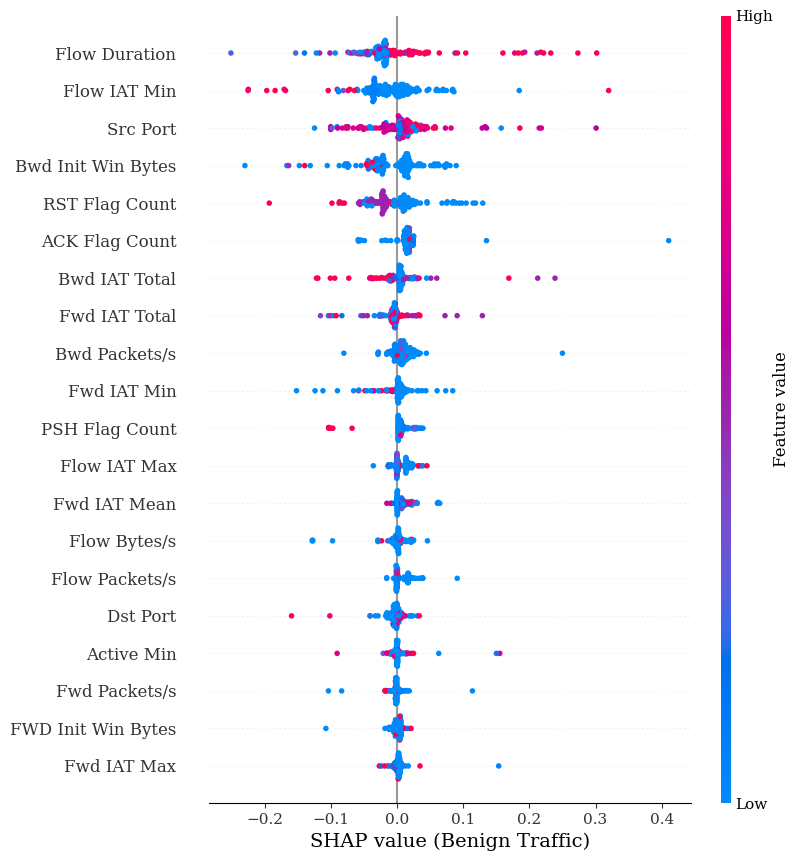


SHAP beeswarm PNG: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/LIME_SHAP/Decision_Tree_Full_multiclass_Benign_Traffic_SHAP_beeswarm.png
SHAP beeswarm PDF: /content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/LIME_SHAP/Decision_Tree_Full_multiclass_Benign_Traffic_SHAP_beeswarm.pdf


In [16]:
# ================================================================
# FAST MULTICLASS SHAP BEESWARM
# Target output: Benign Traffic class
# No model retraining required
# ================================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


# ------------------------------------------------
# Configuration
# ------------------------------------------------
SAMPLES_PER_CLASS = 10
MAX_FEATURES_TO_DISPLAY = 20
RANDOM_SEED = 42


# ------------------------------------------------
# Required-variable checks
# ------------------------------------------------
required_variables = [
    "conference_model",
    "conference_model_name",
    "X_test_full",
    "y_test_full",
    "le",
    "XAI_PATH"
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the data preparation and saved-model loading cells first. "
        f"Missing variables: {missing_variables}"
    )


# ------------------------------------------------
# Decision Tree / tree-model validation
# ------------------------------------------------
if not hasattr(conference_model, "predict"):
    raise TypeError(
        "conference_model is not a valid fitted classifier."
    )


# ------------------------------------------------
# Preserve feature names
# This also prevents sklearn feature-name warnings
# ------------------------------------------------
if isinstance(X_test_full, pd.DataFrame):

    X_test_dataframe = X_test_full

    feature_names = (
        X_test_dataframe
        .columns
        .astype(str)
        .tolist()
    )

else:

    if hasattr(conference_model, "feature_names_in_"):
        feature_names = (
            conference_model
            .feature_names_in_
            .astype(str)
            .tolist()
        )

    elif "FEATURE_NAMES" in globals():
        feature_names = list(FEATURE_NAMES)

    else:
        feature_names = [
            f"Feature_{feature_index}"
            for feature_index in range(
                np.asarray(X_test_full).shape[1]
            )
        ]

    X_test_dataframe = pd.DataFrame(
        np.asarray(X_test_full),
        columns=feature_names
    )


class_names = [
    str(class_name)
    for class_name in le.classes_
]

number_of_classes = len(class_names)

print("Available classes:")
for class_index, class_name in enumerate(class_names):
    print(class_index, ":", class_name)


# ------------------------------------------------
# Find the Benign Traffic class automatically
# ------------------------------------------------
target_class_index = None

for class_index, class_name in enumerate(class_names):

    normalized_name = (
        class_name
        .lower()
        .replace("-", " ")
        .replace("_", " ")
        .strip()
    )

    if normalized_name in {
        "benign",
        "benign traffic"
    }:
        target_class_index = class_index
        break


if target_class_index is None:
    raise ValueError(
        "Benign or Benign Traffic was not found in le.classes_. "
        f"Available classes: {class_names}"
    )


target_class_name = class_names[target_class_index]

print("\nSelected SHAP output class:")
print(
    target_class_index,
    ":",
    target_class_name
)


# ------------------------------------------------
# Balanced explanation sample
# Take a few records from every traffic class
# ------------------------------------------------
y_test_array = np.asarray(
    y_test_full
).reshape(-1)

random_generator = np.random.default_rng(
    RANDOM_SEED
)

selected_indices = []

for class_index in range(number_of_classes):

    available_indices = np.flatnonzero(
        y_test_array == class_index
    )

    if len(available_indices) == 0:
        print(
            f"Class {class_index} has no test samples; skipped."
        )
        continue

    number_to_take = min(
        SAMPLES_PER_CLASS,
        len(available_indices)
    )

    chosen_indices = random_generator.choice(
        available_indices,
        size=number_to_take,
        replace=False
    )

    selected_indices.extend(
        chosen_indices.tolist()
    )


selected_indices = np.asarray(
    selected_indices,
    dtype=np.int64
)

# Shuffle selected observations
random_generator.shuffle(
    selected_indices
)

X_shap_sample = (
    X_test_dataframe
    .iloc[selected_indices]
    .copy()
)

print(
    "\nSHAP explanation sample shape:",
    X_shap_sample.shape
)


# ------------------------------------------------
# Fast TreeExplainer
# ------------------------------------------------
print("\nCalculating SHAP values...")

tree_explainer = shap.TreeExplainer(
    conference_model
)

try:
    raw_shap_values = tree_explainer.shap_values(
        X_shap_sample,
        check_additivity=False
    )

except TypeError:
    # Compatibility with older SHAP versions
    raw_shap_values = tree_explainer.shap_values(
        X_shap_sample
    )


# ------------------------------------------------
# Extract selected class across different SHAP versions
# ------------------------------------------------
if isinstance(raw_shap_values, list):

    # Older SHAP:
    # list[class] -> samples × features
    if target_class_index >= len(raw_shap_values):
        raise ValueError(
            "Selected class index is outside the SHAP output."
        )

    target_shap_values = np.asarray(
        raw_shap_values[target_class_index]
    )

else:

    shap_array = np.asarray(
        raw_shap_values
    )

    print(
        "Raw SHAP output shape:",
        shap_array.shape
    )

    if shap_array.ndim == 3:

        # Current common format:
        # samples × features × classes
        if (
            shap_array.shape[0] == len(X_shap_sample)
            and shap_array.shape[1] == len(feature_names)
            and shap_array.shape[2] == number_of_classes
        ):

            target_shap_values = shap_array[
                :,
                :,
                target_class_index
            ]

        # Alternative format:
        # classes × samples × features
        elif (
            shap_array.shape[0] == number_of_classes
            and shap_array.shape[1] == len(X_shap_sample)
            and shap_array.shape[2] == len(feature_names)
        ):

            target_shap_values = shap_array[
                target_class_index,
                :,
                :
            ]

        else:
            raise ValueError(
                "Unsupported multiclass SHAP shape: "
                f"{shap_array.shape}"
            )

    elif shap_array.ndim == 2:

        # Some older/special model outputs
        if shap_array.shape == (
            len(X_shap_sample),
            len(feature_names)
        ):
            target_shap_values = shap_array
        else:
            raise ValueError(
                "Unexpected 2D SHAP shape: "
                f"{shap_array.shape}"
            )

    else:
        raise ValueError(
            "Unsupported SHAP output dimensions: "
            f"{shap_array.shape}"
        )


target_shap_values = np.asarray(
    target_shap_values,
    dtype=np.float64
)

expected_shape = (
    len(X_shap_sample),
    len(feature_names)
)

if target_shap_values.shape != expected_shape:
    raise ValueError(
        "Extracted SHAP matrix has the wrong shape. "
        f"Expected {expected_shape}, "
        f"received {target_shap_values.shape}."
    )


# Replace rare non-finite outputs safely
target_shap_values = np.nan_to_num(
    target_shap_values,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print(
    "Selected-class SHAP shape:",
    target_shap_values.shape
)


# ------------------------------------------------
# SHAP summary beeswarm plot
# ------------------------------------------------
plt.close("all")

shap.summary_plot(
    target_shap_values,
    X_shap_sample,
    feature_names=feature_names,
    plot_type="dot",
    max_display=MAX_FEATURES_TO_DISPLAY,
    show=False
)

figure = plt.gcf()
figure.set_size_inches(
    8.4,
    8.8
)

axis = plt.gca()

#axis.set_title(
   # (
        #"SHAP Summary (Beeswarm) — "
        #f"{conference_model_name}\n"
        #f"Multiclass output: {target_class_name}"
    #),
    #fontsize=17,
   # pad=13
#)

axis.set_xlabel(
    "SHAP value (Benign Traffic)",
    fontsize=14
)

axis.tick_params(
    axis="x",
    labelsize=11
)

axis.tick_params(
    axis="y",
    labelsize=12
)

figure.tight_layout()


# ------------------------------------------------
# Save conference-quality PNG and PDF
# ------------------------------------------------
safe_model_name = re.sub(
    r"[^A-Za-z0-9_-]+",
    "_",
    str(conference_model_name)
).strip("_")

safe_class_name = re.sub(
    r"[^A-Za-z0-9_-]+",
    "_",
    str(target_class_name)
).strip("_")

output_png = os.path.join(
    XAI_PATH,
    (
        f"{safe_model_name}_multiclass_"
        f"{safe_class_name}_SHAP_beeswarm.png"
    )
)

output_pdf = os.path.join(
    XAI_PATH,
    (
        f"{safe_model_name}_multiclass_"
        f"{safe_class_name}_SHAP_beeswarm.pdf"
    )
)

figure.savefig(
    output_png,
    dpi=450,
    bbox_inches="tight",
    facecolor="white"
)

figure.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(figure)

print("\nSHAP beeswarm PNG:", output_png)
print("SHAP beeswarm PDF:", output_pdf)

In [ ]:
# ================================================================
# DECISION TREE MULTICLASS XAI — COMMON SETUP
# ================================================================

!pip install -q lime shap

import os
import gc
import joblib
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from matplotlib.patches import Patch
from lime.lime_tabular import LimeTabularExplainer


# ----------------------------------------------------------------
# 1. Paths
# ----------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Thesis_2024"

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "ML_Multiclass_Results",
    "Models",
    "Decision_Tree_Full.joblib"
)

XAI_OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "ML_Multiclass_Results",
    "Plots",
    "LIME_SHAP"
)

LIME_PNG_PATH = os.path.join(
    XAI_OUTPUT_DIR,
    "Decision_Tree_Multiclass_LIME_All_15_Classes.png"
)

SHAP_PNG_PATH = os.path.join(
    XAI_OUTPUT_DIR,
    "Decision_Tree_Multiclass_SHAP_All_15_Classes.png"
)

os.makedirs(
    XAI_OUTPUT_DIR,
    exist_ok=True
)


# ----------------------------------------------------------------
# 2. Check required variables
# ----------------------------------------------------------------

required_variables = [
    "X_train_full",
    "y_train_full",
    "X_test_full",
    "y_test_full",
    "le"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the multiclass data-preparation cells first. "
        f"Missing variables: {missing_variables}"
    )

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Saved Decision Tree model was not found:\n{MODEL_PATH}"
    )


# ----------------------------------------------------------------
# 3. Load the saved Decision Tree
# ----------------------------------------------------------------

decision_tree_model = joblib.load(
    MODEL_PATH
)

if not hasattr(
    decision_tree_model,
    "predict_proba"
):
    raise TypeError(
        "The loaded model does not support predict_proba()."
    )


# ----------------------------------------------------------------
# 4. Feature and class information
# ----------------------------------------------------------------

if isinstance(
    X_train_full,
    pd.DataFrame
):
    feature_names = (
        X_train_full.columns
        .astype(str)
        .tolist()
    )
else:
    feature_names = list(
        FEATURE_NAMES
    )

class_names = [
    str(class_name)
    for class_name in le.classes_
]

number_of_classes = len(
    class_names
)

number_of_features = len(
    feature_names
)

if number_of_classes != 15:
    raise ValueError(
        f"Expected 15 classes, but found {number_of_classes}."
    )

class_ids = np.arange(
    number_of_classes
)

model_classes = np.asarray(
    decision_tree_model.classes_,
    dtype=int
)

model_class_positions = {
    int(class_id): position
    for position, class_id
    in enumerate(model_classes)
}


# ----------------------------------------------------------------
# 5. Short names for figure titles and legends
# ----------------------------------------------------------------

short_class_name_map = {
    "Benign": "Benign",
    "DDoS ICMP Flood": "DDoS-ICMP",
    "DDoS UDP Flood": "DDoS-UDP",
    "DoS ICMP Flood": "DoS-ICMP",
    "DoS TCP Flood": "DoS-TCP",
    "DoS UDP Flood": "DoS-UDP",
    "MITM ARP Spoofing": "MITM-ARP",
    "MQTT DDoS Publish Flood": "MQTT-DDoS-Pub",
    "MQTT DoS Connect Flood": "MQTT-DoS-Con",
    "MQTT DoS Publish Flood": "MQTT-DoS-Pub",
    "MQTT Malformed": "MQTT-Malformed",
    "Recon OS Scan": "Recon-OS",
    "Recon Ping Sweep": "Recon-Ping",
    "Recon Port Scan": "Recon-Port",
    "Recon Vulnerability Scan": "Recon-Vuln"
}

short_class_names = [
    short_class_name_map.get(
        class_name,
        class_name.replace(" ", "-")
    )
    for class_name in class_names
]


# ----------------------------------------------------------------
# 6. Helper functions
# ----------------------------------------------------------------

def take_rows(dataset, indices):

    if isinstance(dataset, pd.DataFrame):
        return dataset.iloc[
            indices
        ].to_numpy(
            dtype=np.float32,
            copy=True
        )

    return np.asarray(
        dataset
    )[indices].astype(
        np.float32,
        copy=True
    )


def create_model_input(data_array):

    if hasattr(
        decision_tree_model,
        "feature_names_in_"
    ):
        return pd.DataFrame(
            data_array,
            columns=feature_names
        )

    return np.asarray(
        data_array,
        dtype=np.float32
    )


def aligned_predict_proba(data_array):

    raw_probabilities = np.asarray(
        decision_tree_model.predict_proba(
            create_model_input(
                data_array
            )
        ),
        dtype=np.float64
    )

    aligned_probabilities = np.zeros(
        (
            len(data_array),
            number_of_classes
        ),
        dtype=np.float64
    )

    aligned_probabilities[
        :,
        model_classes
    ] = raw_probabilities

    return aligned_probabilities


y_train_array = np.asarray(
    y_train_full
).reshape(-1)

y_test_array = np.asarray(
    y_test_full
).reshape(-1)

decision_tree_predictions = np.asarray(
    decision_tree_model.predict(
        X_test_full
    )
).reshape(-1)

print("Decision Tree loaded successfully.")
print("Number of features:", number_of_features)
print("Number of classes :", number_of_classes)

Decision Tree loaded successfully.
Number of features: 79
Number of classes : 15


LIME background shape: (450, 79)


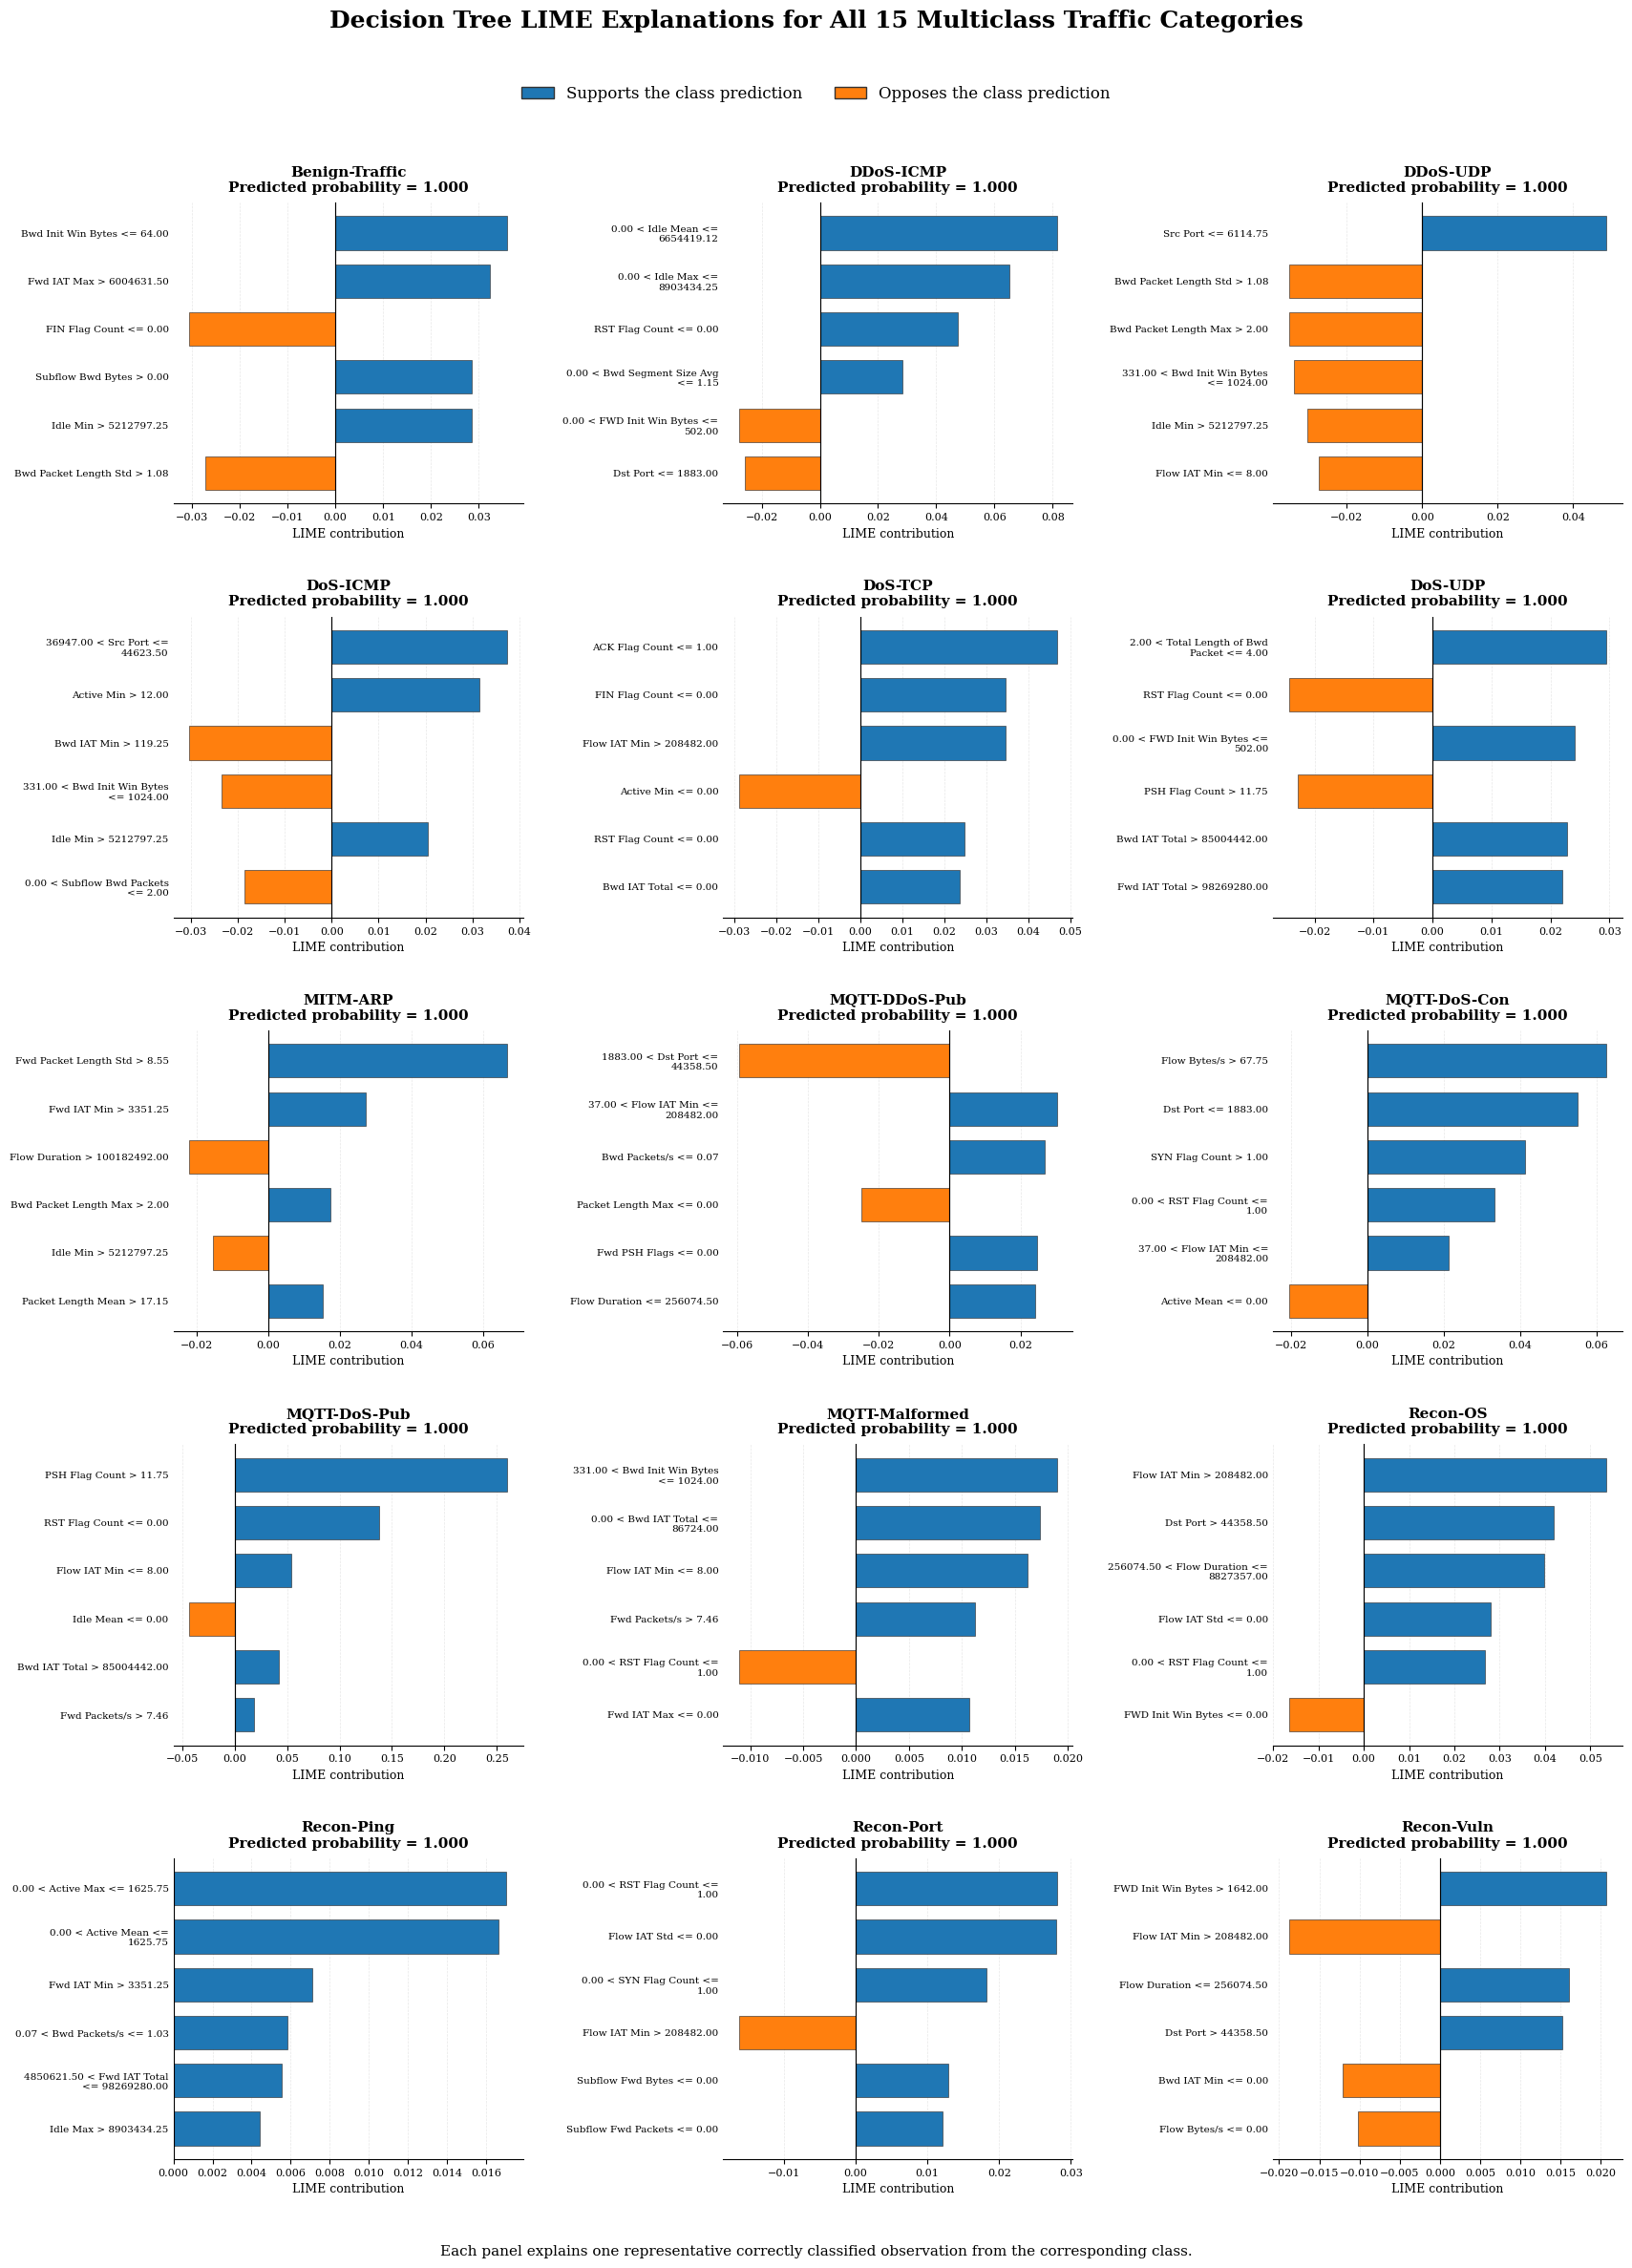


Standard multiclass LIME figure saved:
/content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/LIME_SHAP/Decision_Tree_Multiclass_LIME_All_15_Classes.png


In [ ]:
# ================================================================
# STANDARD LIME BAR PLOTS
# ALL 15 CLASSES IN ONE COMBINED FIGURE
# ================================================================

RANDOM_SEED = 42

BACKGROUND_PER_CLASS = 30
LIME_NUM_SAMPLES = 5000
TOP_FEATURES_PER_CLASS = 6

BLUE_COLOR = "#1F77B4"
ORANGE_COLOR = "#FF7F0E"

random_generator = np.random.default_rng(
    RANDOM_SEED
)


# ----------------------------------------------------------------
# 1. Create a class-balanced LIME background
# ----------------------------------------------------------------

background_indices = []

for class_id in class_ids:

    available_indices = np.flatnonzero(
        y_train_array == class_id
    )

    if len(available_indices) == 0:
        raise RuntimeError(
            f"No training observations were found for class {class_id}."
        )

    selected_count = min(
        BACKGROUND_PER_CLASS,
        len(available_indices)
    )

    selected_indices = random_generator.choice(
        available_indices,
        size=selected_count,
        replace=False
    )

    background_indices.extend(
        selected_indices.tolist()
    )


background_data = take_rows(
    X_train_full,
    np.asarray(
        background_indices,
        dtype=int
    )
)

print(
    "LIME background shape:",
    background_data.shape
)


# ----------------------------------------------------------------
# 2. Select one representative instance for each class
# ----------------------------------------------------------------

representative_indices = []
representative_probabilities = []

for class_id in class_ids:

    correct_indices = np.flatnonzero(
        (y_test_array == class_id)
        &
        (
            decision_tree_predictions
            == class_id
        )
    )

    if len(correct_indices) == 0:

        correct_indices = np.flatnonzero(
            y_test_array == class_id
        )

        print(
            "No correctly predicted observation for:",
            class_names[class_id]
        )

    if len(correct_indices) == 0:
        raise RuntimeError(
            f"No test observation was found for class {class_id}."
        )

    candidate_count = min(
        500,
        len(correct_indices)
    )

    candidate_indices = random_generator.choice(
        correct_indices,
        size=candidate_count,
        replace=False
    )

    candidate_data = take_rows(
        X_test_full,
        candidate_indices
    )

    candidate_probabilities = aligned_predict_proba(
        candidate_data
    )[:, class_id]

    median_probability = np.median(
        candidate_probabilities
    )

    selected_position = np.argmin(
        np.abs(
            candidate_probabilities
            - median_probability
        )
    )

    selected_index = int(
        candidate_indices[
            selected_position
        ]
    )

    representative_indices.append(
        selected_index
    )

    representative_probabilities.append(
        float(
            candidate_probabilities[
                selected_position
            ]
        )
    )


representative_indices = np.asarray(
    representative_indices,
    dtype=int
)

representative_data = take_rows(
    X_test_full,
    representative_indices
)


# ----------------------------------------------------------------
# 3. Create LIME explainer
# ----------------------------------------------------------------

lime_explainer = LimeTabularExplainer(
    training_data=background_data,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    discretizer="quartile",
    sample_around_instance=True,
    random_state=RANDOM_SEED
)


# ----------------------------------------------------------------
# 4. Generate one normal LIME plot for every class
# ----------------------------------------------------------------

figure, axes = plt.subplots(
    5,
    3,
    figsize=(18, 24),
    facecolor="white"
)

axes = axes.flatten()


for class_id in class_ids:

    axis = axes[class_id]

    lime_explanation = lime_explainer.explain_instance(
        data_row=representative_data[
            class_id
        ],
        predict_fn=aligned_predict_proba,
        labels=(int(class_id),),
        num_features=TOP_FEATURES_PER_CLASS,
        num_samples=LIME_NUM_SAMPLES
    )

    explanation_items = lime_explanation.as_list(
        label=int(class_id)
    )

    feature_conditions = [
        item[0]
        for item in explanation_items
    ]

    contributions = np.asarray(
        [
            item[1]
            for item in explanation_items
        ],
        dtype=float
    )

    order = np.argsort(
        np.abs(contributions)
    )

    feature_conditions = [
        feature_conditions[index]
        for index in order
    ]

    contributions = contributions[
        order
    ]

    wrapped_conditions = [
        "\n".join(
            textwrap.wrap(
                condition,
                width=28
            )
        )
        for condition in feature_conditions
    ]

    bar_colors = [
        BLUE_COLOR
        if contribution >= 0
        else ORANGE_COLOR
        for contribution in contributions
    ]

    y_positions = np.arange(
        len(contributions)
    )

    axis.barh(
        y_positions,
        contributions,
        color=bar_colors,
        edgecolor="#333333",
        linewidth=0.45,
        height=0.70
    )

    axis.axvline(
        0,
        color="black",
        linewidth=0.85
    )

    axis.set_yticks(
        y_positions
    )

    axis.set_yticklabels(
        wrapped_conditions,
        fontsize=7.5
    )

    axis.set_title(
        (
            f"{short_class_names[class_id]}\n"
            f"Predicted probability = "
            f"{representative_probabilities[class_id]:.3f}"
        ),
        fontsize=11,
        fontweight="bold",
        pad=8
    )

    axis.set_xlabel(
        "LIME contribution",
        fontsize=9
    )

    axis.tick_params(
        axis="x",
        labelsize=8
    )

    axis.tick_params(
        axis="y",
        length=0
    )

    axis.xaxis.grid(
        True,
        linestyle="--",
        linewidth=0.5,
        alpha=0.30
    )

    axis.set_axisbelow(True)

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)


legend_items = [
    Patch(
        facecolor=BLUE_COLOR,
        edgecolor="#333333",
        label="Supports the class prediction"
    ),
    Patch(
        facecolor=ORANGE_COLOR,
        edgecolor="#333333",
        label="Opposes the class prediction"
    )
]

figure.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2,
    frameon=False,
    fontsize=12
)

figure.suptitle(
    (
        "Decision Tree LIME Explanations "
        "for All 15 Multiclass Traffic Categories"
    ),
    fontsize=18,
    fontweight="bold",
    y=0.992
)

figure.text(
    0.5,
    0.012,
    (
        "Each panel explains one representative correctly "
        "classified observation from the corresponding class."
    ),
    ha="center",
    fontsize=11
)

figure.tight_layout(
    rect=[
        0.02,
        0.03,
        0.98,
        0.95
    ],
    h_pad=2.3,
    w_pad=1.5
)

figure.savefig(
    LIME_PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(figure)

gc.collect()

print("\nStandard multiclass LIME figure saved:")
print(LIME_PNG_PATH)

In [ ]:
# ================================================================
# REQUIRED VARIABLES FOR THE MULTICLASS LIME CELL
# ================================================================

import os
import gc
import joblib
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from lime.lime_tabular import LimeTabularExplainer


MODEL_PATH = (
    "/content/drive/MyDrive/IoMT_Thesis_2024/"
    "ML_Multiclass_Results/Models/"
    "Decision_Tree_Full.joblib"
)

LIME_PNG_PATH = (
    "/content/drive/MyDrive/IoMT_Thesis_2024/"
    "ML_Multiclass_Results/Plots/LIME_SHAP/"
    "Decision_Tree_Multiclass_LIME_All_15_Classes.png"
)

os.makedirs(
    os.path.dirname(LIME_PNG_PATH),
    exist_ok=True
)


# Load the saved Decision Tree
decision_tree_model = joblib.load(MODEL_PATH)


# Feature names
if isinstance(X_train_full, pd.DataFrame):
    feature_names = X_train_full.columns.astype(str).tolist()
else:
    feature_names = list(FEATURE_NAMES)


# Class information
class_names = [str(name) for name in le.classes_]
number_of_classes = len(class_names)
class_ids = np.arange(number_of_classes)

if number_of_classes != 15:
    raise ValueError(
        f"Expected 15 classes, but found {number_of_classes}."
    )


# Label arrays
y_train_array = np.asarray(y_train_full).reshape(-1)
y_test_array = np.asarray(y_test_full).reshape(-1)


# Decision Tree predictions
decision_tree_predictions = np.asarray(
    decision_tree_model.predict(X_test_full)
).reshape(-1)


# Short class names for the figure
short_class_name_map = {
    "Benign": "Benign",
    "DDoS ICMP Flood": "DDoS-ICMP",
    "DDoS UDP Flood": "DDoS-UDP",
    "DoS ICMP Flood": "DoS-ICMP",
    "DoS TCP Flood": "DoS-TCP",
    "DoS UDP Flood": "DoS-UDP",
    "MITM ARP Spoofing": "MITM-ARP",
    "MQTT DDoS Publish Flood": "MQTT-DDoS-Pub",
    "MQTT DoS Connect Flood": "MQTT-DoS-Con",
    "MQTT DoS Publish Flood": "MQTT-DoS-Pub",
    "MQTT Malformed": "MQTT-Malformed",
    "Recon OS Scan": "Recon-OS",
    "Recon Ping Sweep": "Recon-Ping",
    "Recon Port Scan": "Recon-Port",
    "Recon Vulnerability Scan": "Recon-Vuln"
}

short_class_names = [
    short_class_name_map.get(
        class_name,
        class_name.replace(" ", "-")
    )
    for class_name in class_names
]


# Extract selected rows safely
def take_rows(dataset, indices):

    if isinstance(dataset, pd.DataFrame):
        return dataset.iloc[indices].to_numpy(
            dtype=np.float32,
            copy=True
        )

    return np.asarray(dataset)[indices].astype(
        np.float32,
        copy=True
    )


# Preserve feature names during model prediction
def create_model_input(data_array):

    if hasattr(decision_tree_model, "feature_names_in_"):
        return pd.DataFrame(
            data_array,
            columns=feature_names
        )

    return np.asarray(
        data_array,
        dtype=np.float32
    )


model_classes = np.asarray(
    decision_tree_model.classes_,
    dtype=int
)


# Return probabilities in the complete 15-class order
def aligned_predict_proba(data_array):

    raw_probabilities = np.asarray(
        decision_tree_model.predict_proba(
            create_model_input(data_array)
        ),
        dtype=np.float64
    )

    aligned_probabilities = np.zeros(
        (len(data_array), number_of_classes),
        dtype=np.float64
    )

    aligned_probabilities[:, model_classes] = raw_probabilities

    return aligned_probabilities


print("Required LIME variables prepared successfully.")
print("Number of classes:", number_of_classes)
print("Class IDs:", class_ids)

Required LIME variables prepared successfully.
Number of classes: 15
Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


LIME background shape: (450, 79)


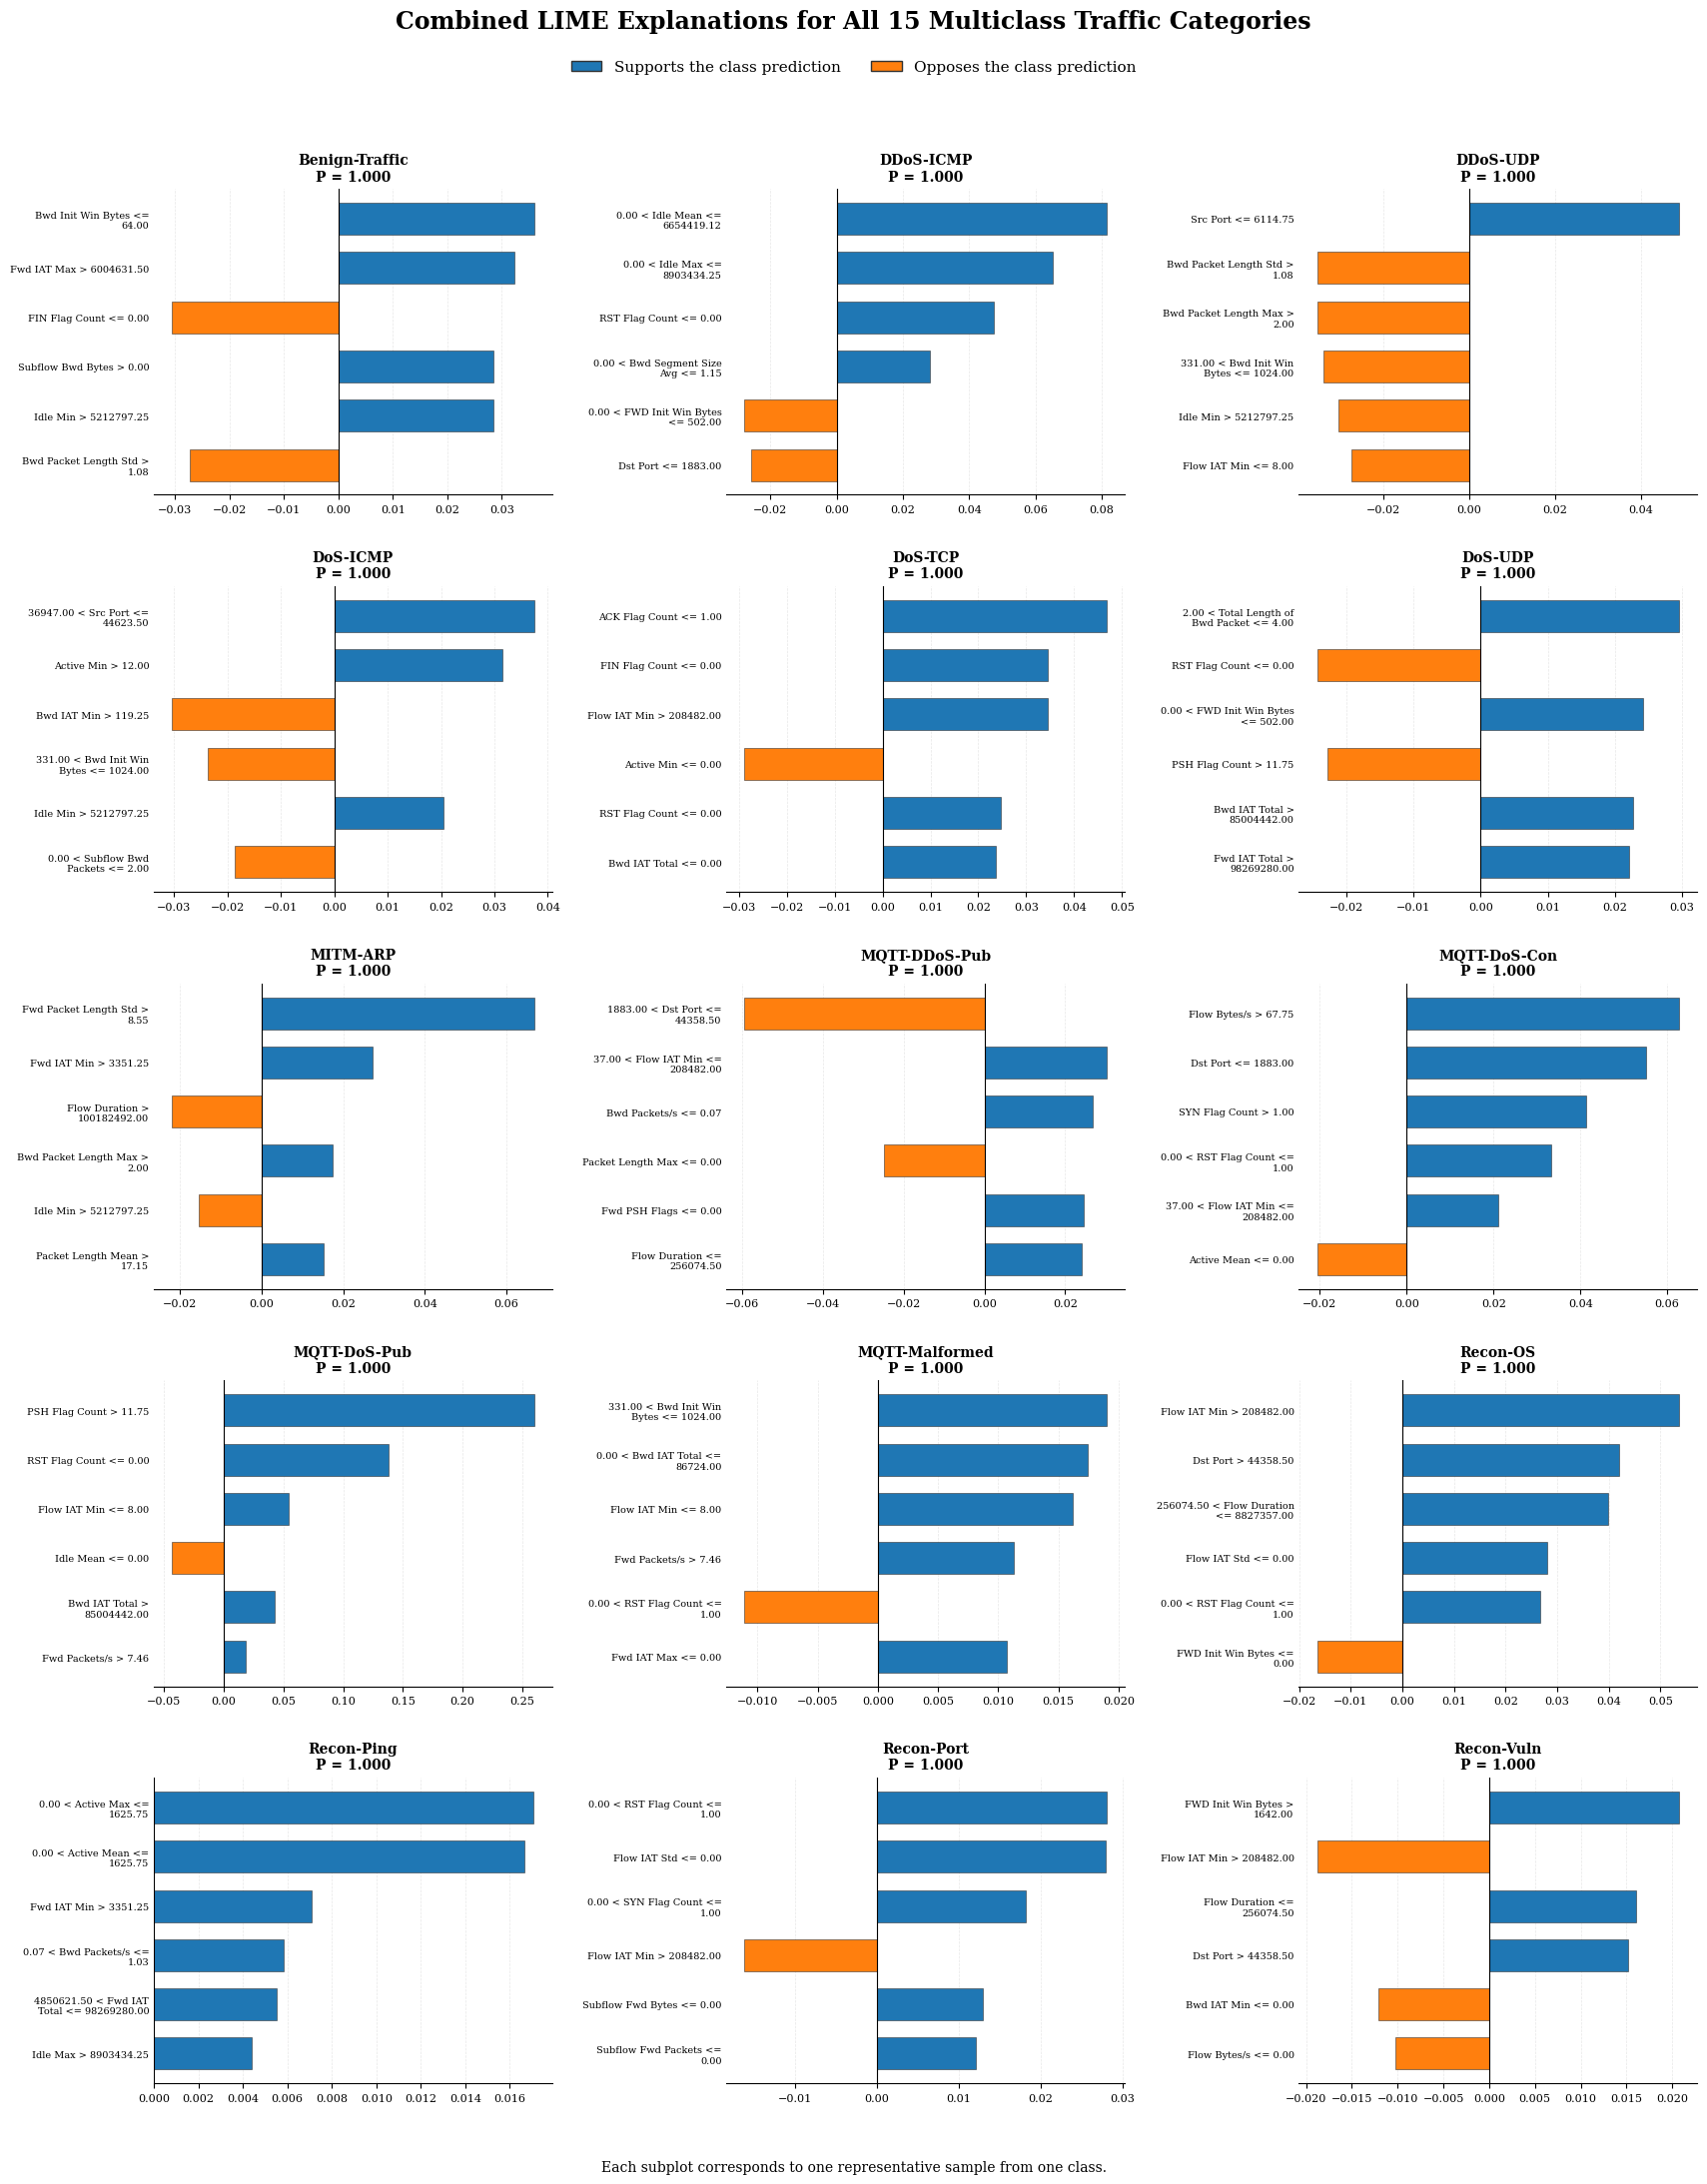


Combined LIME figure saved successfully:
/content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/LIME_SHAP/Decision_Tree_Multiclass_LIME_All_15_Classes.png


In [ ]:
# ================================================================
# COMBINED LIME FIGURE
# ALL 15 CLASSES IN ONE SINGLE PNG
# ================================================================

RANDOM_SEED = 42

BACKGROUND_PER_CLASS = 30
LIME_NUM_SAMPLES = 5000
TOP_FEATURES_PER_CLASS = 6

BLUE_COLOR = "#1F77B4"
ORANGE_COLOR = "#FF7F0E"

random_generator = np.random.default_rng(RANDOM_SEED)


# ----------------------------------------------------------------
# 1. Create class-balanced background
# ----------------------------------------------------------------

background_indices = []

for class_id in class_ids:

    available_indices = np.flatnonzero(y_train_array == class_id)

    if len(available_indices) == 0:
        raise RuntimeError(
            f"No training observations were found for class {class_id}."
        )

    selected_count = min(BACKGROUND_PER_CLASS, len(available_indices))

    selected_indices = random_generator.choice(
        available_indices,
        size=selected_count,
        replace=False
    )

    background_indices.extend(selected_indices.tolist())

background_data = take_rows(
    X_train_full,
    np.asarray(background_indices, dtype=int)
)

print("LIME background shape:", background_data.shape)


# ----------------------------------------------------------------
# 2. Select one representative sample from each class
# ----------------------------------------------------------------

representative_indices = []
representative_probabilities = []

for class_id in class_ids:

    correct_indices = np.flatnonzero(
        (y_test_array == class_id) &
        (decision_tree_predictions == class_id)
    )

    if len(correct_indices) == 0:
        correct_indices = np.flatnonzero(y_test_array == class_id)
        print("No correctly predicted observation for:", class_names[class_id])

    if len(correct_indices) == 0:
        raise RuntimeError(
            f"No test observation was found for class {class_id}."
        )

    candidate_count = min(500, len(correct_indices))

    candidate_indices = random_generator.choice(
        correct_indices,
        size=candidate_count,
        replace=False
    )

    candidate_data = take_rows(X_test_full, candidate_indices)

    candidate_probabilities = aligned_predict_proba(candidate_data)[:, class_id]

    median_probability = np.median(candidate_probabilities)

    selected_position = np.argmin(
        np.abs(candidate_probabilities - median_probability)
    )

    selected_index = int(candidate_indices[selected_position])

    representative_indices.append(selected_index)
    representative_probabilities.append(
        float(candidate_probabilities[selected_position])
    )

representative_indices = np.asarray(representative_indices, dtype=int)
representative_data = take_rows(X_test_full, representative_indices)


# ----------------------------------------------------------------
# 3. Create LIME explainer
# ----------------------------------------------------------------

lime_explainer = LimeTabularExplainer(
    training_data=background_data,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    discretizer="quartile",
    sample_around_instance=True,
    random_state=RANDOM_SEED
)


# ----------------------------------------------------------------
# 4. Create ONE combined figure with 15 subplots
# ----------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(18, 22),
    facecolor="white"
)

axes = axes.flatten()

for class_id in class_ids:

    ax = axes[class_id]

    lime_explanation = lime_explainer.explain_instance(
        data_row=representative_data[class_id],
        predict_fn=aligned_predict_proba,
        labels=(int(class_id),),
        num_features=TOP_FEATURES_PER_CLASS,
        num_samples=LIME_NUM_SAMPLES
    )

    explanation_items = lime_explanation.as_list(label=int(class_id))

    feature_conditions = [item[0] for item in explanation_items]
    contributions = np.asarray([item[1] for item in explanation_items], dtype=float)

    order = np.argsort(np.abs(contributions))
    feature_conditions = [feature_conditions[i] for i in order]
    contributions = contributions[order]

    wrapped_conditions = [
        "\n".join(textwrap.wrap(str(cond), width=25))
        for cond in feature_conditions
    ]

    bar_colors = [
        BLUE_COLOR if value >= 0 else ORANGE_COLOR
        for value in contributions
    ]

    y_positions = np.arange(len(contributions))

    ax.barh(
        y_positions,
        contributions,
        color=bar_colors,
        edgecolor="#333333",
        linewidth=0.4,
        height=0.65
    )

    ax.axvline(0, color="black", linewidth=0.8)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(wrapped_conditions, fontsize=7)

    ax.set_title(
        f"{short_class_names[class_id]}\nP = {representative_probabilities[class_id]:.3f}",
        fontsize=10,
        fontweight="bold",
        pad=6
    )

    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", length=0)

    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.30)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)


# ----------------------------------------------------------------
# 5. Global title and legend
# ----------------------------------------------------------------

legend_items = [
    Patch(
        facecolor=BLUE_COLOR,
        edgecolor="#333333",
        label="Supports the class prediction"
    ),
    Patch(
        facecolor=ORANGE_COLOR,
        edgecolor="#333333",
        label="Opposes the class prediction"
    )
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=2,
    frameon=False,
    fontsize=11
)

fig.suptitle(
    "Combined LIME Explanations for All 15 Multiclass Traffic Categories",
    fontsize=17,
    fontweight="bold",
    y=0.992
)

fig.text(
    0.5,
    0.008,
    "Each subplot corresponds to one representative sample from one class.",
    ha="center",
    fontsize=10
)

fig.tight_layout(
    rect=[0.02, 0.03, 0.98, 0.955],
    h_pad=2.0,
    w_pad=1.2
)

fig.savefig(
    LIME_PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

gc.collect()

print("\nCombined LIME figure saved successfully:")
print(LIME_PNG_PATH)

LIME background shape: (450, 79)
Representative samples used per class: [5 5 5 5 5 5 5 5 5 5 5 5 4 5 5]


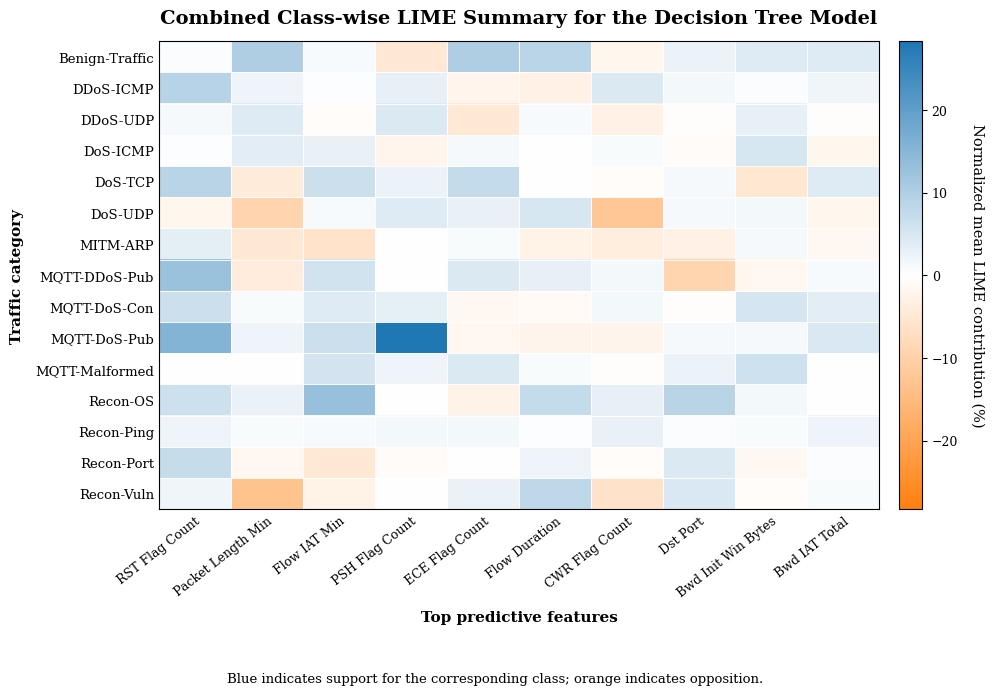


Combined LIME figure saved successfully:
/content/drive/MyDrive/IoMT_Thesis_2024/ML_Multiclass_Results/Plots/LIME_SHAP/Decision_Tree_Combined_LIME_All_15_Classes.png


In [ ]:
# ================================================================
# SINGLE COMBINED MULTICLASS LIME SUMMARY
# ALL 15 CLASSES IN ONE COMPACT PAPER-READY FIGURE
# ================================================================

!pip install -q lime

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from lime.lime_tabular import LimeTabularExplainer


# ----------------------------------------------------------------
# 1. Configuration
# ----------------------------------------------------------------

RANDOM_SEED = 42

BACKGROUND_PER_CLASS = 30
REPRESENTATIVE_SAMPLES_PER_CLASS = 5
LIME_NUM_SAMPLES = 3000
TOP_FEATURES_TO_DISPLAY = 10


# ----------------------------------------------------------------
# 2. Paths
# ----------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/IoMT_Thesis_2024"

MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "ML_Multiclass_Results",
    "Models",
    "Decision_Tree_Full.joblib"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "ML_Multiclass_Results",
    "Plots",
    "LIME_SHAP"
)

PNG_PATH = os.path.join(
    OUTPUT_DIR,
    "Decision_Tree_Combined_LIME_All_15_Classes.png"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ----------------------------------------------------------------
# 3. Check required notebook variables
# ----------------------------------------------------------------

required_variables = [
    "X_train_full",
    "y_train_full",
    "X_test_full",
    "y_test_full",
    "le"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the multiclass data-preparation cells first. "
        f"Missing variables: {missing_variables}"
    )

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Saved Decision Tree model was not found:\n{MODEL_PATH}"
    )


# ----------------------------------------------------------------
# 4. Load the saved Decision Tree model
# ----------------------------------------------------------------

decision_tree_model = joblib.load(
    MODEL_PATH
)

if not hasattr(decision_tree_model, "predict_proba"):
    raise TypeError(
        "The loaded model does not support predict_proba()."
    )


# ----------------------------------------------------------------
# 5. Feature and class information
# ----------------------------------------------------------------

if isinstance(X_train_full, pd.DataFrame):

    feature_names = (
        X_train_full.columns
        .astype(str)
        .tolist()
    )

elif "FEATURE_NAMES" in globals():

    feature_names = list(
        FEATURE_NAMES
    )

elif hasattr(decision_tree_model, "feature_names_in_"):

    feature_names = (
        decision_tree_model.feature_names_in_
        .astype(str)
        .tolist()
    )

else:

    feature_names = [
        f"Feature_{index}"
        for index in range(
            np.asarray(X_train_full).shape[1]
        )
    ]


class_names = [
    str(class_name)
    for class_name in le.classes_
]

number_of_classes = len(class_names)
number_of_features = len(feature_names)

if number_of_classes != 15:
    raise ValueError(
        f"Expected 15 classes, but found {number_of_classes}."
    )

class_ids = np.arange(
    number_of_classes
)


short_class_name_map = {
    "Benign": "Benign",
    "DDoS ICMP Flood": "DDoS-ICMP",
    "DDoS UDP Flood": "DDoS-UDP",
    "DoS ICMP Flood": "DoS-ICMP",
    "DoS TCP Flood": "DoS-TCP",
    "DoS UDP Flood": "DoS-UDP",
    "MITM ARP Spoofing": "MITM-ARP",
    "MQTT DDoS Publish Flood": "MQTT-DDoS-Pub",
    "MQTT DoS Connect Flood": "MQTT-DoS-Con",
    "MQTT DoS Publish Flood": "MQTT-DoS-Pub",
    "MQTT Malformed": "MQTT-Malformed",
    "Recon OS Scan": "Recon-OS",
    "Recon Ping Sweep": "Recon-Ping",
    "Recon Port Scan": "Recon-Port",
    "Recon Vulnerability Scan": "Recon-Vuln"
}

short_class_names = [
    short_class_name_map.get(
        class_name,
        class_name.replace(" ", "-")
    )
    for class_name in class_names
]


# ----------------------------------------------------------------
# 6. Helper functions
# ----------------------------------------------------------------

def take_rows(dataset, row_indices):

    if isinstance(dataset, pd.DataFrame):

        return dataset.iloc[
            row_indices
        ].to_numpy(
            dtype=np.float32,
            copy=True
        )

    return np.asarray(dataset)[
        row_indices
    ].astype(
        np.float32,
        copy=True
    )


def prepare_model_input(data_array):

    if hasattr(
        decision_tree_model,
        "feature_names_in_"
    ):

        return pd.DataFrame(
            data_array,
            columns=feature_names
        )

    return np.asarray(
        data_array,
        dtype=np.float32
    )


model_classes = np.asarray(
    decision_tree_model.classes_,
    dtype=int
)


def aligned_predict_proba(data_array):

    raw_probabilities = np.asarray(
        decision_tree_model.predict_proba(
            prepare_model_input(
                data_array
            )
        ),
        dtype=np.float64
    )

    aligned_probabilities = np.zeros(
        (
            len(data_array),
            number_of_classes
        ),
        dtype=np.float64
    )

    aligned_probabilities[
        :,
        model_classes
    ] = raw_probabilities

    return aligned_probabilities


# ----------------------------------------------------------------
# 7. Prepare labels and predictions
# ----------------------------------------------------------------

y_train_array = np.asarray(
    y_train_full
).reshape(-1)

y_test_array = np.asarray(
    y_test_full
).reshape(-1)

decision_tree_predictions = np.asarray(
    decision_tree_model.predict(
        X_test_full
    )
).reshape(-1)


# ----------------------------------------------------------------
# 8. Create a class-balanced LIME background
# ----------------------------------------------------------------

random_generator = np.random.default_rng(
    RANDOM_SEED
)

background_indices = []

for class_id in class_ids:

    class_indices = np.flatnonzero(
        y_train_array == class_id
    )

    if len(class_indices) == 0:
        raise RuntimeError(
            f"No training samples were found for class {class_id}."
        )

    selected_count = min(
        BACKGROUND_PER_CLASS,
        len(class_indices)
    )

    selected_indices = random_generator.choice(
        class_indices,
        size=selected_count,
        replace=False
    )

    background_indices.extend(
        selected_indices.tolist()
    )


background_data = take_rows(
    X_train_full,
    np.asarray(
        background_indices,
        dtype=int
    )
)

print(
    "LIME background shape:",
    background_data.shape
)


# ----------------------------------------------------------------
# 9. Create the LIME explainer
# ----------------------------------------------------------------

lime_explainer = LimeTabularExplainer(
    training_data=background_data,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    discretizer="quartile",
    sample_around_instance=True,
    feature_selection="auto",
    random_state=RANDOM_SEED
)


# ----------------------------------------------------------------
# 10. Calculate average signed LIME contribution for each class
# ----------------------------------------------------------------

class_feature_contributions = np.zeros(
    (
        number_of_classes,
        number_of_features
    ),
    dtype=np.float64
)

samples_used_per_class = np.zeros(
    number_of_classes,
    dtype=int
)


for class_id in class_ids:

    correct_indices = np.flatnonzero(
        (y_test_array == class_id)
        &
        (decision_tree_predictions == class_id)
    )

    if len(correct_indices) == 0:

        correct_indices = np.flatnonzero(
            y_test_array == class_id
        )

        print(
            "No correctly classified sample was found for:",
            class_names[class_id]
        )

    if len(correct_indices) == 0:
        raise RuntimeError(
            f"No test sample was found for class {class_id}."
        )

    candidate_count = min(
        500,
        len(correct_indices)
    )

    candidate_indices = random_generator.choice(
        correct_indices,
        size=candidate_count,
        replace=False
    )

    candidate_data = take_rows(
        X_test_full,
        candidate_indices
    )

    candidate_probabilities = aligned_predict_proba(
        candidate_data
    )[:, class_id]

    median_probability = np.median(
        candidate_probabilities
    )

    ordered_positions = np.argsort(
        np.abs(
            candidate_probabilities
            - median_probability
        )
    )

    selected_count = min(
        REPRESENTATIVE_SAMPLES_PER_CLASS,
        len(ordered_positions)
    )

    selected_indices = candidate_indices[
        ordered_positions[
            :selected_count
        ]
    ]

    selected_data = take_rows(
        X_test_full,
        selected_indices
    )

    for selected_instance in selected_data:

        explanation = lime_explainer.explain_instance(
            data_row=selected_instance,
            predict_fn=aligned_predict_proba,
            labels=(int(class_id),),
            num_features=number_of_features,
            num_samples=LIME_NUM_SAMPLES
        )

        explanation_map = explanation.as_map().get(
            int(class_id),
            []
        )

        for feature_index, contribution in explanation_map:

            class_feature_contributions[
                class_id,
                int(feature_index)
            ] += float(contribution)

        samples_used_per_class[
            class_id
        ] += 1


class_feature_contributions = np.divide(
    class_feature_contributions,
    np.maximum(
        samples_used_per_class[:, None],
        1
    )
)

print(
    "Representative samples used per class:",
    samples_used_per_class
)


# ----------------------------------------------------------------
# 11. Normalize each class while preserving contribution direction
# ----------------------------------------------------------------

absolute_row_totals = np.sum(
    np.abs(
        class_feature_contributions
    ),
    axis=1,
    keepdims=True
)

normalized_contributions = np.divide(
    class_feature_contributions,
    absolute_row_totals,
    out=np.zeros_like(
        class_feature_contributions
    ),
    where=absolute_row_totals > 0
) * 100.0


# ----------------------------------------------------------------
# 12. Select the common most important features
# ----------------------------------------------------------------

global_feature_importance = np.mean(
    np.abs(
        normalized_contributions
    ),
    axis=0
)

top_feature_indices = np.argsort(
    global_feature_importance
)[
    -TOP_FEATURES_TO_DISPLAY:
][::-1]

plot_data = normalized_contributions[
    :,
    top_feature_indices
]

top_feature_names = [
    feature_names[feature_index]
    for feature_index in top_feature_indices
]


# ----------------------------------------------------------------
# 13. Create one single combined figure
# ----------------------------------------------------------------

orange_blue_cmap = LinearSegmentedColormap.from_list(
    "LIME_Orange_Blue",
    [
        "#FF7F0E",
        "#FFFFFF",
        "#1F77B4"
    ]
)

maximum_absolute_value = max(
    float(
        np.max(
            np.abs(plot_data)
        )
    ),
    1e-8
)

color_normalization = TwoSlopeNorm(
    vmin=-maximum_absolute_value,
    vcenter=0,
    vmax=maximum_absolute_value
)


fig, ax = plt.subplots(
    figsize=(10.5, 7.2),
    facecolor="white"
)

image = ax.imshow(
    plot_data,
    cmap=orange_blue_cmap,
    norm=color_normalization,
    aspect="auto",
    interpolation="nearest"
)


ax.set_xticks(
    np.arange(
        len(top_feature_names)
    )
)

ax.set_xticklabels(
    top_feature_names,
    rotation=38,
    ha="right",
    rotation_mode="anchor",
    fontsize=9
)

ax.set_yticks(
    np.arange(
        number_of_classes
    )
)

ax.set_yticklabels(
    short_class_names,
    fontsize=9.5
)


ax.set_xlabel(
    "Top predictive features",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)

ax.set_ylabel(
    "Traffic category",
    fontsize=11,
    fontweight="bold",
    labelpad=8
)

ax.set_title(
    "Combined Class-wise LIME Summary for the Decision Tree Model",
    fontsize=14,
    fontweight="bold",
    pad=13
)


# White grid lines between cells
ax.set_xticks(
    np.arange(
        -0.5,
        len(top_feature_names),
        1
    ),
    minor=True
)

ax.set_yticks(
    np.arange(
        -0.5,
        number_of_classes,
        1
    ),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=0.65
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

ax.tick_params(
    which="major",
    length=0
)


colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.025
)

colorbar.set_label(
    "Normalized mean LIME contribution (%)",
    rotation=270,
    labelpad=19,
    fontsize=10.5
)

colorbar.ax.tick_params(
    labelsize=9
)


fig.text(
    0.5,
    0.01,
    (
        "Blue indicates support for the corresponding class; "
        "orange indicates opposition."
    ),
    ha="center",
    fontsize=9.5
)

fig.subplots_adjust(
    left=0.18,
    right=0.91,
    bottom=0.25,
    top=0.90
)


# ----------------------------------------------------------------
# 14. Save only one PNG
# ----------------------------------------------------------------

fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

print("\nCombined LIME figure saved successfully:")
print(PNG_PATH)